# Flexibility needs and contribution 

**sources:**

Flex needs:

https://www.artelys.com/app/docs/supergrid/kpis/scalar_kpis/flexibility_needs.html

Contribution to flex needs: 

https://www.artelys.com/app/docs/supergrid/kpis/scalar_kpis/contribution_to_flexibility_needs.html

- can be calculated daily, weekly and annually
- all these metrics relate to one node of the network


### imports and definitions


In [1]:
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

from utils import flex_techs, flex_techs_supply, flex_techs_demand, carriers_in_german, tech_colors

In [2]:
all_flex_techs = list(flex_techs_supply.keys()) + list(flex_techs_demand.keys())

year_colors = {
    2020: "dimgrey",
    2025: "darkorange",
    2030: "seagreen",
    2035: "cadetblue",
    2040: "hotpink",
    2045: "darkviolet"
}
load_carriers=["electricity", "agriculture electricity", "industry electricity"]
vre_gens=["onwind", "offwind-ac", "offwind-dc", "solar", "solar-hsat","solar rooftop", "ror"]

plt.rcParams["font.family"] = "Arial"

### functions

In [3]:
def summarize_small_values(df, column_name, threshold_percentage=3):
    total_sum = df[column_name].sum()
    threshold = (threshold_percentage / 100) * total_sum
    small_values = df[df[column_name] < threshold]
    other_sum = small_values[column_name].sum()
    df = df[df[column_name] >= threshold]
    other_row = pd.DataFrame({column_name: [other_sum]}, index=["Other"])
    df = pd.concat([df, other_row])
    return df

In [77]:
def supply_demand(n, region = "DE", interconnectors=True, merge_dist_grid=True, drop_dist_grid=True, buses=None, add_diff_as_import=False):

    """
    Aggregates electricity supply and demand statistics from a PyPSA network for a given region.

    Parameters
    ----------
    n : pypsa.Network
        The PyPSA network object containing snapshots, buses, and generators.
    region : str, default "DE"
        Two-letter country code prefix for buses to include.
    interconnectors : bool, default True
        Whether to include interconnectors (AC/DC) in the supply/demand.
    merge_dist_grid : bool, default True
        If True, merges low-voltage and AC buses so that the distribution grid only represents losses.
    drop_dist_grid : bool, default True
        If True, removes the electricity distribution grid from supply and demand.
    buses : list[str] or None
        Specific bus names to consider; defaults to all buses in the given region with low-voltage or AC carrier.
    add_diff_as_import : bool, default False
        If True, any difference between total supply and demand is added as "import" (negative difference) or "export" (positive difference).

    Returns
    -------
    electricity_supply : pd.DataFrame
        Supply per carrier aggregated over the selected buses.
    electricity_demand : pd.DataFrame
        Demand per carrier aggregated over the selected buses.

    Notes
    -----
    - Uses n.statistics.supply and n.statistics.withdrawal to compute per-bus and per-carrier values.
    - Multiplies by n.snapshot_weightings.generators to scale per snapshot.
    - Can remove AC/DC interconnectors or the distribution grid according to flags.
    - Optionally computes residual import/export if add_diff_as_import=True.
    - Prints total system supply and demand in TWh (sum / 1e6).
    """

    bus_carrier = ["low voltage", "AC"]

    kwargs = {
        "groupby": n.statistics.groupers.get_name_bus_and_carrier,
        "nice_names": False,
    }

    electricity_supply = (
        n.statistics.supply(
            bus_carrier=bus_carrier, 
            aggregate_time=False, 
            **kwargs
            )
    ).multiply(n.snapshot_weightings.generators) 

    if buses is None:
        buses = n.buses[(n.buses.index.str[:2] == region) & (n.buses.carrier.isin(bus_carrier))].index
    
    electricity_supply = electricity_supply[electricity_supply.index.get_level_values("bus").isin(buses)].groupby("carrier").sum()

    electricity_demand = (
        n.statistics.withdrawal(
            bus_carrier=bus_carrier, 
            aggregate_time=False, 
            **kwargs
            )
    ).multiply(n.snapshot_weightings.generators) 
    electricity_demand = electricity_demand[electricity_demand.index.get_level_values("bus").isin(buses)].groupby("carrier").sum()

    if not interconnectors:
        electricity_supply = electricity_supply.drop(["AC", "DC"], errors="ignore")
        electricity_demand = electricity_demand.drop(["AC", "DC"], errors="ignore")

    if merge_dist_grid:
        # merge AC & low voltage such that electricity distribution grid does only function as a demand representing the grid losses
        electricity_demand.loc["electricity distribution grid losses" , :] = abs(electricity_supply.loc["electricity distribution grid"] - electricity_demand.loc["electricity distribution grid"])
        electricity_demand = electricity_demand.drop("electricity distribution grid", axis=0)
        electricity_supply = electricity_supply.drop("electricity distribution grid", axis=0)
        
    if drop_dist_grid:
        electricity_supply = electricity_supply.drop("electricity distribution grid", errors="ignore")
        electricity_demand = electricity_demand.drop("electricity distribution grid", errors="ignore")

    if add_diff_as_import:
        diff = electricity_supply.sum() - electricity_demand.sum()
        electricity_supply.loc["import"  , : ] = diff.clip(upper=0).abs()
        electricity_demand.loc["export"  , : ] = diff.clip(lower=0)

    # # only keep rows with minimum of 1 MW
    # electricity_supply = electricity_supply[electricity_supply.sum(axis=1) > 1]
    # electricity_demand = electricity_demand[electricity_demand.sum(axis=1) > 1]
    
    # print(electricity_supply.sum().sum() / 1e6)
    # print(electricity_demand.sum().sum() / 1e6)

    return electricity_supply, electricity_demand


## Data loading

In [5]:
# networks_old = {}
# for year in np.arange(2020,2050,5):
#     fn = f"/home/julian-geis/Documents/04_Ariadne/run_results/20241108-limit-ft-meoh/KN2045_Bal_v4/postnetworks/base_s_49_lvopt__none_{year}.nc"
#     networks_old[year] = pypsa.Network(fn)

run = "20250214-reworkimportban" #"20241203-force-onwind-south"
scenario =  "KN2045_Elec_v4" # "KN2045_H2_v4" # "CurrentPolicies" # "KN2045_Bal_v4"
weather_year = 2010 # 1996 # 2010

networks = {}

for year in np.arange(2020,2050,5):
    fn = f"/home/julian-geis/Documents/04_Ariadne/run_results/{run}/{scenario}/postnetworks/base_s_49_lvopt__none_{year}.nc"
    networks[year] = pypsa.Network(fn)

# # from z1
# for year in np.arange(2020, 2050, 5):
#     fn = f"/home/julian-geis/cluster/z1/pypsa-de/results/20250604_weather_sensitivities/Mix{weather_year}/networks/base_s_49__none_{year}.nc"
#     networks[year] = pypsa.Network(fn)


PLOT_DIR = "/home/julian-geis/Documents/06_PhD/02Flexibility/plots/" + run

INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['FR4 0 waste CHP-2025', 'IT3 0 waste CHP-2025',
       'FR4 0 waste CHP CC-2025', 'IT3 0 waste CHP CC-2025',
       'FR4 0 urban central gas CHP-1995', 'IT3 0 urban central oil CHP-1995',
       'IT3 0 urban central gas CHP-2000', 'IT3 0 urban central gas CHP-2005',
       'IT3 0 urban central gas CHP-2010'],
      dtype='object', name='name')
INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['FR4 0 waste CHP-2030', 'IT3 0 waste CHP-2030',
       'FR4 0 waste CHP CC-2030', 'IT3 0 waste CHP CC-2030',
       'FR4 0 urban central gas CHP-1995', 'IT3 0 urban central oil CHP-1995',
       'IT3 0 urban central gas CHP-2000', 'IT3 0 urban central gas CHP-2005',
       'IT3 0 urban central gas CHP-2010'],
      dtype='object', name='name')
INFO:pypsa.network

## Supply and demand

In [6]:
# Electricity supply
# electricity generation DE 2020: 488 TWh
# if aggregate_time=False the results are in MW (you need to multiply with snapshot.weightings)

region = "DE"
n = networks[2045]

kwargs = {
    "groupby": n.statistics.groupers.get_name_bus_and_carrier,
    "nice_names": False,
}

electricity_supply_de = (
    n.statistics.supply(bus_carrier=["low voltage", "AC"], **kwargs)
    .filter(like=region)
    .groupby(["carrier"])
    .sum()
    .drop(
        ["AC", "DC", "electricity distribution grid"],
        errors="ignore",
    )
)

print(round(electricity_supply_de.sum() / 1e6, 2))

1292.47


In [7]:
# real supply without Storage
electricity_supply_de[
            ~electricity_supply_de.index.str.contains(
                "PHS" "|battery discharger" "|home battery discharger" "|V2G"
            )
        ].sum() / 1e6

1180.75419888531

In [8]:
# suppy from VRE
electricity_supply_de[vre_gens].sum() / 1e6

1140.1312533893501

In [9]:
# supply from storage
storage_gens = ['PHS', 'battery discharger', 'home battery discharger']
electricity_supply_de[storage_gens].sum() / 1e6

111.71986453644

In [10]:
# non-VRE supply
non_vre_gens = electricity_supply_de[~electricity_supply_de.index.isin(vre_gens + storage_gens)].index
electricity_supply_de[non_vre_gens].sum() / 1e6

40.622945495959996

## Flexibility needs - supply and demand (aggregated as one node)

### Daily

In [172]:
# simple testing
n = networks[2030]
electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)

non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index
vre_gen = electricity_supply.loc[vre_gens].sum()
load = electricity_demand.loc[load_carriers].sum()

residual_load = load - vre_gen

# Compute daily average of residual load
daily_average_residual = residual_load.resample('D').mean()

# Expand daily averages to hourly resolution for comparison
daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

# Compute the difference between residual load and daily average (only the positive part)
hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

# Calculate daily flexibility needs 
daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

# Calculate total annual flexibility needs
total_annual_flexibility = hourly_flexibility_needs.sum()

print(f"Total annual flexibility needs (daily): {round(total_annual_flexibility / 1e6, 2)} TWh")

Total annual flexibility needs (daily): 82.52 TWh


In [173]:
residual_dev = residual_load - daily_average_hourly


In [174]:
load_dev = load - load.resample('D').mean().reindex(load.index, method='ffill')
vre_dev = electricity_supply.loc[vre_gens] - electricity_supply.loc[vre_gens].T.resample('D').mean().reindex(residual_load.index, method='ffill')

In [175]:
# example for load
load_contrib = (residual_dev > 0) * load_dev  # only counts when residual dev is positive

In [176]:
vre_contrib = {}
for g in vre_gens:
    g_dev = electricity_supply.loc[g] - electricity_supply.loc[g].resample('D').mean().reindex(residual_load.index, method='ffill')
    vre_contrib[g] = (residual_dev > 0) * g_dev


In [186]:
vre_contrib

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [177]:
total_contrib = load_contrib.copy()
for g in vre_gens:
    total_contrib += vre_contrib[g]


In [178]:
load_contrib

snapshot
2019-01-01 00:00:00   -7171.506904
2019-01-01 03:00:00      -0.000000
2019-01-01 06:00:00      -0.000000
2019-01-01 09:00:00       0.000000
2019-01-01 12:00:00       0.000000
                          ...     
2019-12-31 09:00:00       0.000000
2019-12-31 12:00:00       0.000000
2019-12-31 15:00:00    7939.237425
2019-12-31 18:00:00    1174.845195
2019-12-31 21:00:00   -3031.085145
Length: 2920, dtype: float64

In [179]:
total_contrib

snapshot
2019-01-01 00:00:00   -16181.027085
2019-01-01 03:00:00       -0.000000
2019-01-01 06:00:00       -0.000000
2019-01-01 09:00:00        0.000000
2019-01-01 12:00:00        0.000000
                           ...     
2019-12-31 09:00:00        0.000000
2019-12-31 12:00:00        0.000000
2019-12-31 15:00:00   -18178.886070
2019-12-31 18:00:00   -25193.865420
2019-12-31 21:00:00   -29399.795760
Length: 2920, dtype: float64

In [181]:
total_contrib.sum()

-98318290.59042375

In [180]:
hourly_flexibility_needs.sum()

82515380.47434375

In [185]:
# VRE contribution using numpy
vre_contrib = vre_dev.values.copy()          # numpy array, shape (hours, n_generators)
mask = residual_dev.values > 0               # shape (hours,)
vre_contrib[~mask, :] = 0                    # broadcasting über alle Spalten
vre_contrib = pd.DataFrame(vre_contrib, index=vre_dev.index, columns=vre_dev.columns)

# Load contribution
load_contrib = load_dev.copy()
load_contrib[residual_dev <= 0] = 0

# Sum contributions
total_contrib = load_contrib + vre_contrib.sum(axis=1)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 2922 but corresponding boolean dimension is 2920

In [ ]:
# load: 12.88
# residual load: 82.52
# only residual generation: 91.33 -> 

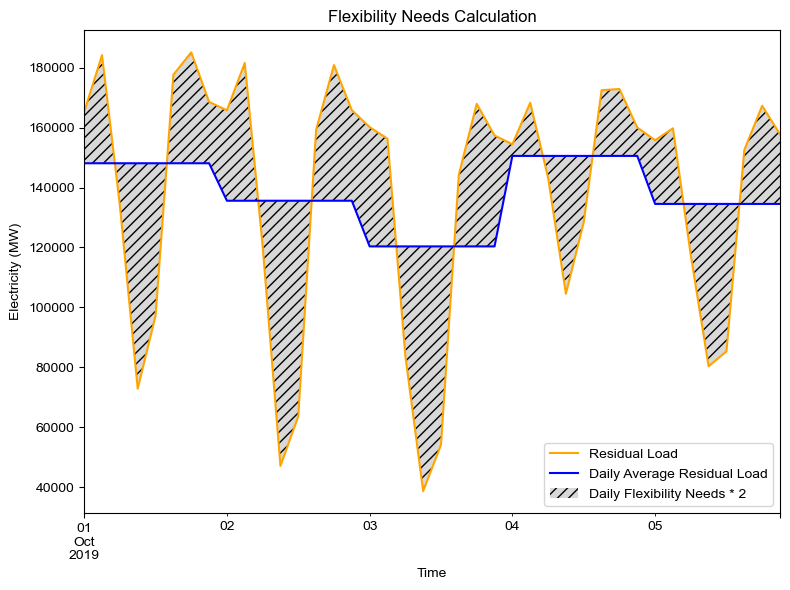

In [107]:
# Visualization of the method

period = slice("2019-10-01", "2019-10-05")

fig, ax = plt.subplots(figsize=(8, 6))

residual_load[period].plot(ax=ax, label='Residual Load', color='orange')
daily_average_hourly[period].plot(ax=ax, label='Daily Average Residual Load', color='blue')

# Fill the difference (flexibility needs)
ax.fill_between(
    residual_load[period].index,
    residual_load[period],
    daily_average_hourly[period],
    where=(residual_load[period] > daily_average_hourly[period]) | (residual_load[period] < daily_average_hourly[period]),
    facecolor='grey',
    alpha=0.3,
    hatch='///',
    label='Daily Flexibility Needs * 2'
)

ax.set_title('Flexibility Needs Calculation')
ax.set_xlabel('Time')
ax.set_ylabel('Electricity (MW)')
ax.legend()
plt.tight_layout()
plt.show()


- directly relates to: https://www.artelys.com/app/docs/supergrid/kpis/scalar_kpis/flexibility_needs.html
- the days are not connected with vertical lines as in the Artelys example; makes no difference as the diff between the residual load and its average is not calculated in this area but for every discrete timestep (visualisation issue)
- .clip(lower=0) ensures that we onl use the positive part of the flexibility needs. This is the same as taking the absolute of the diff and then divide by 2

**Why the factor ½ in daily flexibility needs?**

The factor **½** avoids **double-counting**: absolute deviations count both surpluses **and** deficits, but shifting once already balances both sides.

**Definition**
$F_d=\frac{1}{2}\sum_{t\in d}\left|L_t-\bar{L}_d\right|.$

**Example**
Residual load vs. daily mean: 1 pm: **+10 MWh**, 3 am: **−10 MWh**.

Absolute sum:
$|+10|+|-10|=20.$

Only **10 MWh** must actually be shifted, so:
$F_d=\tfrac{1}{2}\cdot 20=10.$

The ½ makes the metric equal to the **actual energy that must be shifted** to flatten the residual load.

<Axes: xlabel='snapshot'>

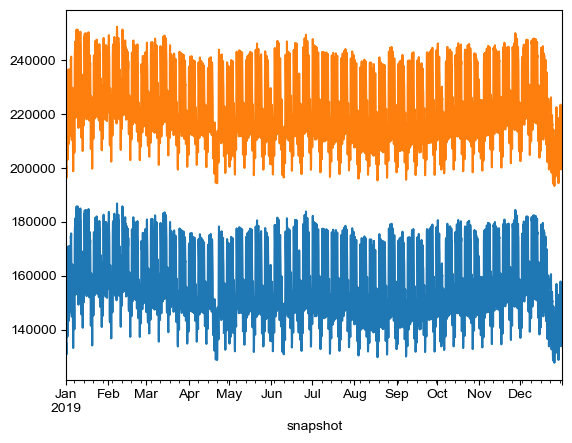

In [83]:
n = networks[2020]
es2020, ed2020 = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)

n = networks[2045]
es2045, ed2045 = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)

ed2020.loc[load_carriers].sum().plot()
ed2045.loc[load_carriers].sum().plot()

# electricity load has the same variations in all years -> unrealistic?, with higher magnitude the variations should also increase

In [98]:
# calc cause for flexibility needs

years = np.arange(2020, 2050, 5)
result_flex_cause_d = pd.DataFrame(index=["overall"] + vre_gens + ["load"], columns=years)

for year in years:

    n = networks[year]
    electricity_supply, electricity_demand = \
    supply_demand(n, 
                  interconnectors=False, 
                  merge_dist_grid=True, 
                  drop_dist_grid=False, 
                  add_diff_as_import=True)
    non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index
    vre_gen = electricity_supply.loc[vre_gens].sum()
    load = electricity_demand.loc[load_carriers].sum()

    for causer in result_flex_cause_d.index:

        if causer == "overall":
            add = 0
        elif causer =="load":
            add = vre_gen
        else:
            add = electricity_supply.loc[causer]

        residual_load = load - vre_gen + add

        # Compute daily average of residual load
        daily_average_residual = residual_load.resample('D').mean()

        # Expand daily averages to hourly resolution for comparison
        daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

        # Compute the difference between residual load and daily average (only the positive part)
        hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

        # Calculate daily flexibility needs 
        daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

        # Calculate total annual flexibility needs
        total_annual_flexibility = hourly_flexibility_needs.sum() / 2

        if causer in ["overall" , "load"]:
            result_flex_cause_d.loc[causer, year] = round(total_annual_flexibility / 1e6, 4)
        else:
            result_flex_cause_d.loc[causer, year] = round(result_flex_cause_d.loc["overall", year] - total_annual_flexibility / 1e6, 4)

Flexibility Needs: 105.90 MWh
Summe der Beiträge (vorzeichenbehaftet): 105.90 MWh
Summe der Beträge der Assets: 105.90 MWh


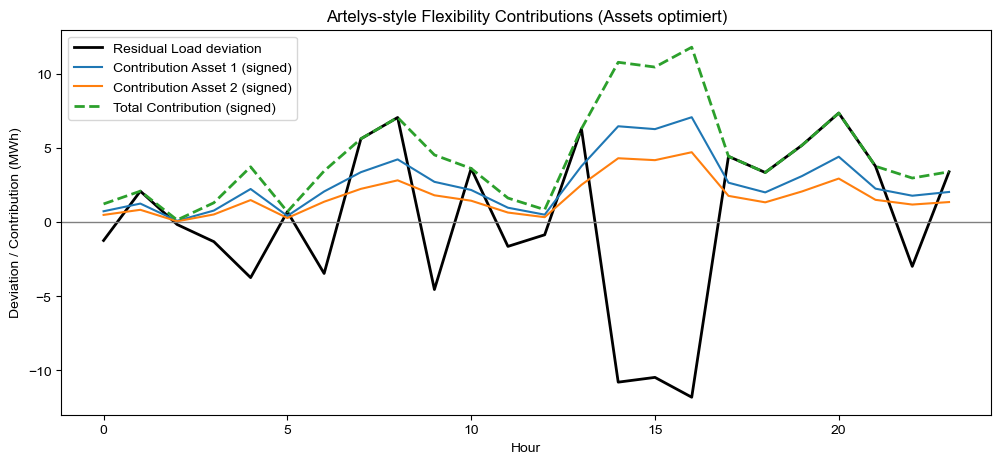

In [163]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
T = 24  # Stunden
np.random.seed(0)

# Residual Load (Abweichungen vom Mittelwert)
R = np.random.uniform(40, 60, T)
R_mean = R.mean()
R_dev = R - R_mean
F_need = np.sum(np.abs(R_dev))  # Flexibility Needs
print(f"Flexibility Needs: {F_need:.2f} MWh")

# --- Assets so anpassen, dass sie die Residual Load abfedern ---
# Asset 1 übernimmt 60% der Abweichungen
P1_dev = 0.6 * R_dev
# Asset 2 übernimmt 40% der Abweichungen
P2_dev = 0.4 * R_dev

# Vorzeichenbehaftete Beiträge (Artelys)
C1 = np.sign(R_dev) * P1_dev
C2 = np.sign(R_dev) * P2_dev
C_total = C1 + C2

print(f"Summe der Beiträge (vorzeichenbehaftet): {C_total.sum():.2f} MWh")

# Summe der Beträge der Assets (falsch, nur zum Vergleich)
abs_sum = np.sum(np.abs(P1_dev)) + np.sum(np.abs(P2_dev))
print(f"Summe der Beträge der Assets: {abs_sum:.2f} MWh")

# --- Plot ---
plt.figure(figsize=(12,5))
plt.plot(R_dev, label="Residual Load deviation", lw=2, color="black")
# plt.plot(P1_dev, label="Asset 1", color="blue")
# plt.plot(P2_dev, label="Asset 2", color="orange")
plt.plot(C1, label="Contribution Asset 1 (signed)")
plt.plot(C2, label="Contribution Asset 2 (signed)")
plt.plot(C_total, label="Total Contribution (signed)", lw=2, ls="--")
plt.axhline(0, color='grey', lw=1)
plt.title("Artelys-style Flexibility Contributions (Assets optimiert)")
plt.xlabel("Hour")
plt.ylabel("Deviation / Contribution (MWh)")
plt.legend()
plt.show()


In [159]:
electricity_supply[electricity_supply["snapshot"] < '2019-01-08']

KeyError: 'snapshot'

In [ ]:
residual_load = load - vre_gen

# Compute daily average of residual load
daily_average_residual = residual_load.resample('D').mean()

# Expand daily averages to hourly resolution for comparison
daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

# Compute the difference between residual load and daily average (only the positive part)
hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

# Calculate daily flexibility needs 
daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

# Calculate total annual flexibility needs
total_annual_flexibility = hourly_flexibility_needs.sum()

In [124]:
# minimal example (one day)
load = [1, 4, 5, 3]
gen1 = [0, 3, 4, 1]
gen2 = [1, 1, 1, 2]

In [125]:
residual_load = load - gen1 - gen2

# Compute daily average of residual load
daily_average_residual = residual_load.resample('D').mean()

# Expand daily averages to hourly resolution for comparison
daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

# Compute the difference between residual load and daily average (only the positive part)
hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

# Calculate daily flexibility needs 
daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

# Calculate total annual flexibility needs
total_annual_flexibility = hourly_flexibility_needs.sum()

TypeError: unsupported operand type(s) for -: 'list' and 'list'

<Axes: xlabel='snapshot'>

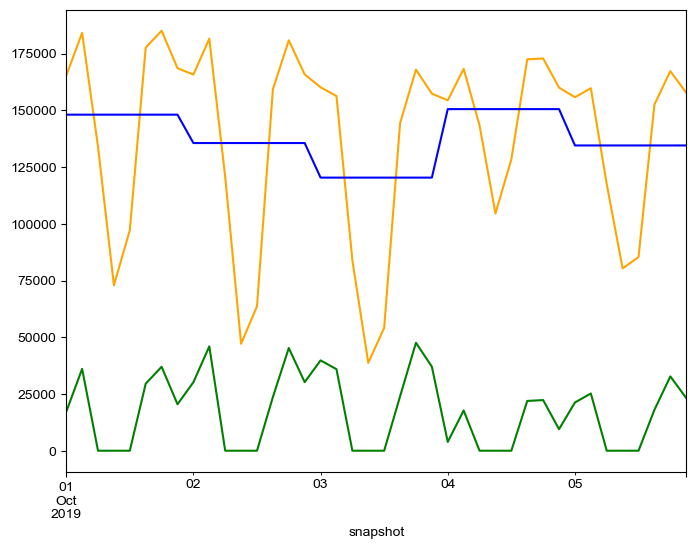

In [108]:
fig, ax = plt.subplots(figsize=(8, 6))
residual_load[period].plot(ax=ax, label='Residual Load', color='orange')
daily_average_hourly[period].plot(ax=ax, label='Daily Average Residual Load', color='blue')
hourly_flexibility_needs[period].plot(ax=ax, label='Hourly Flexibility Needs', color='green')


In [127]:
result_flex_cause_d

,2020,2025,2030,2035,2040,2045
overall,10.7847,10.78,41.2577,75.0356,99.6612,101.8894
solar,4.3439,4.3551,13.0723,38.5659,63.1539,65.3376
solar rooftop,0.0003,0.0177,30.9075,40.5922,40.7769,40.8219
load,6.441,6.441,6.441,6.441,6.441,6.441


In [126]:
result_flex_cause_d.drop("overall", axis=0).sum()

2020     10.7852
2025     10.8138
2030     50.4208
2035     85.5991
2040    110.3718
2045    112.6005
dtype: object

In [131]:
# calc provider and amount of flexibility
load_carriers=["electricity", "agriculture electricity", "industry electricity"]
vre_gens=["onwind", "offwind-ac", "offwind-dc", "solar", "solar-hsat","solar rooftop", "ror"]

years = np.arange(2020, 2050, 5)

result_single = pd.DataFrame(index=all_flex_techs, columns=years)
result_cumulative = pd.DataFrame(index=all_flex_techs, columns=years)

for year in years:
    n = networks[year]
    
    for cumulative in [True, False]:

        if cumulative:
            electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)
        else:
            electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)

        non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index

        vre_gen = electricity_supply.loc[vre_gens].sum()
        load = electricity_demand.loc[load_carriers].sum()
        
        residual_load = load - vre_gen

        for flex_tech in all_flex_techs:
            
            # 1. Calculate initial residual load
            if flex_tech == "no":
                sub = 0
            elif flex_tech in flex_techs_supply.keys():
                count = sum(item in electricity_supply.index for item in flex_techs_supply[flex_tech]) # how many of the techs are present
                techs = [item for item in flex_techs_supply[flex_tech] if item in electricity_supply.index] # which techs are present
                if count > 1:
                    sub = electricity_supply.loc[techs].sum()
                elif count == 1:
                    sub = electricity_supply.loc[techs[0]]
                else:
                    print(f"Flex tech {flex_tech} not in electricity supply for year {year}")
                    continue
            elif flex_tech in flex_techs_demand.keys():
                count = sum(item in electricity_demand.index for item in flex_techs_demand[flex_tech])
                techs = [item for item in flex_techs_demand[flex_tech] if item in electricity_demand.index]
                if count > 1:
                    sub = electricity_demand.loc[techs].sum() * -1
                elif count == 1:
                    sub = electricity_demand.loc[techs[0]] * -1
                else:
                    print(f"Flex tech {flex_tech} not in electricity demand for year {year}")
                    continue
            else:
                print(f"Flex tech {flex_tech} not in any flex tech list")
                continue

            if cumulative:
                residual_load = residual_load - sub
            else:
                residual_load = load - vre_gen - sub

            # 2. Compute daily average of residual load
            daily_average_residual = residual_load.resample('D').mean()

            # Expand daily averages to hourly resolution for comparison
            daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

            # 3. Compute the difference between residual load and daily average (only the positive part)
            hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

            # Calculate daily flexibility needs 
            daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

            # 4. Calculate total annual flexibility needs
            total_annual_flexibility = hourly_flexibility_needs.sum()

            if cumulative:
                result_cumulative.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2)
            else: 
                result_single.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2) 

Flex tech interconnectors supply not in electricity supply for year 2020
Flex tech H2 OCGT not in electricity supply for year 2020
Flex tech H2 CHP not in electricity supply for year 2020
Flex tech interconnectors demand not in electricity demand for year 2020
Flex tech interconnectors supply not in electricity supply for year 2020
Flex tech H2 OCGT not in electricity supply for year 2020
Flex tech H2 CHP not in electricity supply for year 2020
Flex tech interconnectors demand not in electricity demand for year 2020
Flex tech interconnectors supply not in electricity supply for year 2025
Flex tech nuclear not in electricity supply for year 2025
Flex tech H2 OCGT not in electricity supply for year 2025
Flex tech H2 CHP not in electricity supply for year 2025
Flex tech interconnectors demand not in electricity demand for year 2025
Flex tech interconnectors supply not in electricity supply for year 2025
Flex tech nuclear not in electricity supply for year 2025
Flex tech H2 OCGT not in ele

#### Single

In [132]:
df_all_single_d = pd.DataFrame()

for year in np.arange(2020, 2050, 5):
    df = result_single[year]
    no_total_i = df.drop("no").index
    # calc flexibility contribution 
    df[no_total_i] = -(result_single[year] - result_single[year].loc["no"])[no_total_i]
    df_all_single_d = pd.concat([df_all_single_d,df], axis=1)

df_all_single_d

,2020,2025,2030,2035,2040,2045
no,25.65,54.91,115.94,186.12,230.57,237.24
interconnectors supply,NaN,NaN,NaN,NaN,NaN,NaN
import,2.26,4.55,10.34,4.35,-0.25,0.25
coal,6.12,15.17,0.29,0.13,NaN,NaN
gas,1.83,8.98,6.73,1.19,0.6,0.58
biogas,2.95,2.66,0.99,0.03,NaN,NaN
oil,-0.0,-0.0,0.01,0.01,0.01,0.01
nuclear,2.59,NaN,NaN,NaN,NaN,NaN
solid biomass,0.06,0.01,0.01,-0.0,NaN,NaN
PHS discharging,0.04,1.12,3.03,2.56,2.14,1.96


In [133]:
df_all_single_d.drop(["no"], errors="ignore").sum()

2020     23.33
2025     50.12
2030    110.99
2035    177.66
2040    218.18
2045    224.51
dtype: object

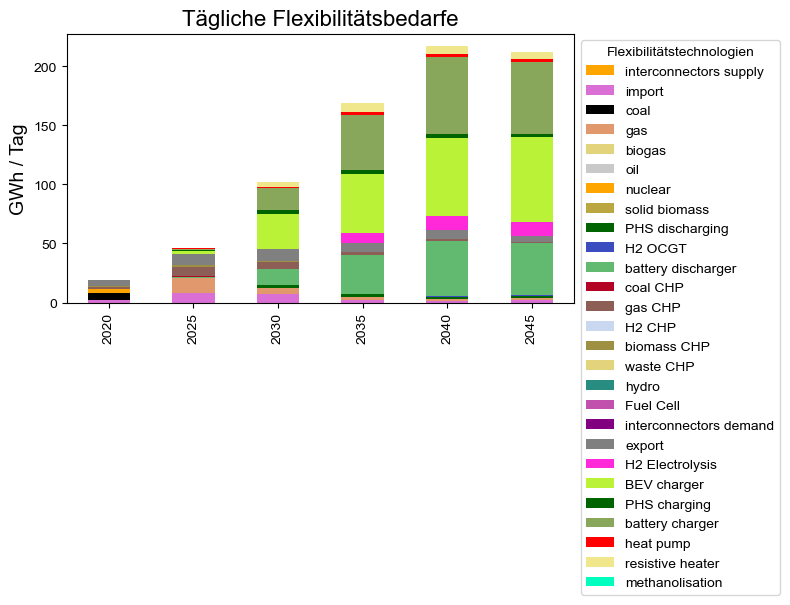

In [ ]:
df = df_all_single_d.drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("GWh / Tag", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# nice plot
df_single_overall_light_d = df_all_single_d.copy()
df_single_overall_light_d.loc["Import/Export"] = df_single_overall_light_d.loc[["import", "export"]].sum()
df_single_overall_light_d.loc["PHS"] = df_single_overall_light_d.loc[["PHS charging", "PHS discharging"]].sum()
df_single_overall_light_d = df_single_overall_light_d.drop(["import", "export", "interconnectors supply", "interconnectors demand", "PHS charging", "PHS discharging"])

# drop rows which have less than 1 % of the total flexibility needs in all years
shares = df_single_overall_light_d / df_single_overall_light_d.drop("no").sum() 
techs = shares[shares > 0.01].dropna(how="all").index 
df_single_overall_light_d = df_single_overall_light_d.loc[techs]
sorted_techs = df_single_overall_light_d.sum(axis=1).sort_values(ascending=False).index
df_single_overall_light_d = df_single_overall_light_d.loc[sorted_techs]
df_single_overall_light_d.loc["Sonstige"] = df_single_overall_light_d.loc["no"] - df_single_overall_light_d.drop("no").sum() 
df_single_overall_light_d = df_single_overall_light_d.drop("no")

In [ ]:
df_single_overall_light_d * 1e3 / 365

,2020,2025,2030,2035,2040,2045
BEV charger,-0.109589,7.479452,80.684932,135.589041,181.178082,196.630137
battery charger,-0.0,2.054795,50.876712,126.60274,178.383562,167.041096
battery discharger,-0.0,1.589041,38.30137,91.753425,127.561644,118.90411
Import/Export,18.575342,48.575342,49.39726,27.287671,25.205479,20.109589
H2 Electrolysis,-0.0,-0.0,-0.0,23.69863,31.041096,32.547945
resistive heater,-0.0,0.136986,10.767123,21.726027,17.890411,15.342466
gas,0.219178,33.123288,14.520548,5.945205,5.150685,5.123288
PHS,0.657534,4.328767,14.356164,15.616438,13.643836,11.178082
gas CHP,5.671233,20.30137,14.821918,5.287671,3.671233,2.712329
heat pump,-0.0,0.520548,2.958904,7.09589,7.643836,7.917808


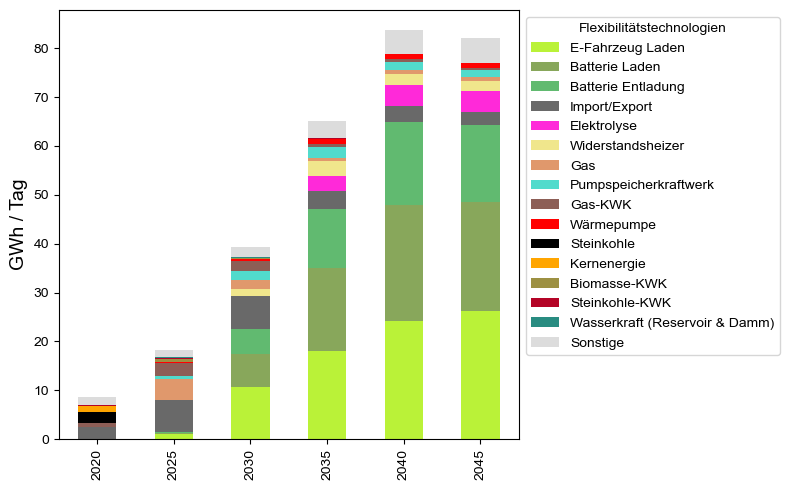

In [ ]:
df = (df_single_overall_light_d / 1e3 * 365)

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  
# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
# ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("GWh / Tag", fontsize=14)

# Move the legend outside the plot
ax.legend(
    labels = [carriers_in_german.get(l, l) for l in df.index],
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

plt.savefig(PLOT_DIR+"/daily_flex_single_nice")

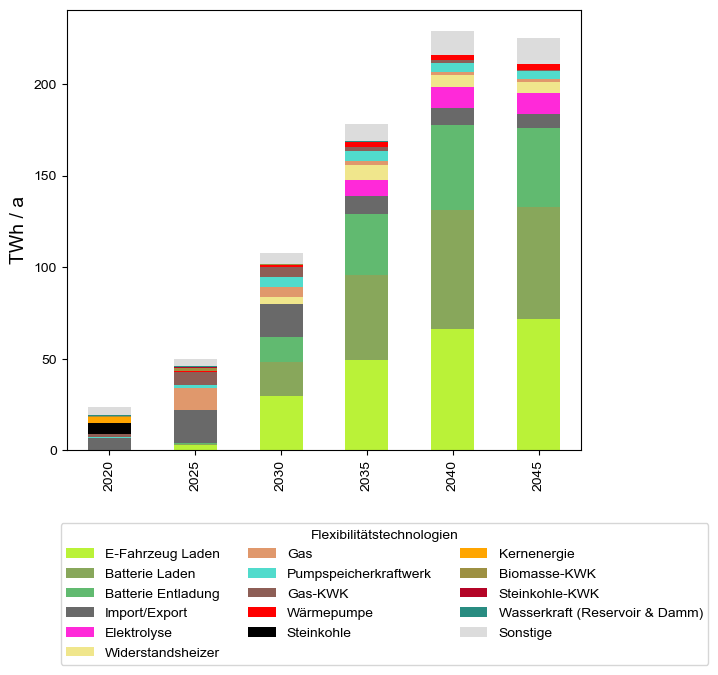

In [ ]:
df = df_single_overall_light_d

# Set plot properties
fig, ax = plt.subplots(figsize=(7, 7))  
# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
# ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh / a", fontsize=14)

# Move the legend outside the plot
ax.legend(
    labels = [carriers_in_german.get(l, l) for l in df.index],
    loc='upper left',
    # bbox_to_anchor=(1, 1),  # Position the legend outside
    bbox_to_anchor=(-0.025, -0.15),
    ncol=3,
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

plt.savefig(PLOT_DIR+"/daily_flex_single_nice_new")

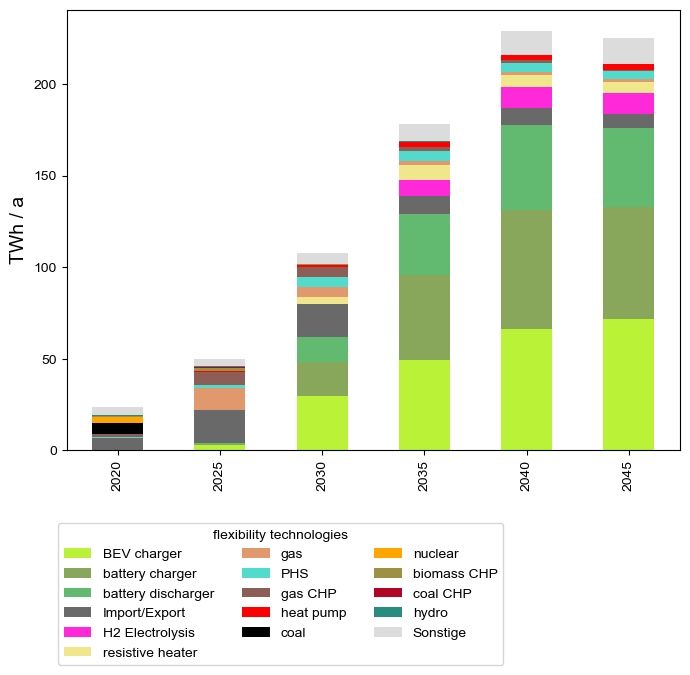

In [ ]:
df = df_single_overall_light_d

# Set plot properties
fig, ax = plt.subplots(figsize=(7, 7))  
# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
# ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh / a", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    # bbox_to_anchor=(1, 1),  # Position the legend outside
    bbox_to_anchor=(-0.025, -0.15),
    ncol=3,
    title="flexibility technologies"
)

# Tighten the layout to fit everything
plt.tight_layout()

plt.savefig(PLOT_DIR+"/daily_flex_single_nice_new_english")

In [ ]:
df_single_overall_light_d

,2020,2025,2030,2035,2040,2045
BEV charger,-0.04,2.73,29.45,49.49,66.13,71.77
battery charger,-0.0,0.75,18.57,46.21,65.11,60.97
battery discharger,-0.0,0.58,13.98,33.49,46.56,43.4
Import/Export,6.78,17.73,18.03,9.96,9.2,7.34
H2 Electrolysis,-0.0,-0.0,-0.0,8.65,11.33,11.88
resistive heater,-0.0,0.05,3.93,7.93,6.53,5.6
gas,0.08,12.09,5.3,2.17,1.88,1.87
PHS,0.24,1.58,5.24,5.7,4.98,4.08
gas CHP,2.07,7.41,5.41,1.93,1.34,0.99
heat pump,-0.0,0.19,1.08,2.59,2.79,2.89


#### Cumulative

In [ ]:
df_all_cum_d = pd.DataFrame()

for year in np.arange(2020, 2050, 5):
    df = result_cumulative[year].dropna().diff() * -1
    df_all_cum_d = pd.concat([df_all_cum_d,df], axis=1)

df_all_cum_d

,2020,2025,2030,2035,2040,2045
no,NaN,NaN,NaN,NaN,NaN,NaN
import,1.88,8.35,7.37,2.5,1.21,2.34
coal,6.58,0.03,0.01,0.13,NaN,NaN
gas,0.09,12.67,5.24,2.13,1.87,1.83
oil,-0.0,-0.0,-0.0,0.01,-0.0,0.01
nuclear,3.33,NaN,NaN,NaN,NaN,NaN
solid biomass,-0.0,-0.0,-0.0,-0.0,NaN,NaN
PHS discharging,0.11,0.5,1.87,2.16,1.84,1.48
battery discharger,-0.0,0.48,13.74,33.44,46.36,43.15
coal CHP,0.21,0.81,0.16,0.06,0.02,NaN


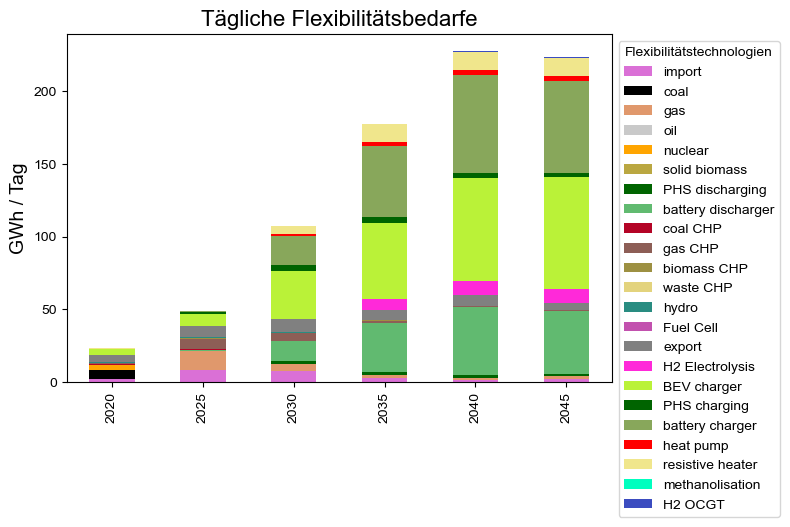

In [ ]:
df = df_all_cum_d.drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("GWh / Tag", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()

### Weekly

In [ ]:
years = np.arange(2020, 2050, 5)

result_single = pd.DataFrame(index=all_flex_techs, columns=years)
result_cumulative = pd.DataFrame(index=all_flex_techs, columns=years)

for year in years:
    n = networks[year]
    
    for cumulative in [True, False]:

        if cumulative:
            electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)
        else:
            electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)

        non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index

        vre_gen = electricity_supply.loc[vre_gens].sum()
        load = electricity_demand.loc[load_carriers].sum()
        
        residual_load = load - vre_gen

        for flex_tech in all_flex_techs:
            
            # 1. Calculate initial residual load
            if flex_tech == "no":
                sub = 0
            elif flex_tech in flex_techs_supply.keys():
                count = sum(item in electricity_supply.index for item in flex_techs_supply[flex_tech]) # how many of the techs are present
                techs = [item for item in flex_techs_supply[flex_tech] if item in electricity_supply.index] # which techs are present
                if count > 1:
                    sub = electricity_supply.loc[techs].sum()
                elif count == 1:
                    sub = electricity_supply.loc[techs[0]]
                else:
                    print(f"Flex tech {flex_tech} not in electricity supply for year {year}")
                    continue
            elif flex_tech in flex_techs_demand.keys():
                count = sum(item in electricity_demand.index for item in flex_techs_demand[flex_tech])
                techs = [item for item in flex_techs_demand[flex_tech] if item in electricity_demand.index]
                if count > 1:
                    sub = electricity_demand.loc[techs].sum() * -1
                elif count == 1:
                    sub = electricity_demand.loc[techs[0]] * -1
                else:
                    print(f"Flex tech {flex_tech} not in electricity demand for year {year}")
                    continue
            else:
                print(f"Flex tech {flex_tech} not in any flex tech list")
                continue

            if cumulative:
                residual_load = residual_load - sub
            else:
                residual_load = load - vre_gen - sub

            # Compute daily average of residual load
            daily_average_residual = residual_load.resample('D').mean()

            # Expand daily averages to hourly resolution for comparison
            daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

            # Compute weekly average of daily averages
            weekly_average_residual = daily_average_residual.resample('W').mean()
            weekly_average_hourly = weekly_average_residual.reindex(residual_load.index, method='ffill')

            # Compute the difference between daily average amy weekly average (only the positive part)
            weekly_flexibility_needs = (daily_average_hourly - weekly_average_hourly).clip(lower=0)

            # Calculate weekly flexibility needs 
            weekly_flexibility_needs = weekly_flexibility_needs.resample('W').sum()

            # Calculate total weekly flexibility needs for one year (TWh/a)
            total_annual_flexibility = weekly_flexibility_needs.sum()

            if cumulative:
                result_cumulative.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2)
            else: 
                result_single.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2) 

584.90210727387
584.90210727387
Flex tech interconnectors supply not in electricity supply for year 2020
Flex tech biogas not in electricity supply for year 2020
Flex tech H2 OCGT not in electricity supply for year 2020
Flex tech H2 CHP not in electricity supply for year 2020
Flex tech interconnectors demand not in electricity demand for year 2020
584.90210727387
584.90210727387
Flex tech interconnectors supply not in electricity supply for year 2020
Flex tech biogas not in electricity supply for year 2020
Flex tech H2 OCGT not in electricity supply for year 2020
Flex tech H2 CHP not in electricity supply for year 2020
Flex tech interconnectors demand not in electricity demand for year 2020
620.1674603276399
620.1674603276399
Flex tech interconnectors supply not in electricity supply for year 2025
Flex tech biogas not in electricity supply for year 2025
Flex tech nuclear not in electricity supply for year 2025
Flex tech H2 OCGT not in electricity supply for year 2025
Flex tech H2 CHP n

#### Single

In [ ]:
df_all_single_w = pd.DataFrame()

for year in np.arange(2020, 2050, 5):
    df = result_single[year]
    no_total_i = df.drop("no").index
    # calc flexibility contribution 
    df[no_total_i] = -(result_single[year] - result_single[year].loc["no"])[no_total_i]
    df_all_single_w = pd.concat([df_all_single_w,df], axis=1)

df_all_single_w

,2020,2025,2030,2035,2040,2045
no,34.46,46.31,83.44,114.95,135.41,137.4
interconnectors supply,NaN,NaN,NaN,NaN,NaN,NaN
import,2.79,7.15,14.9,22.59,25.95,30.86
coal,11.49,0.05,0.01,0.22,NaN,NaN
gas,0.19,14.32,14.45,7.26,6.36,7.86
biogas,NaN,NaN,NaN,NaN,NaN,NaN
oil,-0.0,-0.0,-0.0,0.01,0.01,0.03
nuclear,4.89,NaN,NaN,NaN,NaN,NaN
solid biomass,0.01,-0.0,-0.0,-0.0,NaN,NaN
PHS discharging,0.09,0.14,-0.11,0.05,-0.02,0.02


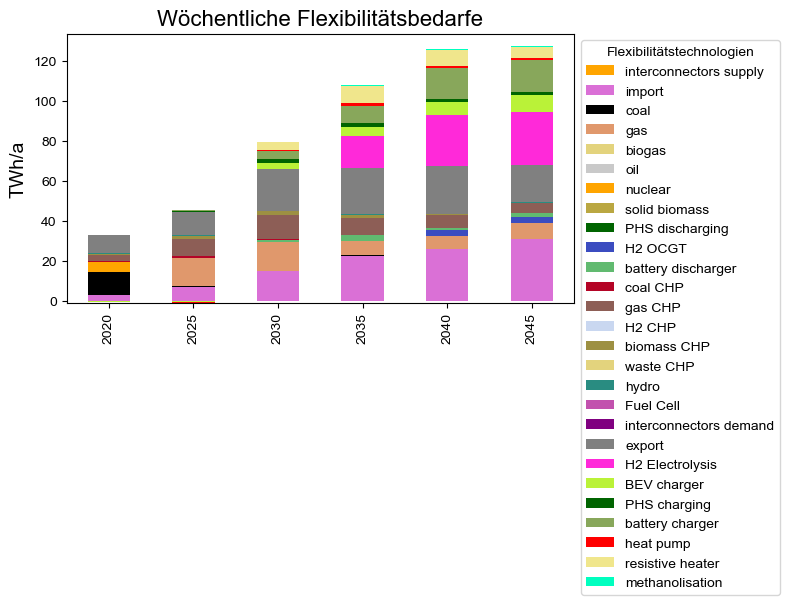

In [ ]:
df = df_all_single_w.drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Wöchentliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh/a", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# nice plot
df_single_overall_light_w = df_all_single_w.copy()
df_single_overall_light_w.loc["Import/Export"] = df_single_overall_light_w.loc[["import", "export"]].sum()
df_single_overall_light_w.loc["PHS"] = df_single_overall_light_w.loc[["PHS charging", "PHS discharging"]].sum()
df_single_overall_light_w = df_single_overall_light_w.drop(["import", "export", "interconnectors supply", "interconnectors demand", "PHS charging", "PHS discharging"])

# drop rows which have less than 1 % of the total flexibility needs in all years
shares = df_single_overall_light_w / df_single_overall_light_w.drop("no").sum() 
techs = shares[shares > 0.01].dropna(how="all").index 
df_single_overall_light_w = df_single_overall_light_w.loc[techs]
sorted_techs = df_single_overall_light_w.sum(axis=1).sort_values(ascending=False).index
df_single_overall_light_w = df_single_overall_light_w.loc[sorted_techs]
df_single_overall_light_w.loc["Sonstige"] = df_single_overall_light_w.loc["no"] - df_single_overall_light_w.drop("no").sum() 
df_single_overall_light_w = df_single_overall_light_w.drop("no")

In [ ]:
df_single_overall_light_w / 52

,2020,2025,2030,2035,2040,2045
Import/Export,0.225577,0.355192,0.685962,0.878462,0.959423,0.945385
H2 Electrolysis,-0.0,-0.0,-0.0,0.311154,0.483077,0.513654
gas,0.003654,0.275385,0.277885,0.139615,0.122308,0.151154
battery charger,-0.0,0.005577,0.078269,0.166923,0.297308,0.3025
gas CHP,0.060192,0.163654,0.234231,0.160385,0.125192,0.103654
resistive heater,-0.003077,-0.002308,0.073654,0.164231,0.152692,0.110385
BEV charger,-0.006923,-0.012692,0.062885,0.085769,0.125962,0.161154
coal,0.220962,0.000962,0.000192,0.004231,NaN,NaN
PHS,0.006154,0.019038,0.035385,0.034808,0.035577,0.031731
battery discharger,-0.0,-0.000962,0.019231,0.049423,0.024615,0.035


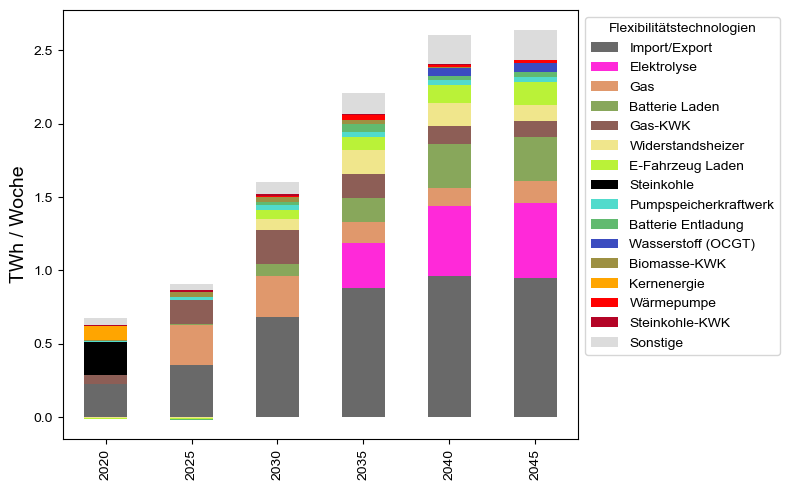

In [ ]:
df = (df_single_overall_light_w / 52)

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  
# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
# ax.set_title("Wöchentliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh / Woche", fontsize=14)

# Move the legend outside the plot
ax.legend(
    labels = [carriers_in_german.get(l, l) for l in df.index],
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

plt.savefig(PLOT_DIR+"/weekly_flex_single_nice")

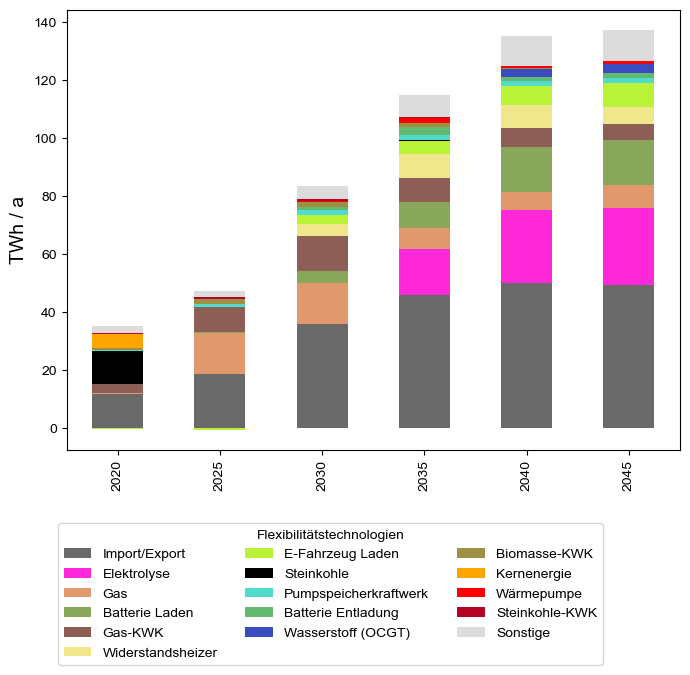

In [ ]:
df = df_single_overall_light_w 

# Set plot properties
fig, ax = plt.subplots(figsize=(7, 7))  
# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
# ax.set_title("Wöchentliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh / a", fontsize=14)

# Move the legend outside the plot
ax.legend(
    labels = [carriers_in_german.get(l, l) for l in df.index],
    loc='upper left',
    bbox_to_anchor=(-0.025, -0.15),
    ncol=3,
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

plt.savefig(PLOT_DIR+"/weekly_flex_single_nice_new")

In [ ]:
# adjust tech_colors

# carrier names manual
tech_colors["battery discharger"] = n.carriers.color["battery discharger"]
tech_colors["urban central oil CHP"] = n.carriers.color["oil"]
tech_colors["Solar"] = n.carriers.color["solar"]
tech_colors["Electricity load"] = n.carriers.color["electricity"]
tech_colors["Electricity trade"] = n.carriers.color["AC"]
tech_colors["Offshore Wind"] = n.carriers.color["offwind-ac"]
tech_colors["urban decentral heat"] = n.carriers.color["urban central heat"]
tech_colors["H2 OCGT"] =    "#3b4cc0"
tech_colors["H2 retrofit OCGT"] = "#9abbff"
tech_colors["urban central H2 CHP"] = "#c9d7f0"
tech_colors["urban central H2 retrofit CHP"] = "#edd1c2"
tech_colors["H2 Electrolysis"] = "#9b2d91"# "#d93ccd"

### Ariadne plot

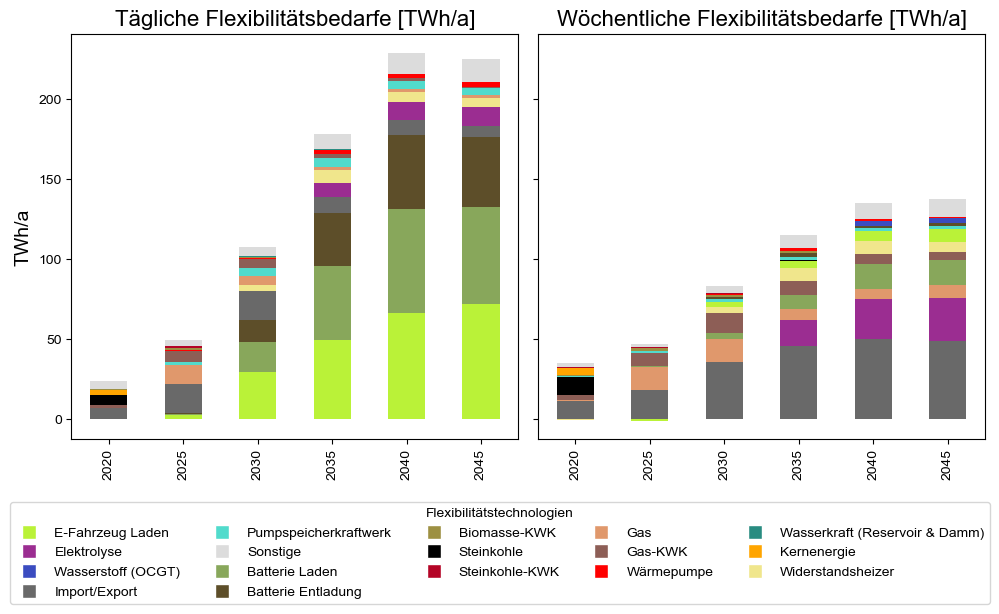

In [ ]:
# Set up the subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)  

# Plot for daily flexibility needs (df_single_overall_light_d)
colors_d = [tech_colors[tech] for tech in df_single_overall_light_d.index]
df_single_overall_light_d.T.plot(
    kind="bar",
    stacked=True,
    color=colors_d,
    ax=ax[0],
    legend=False  # Disable legend for the first plot
)
ax[0].set_ylabel("TWh/a", fontsize=14)
ax[0].set_title("Tägliche Flexibilitätsbedarfe [TWh/a]", fontsize=16)

# Plot for weekly flexibility needs (df_single_overall_light_w)
colors_w = [tech_colors[tech] for tech in df_single_overall_light_w.index]
df_single_overall_light_w.T.plot(
    kind="bar",
    stacked=True,
    color=colors_w,
    ax=ax[1],
    legend=False  # Disable legend for the second plot
)
ax[1].set_title("Wöchentliche Flexibilitätsbedarfe [TWh/a]", fontsize=16)

# Combine the distinct labels from both plots
# Get the unique technologies from both DataFrames
all_technologies = set(df_single_overall_light_d.index).union(df_single_overall_light_w.index)
# Sort to keep a consistent order
all_technologies = sorted(all_technologies)

# Create the legend handles and labels for all distinct technologies
handles, labels = [], []
for tech in all_technologies:
    handles.append(plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=tech_colors[tech], markersize=10))
    labels.append(carriers_in_german.get(tech, tech))

# Place the legend below both subplots
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0),  # Position below both plots
    ncol=5,
    title="Flexibilitätstechnologien"
)

# Tighten layout to ensure everything fits
plt.tight_layout()

# Save the combined plot
plt.savefig(PLOT_DIR + "/flexibility_needs_combined.png", bbox_inches='tight')

# save plot
plt.savefig(f"/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flexibility_needs_combined_{scenario}_{weather_year}.png", bbox_inches='tight')

# save df
df_single_overall_light_d.to_csv(f"/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_d_{scenario}_{weather_year}.csv")
df_single_overall_light_w.to_csv(f"/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_w_{scenario}_{weather_year}.csv")

# Show the plot
plt.show()


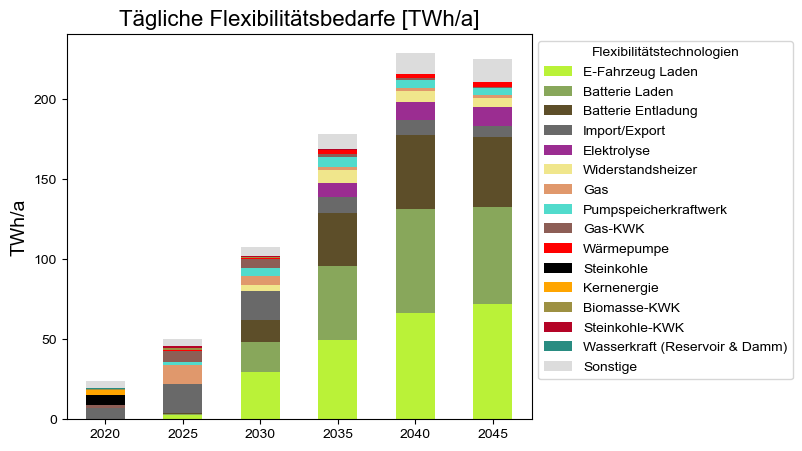

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

# Plot for daily flexibility needs (df_single_overall_light_d)
colors_d = [tech_colors[tech] for tech in df_single_overall_light_d.index]
df_single_overall_light_d.T.plot(
    kind="bar",
    stacked=True,
    color=colors_d,
    ax=ax,
    legend=False  # Disable legend for the first plot
)
ax.set_ylabel("TWh/a", fontsize=14)
plt.xticks(rotation=0)
ax.set_title("Tägliche Flexibilitätsbedarfe [TWh/a]", fontsize=16)
german_legend_labels = [carriers_in_german.get(tech, tech) for tech in df_single_overall_light_d.index]
ax.legend(german_legend_labels, loc='upper left', bbox_to_anchor=(1, 1), title="Flexibilitätstechnologien")
plt.savefig(PLOT_DIR + "/flexibility_needs_daily.pdf", bbox_inches='tight')

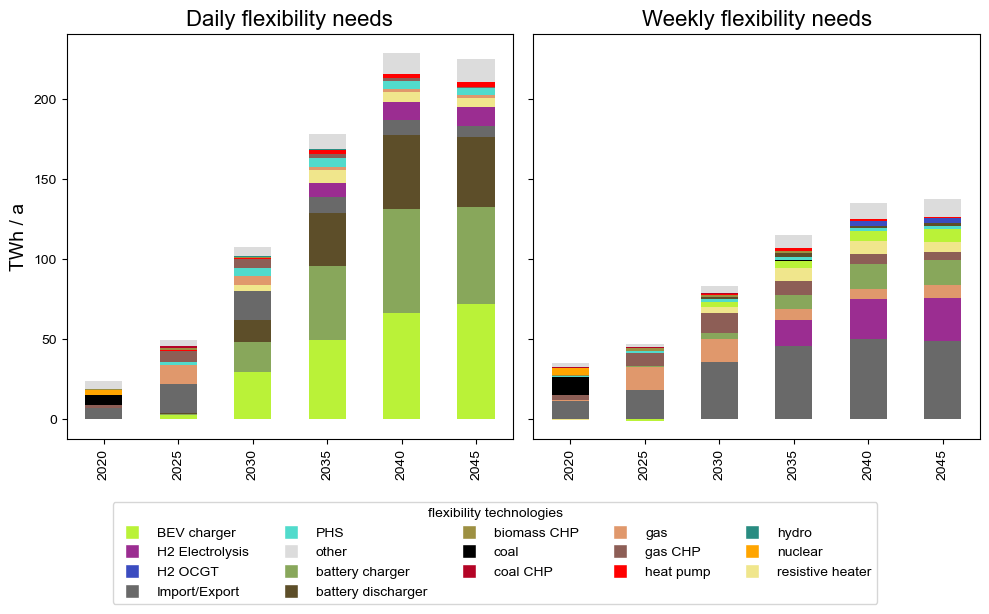

In [ ]:
# Set up the subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)  

# Plot for daily flexibility needs (df_single_overall_light_d)
colors_d = [tech_colors[tech] for tech in df_single_overall_light_d.index]
df_single_overall_light_d.T.plot(
    kind="bar",
    stacked=True,
    color=colors_d,
    ax=ax[0],
    legend=False  # Disable legend for the first plot
)
ax[0].set_ylabel("TWh / a", fontsize=14)
ax[0].set_title("Daily flexibility needs", fontsize=16)

# Plot for weekly flexibility needs (df_single_overall_light_w)
colors_w = [tech_colors[tech] for tech in df_single_overall_light_w.index]
df_single_overall_light_w.T.plot(
    kind="bar",
    stacked=True,
    color=colors_w,
    ax=ax[1],
    legend=False  # Disable legend for the second plot
)
ax[1].set_title("Weekly flexibility needs", fontsize=16)

# Combine the distinct labels from both plots
# Get the unique technologies from both DataFrames
all_technologies = set(df_single_overall_light_d.index).union(df_single_overall_light_w.index)
# Sort to keep a consistent order
all_technologies = sorted(all_technologies)

# Create the legend handles and labels for all distinct technologies
handles, labels = [], []
for tech in all_technologies:
    handles.append(plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=tech_colors[tech], markersize=10))
    labels.append(tech if tech != "Sonstige" else "other")


# Place the legend below both subplots
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0),  # Position below both plots
    ncol=5,
    title="flexibility technologies"
)

# Tighten layout to ensure everything fits
plt.tight_layout()

# Save the combined plot
plt.savefig(PLOT_DIR + "/flexibility_needs_combined_english", bbox_inches='tight')

# Show the plot
plt.show()

In [ ]:
df_single_overall_light_d

,2020,2025,2030,2035,2040,2045
BEV charger,-0.04,2.73,29.45,49.49,66.13,71.77
battery charger,-0.0,0.75,18.57,46.21,65.11,60.97
battery discharger,-0.0,0.58,13.98,33.49,46.56,43.4
Import/Export,6.78,17.73,18.03,9.96,9.2,7.34
H2 Electrolysis,-0.0,-0.0,-0.0,8.65,11.33,11.88
resistive heater,-0.0,0.05,3.93,7.93,6.53,5.6
gas,0.08,12.09,5.3,2.17,1.88,1.87
PHS,0.24,1.58,5.24,5.7,4.98,4.08
gas CHP,2.07,7.41,5.41,1.93,1.34,0.99
heat pump,-0.0,0.19,1.08,2.59,2.79,2.89


In [ ]:
df_single_overall_light_d.to_excel("df_single_overall_light_d.xlsx", index=True)

In [ ]:
df_single_overall_light_w

,2020,2025,2030,2035,2040,2045
Import/Export,11.73,18.47,35.67,45.68,49.89,49.16
H2 Electrolysis,-0.0,-0.0,-0.0,16.18,25.12,26.71
gas,0.19,14.32,14.45,7.26,6.36,7.86
battery charger,-0.0,0.29,4.07,8.68,15.46,15.73
gas CHP,3.13,8.51,12.18,8.34,6.51,5.39
resistive heater,-0.16,-0.12,3.83,8.54,7.94,5.74
BEV charger,-0.36,-0.66,3.27,4.46,6.55,8.38
coal,11.49,0.05,0.01,0.22,NaN,NaN
PHS,0.32,0.99,1.84,1.81,1.85,1.65
battery discharger,-0.0,-0.05,1.0,2.57,1.28,1.82


In [ ]:
df_single_overall_light_w.to_excel("df_single_overall_light_w.xlsx", index=True)


In [ ]:
fc_cp_2019_d = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_d_CurrentPolicies_2019.csv", index_col=0)
fc_cp_2019_w = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_w_CurrentPolicies_2019.csv", index_col=0)
fc_mix_2019_d = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_d_KN2045_Bal_v4_2019.csv", index_col=0)
fc_mix_2019_w = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_w_KN2045_Bal_v4_2019.csv", index_col=0)
fc_elec_2019_d = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_d_KN2045_Elec_v4_2019.csv", index_col=0)
fc_elec_2019_w = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_w_KN2045_Elec_v4_2019.csv", index_col=0)
fc_h2_2019_d = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_d_KN2045_H2_v4_2019.csv", index_col=0)
fc_h2_2019_w = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_w_KN2045_H2_v4_2019.csv", index_col=0)
fc_mix_1996_d = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_d_Mix_1996.csv", index_col=0)
fc_mix_1996_w = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_w_Mix_1996.csv", index_col=0)
fc_mix_2010_d = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_d_Mix_2010.csv", index_col=0)
fc_mix_2010_w = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_w_Mix_2010.csv", index_col=0)
fc_mix_2013_d = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_d_Mix_2013.csv", index_col=0)
fc_mix_2013_w = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_contribution_w_Mix_2013.csv", index_col=0)


In [ ]:
fc_mix_2019_d

,2020,2025,2030,2035,2040,2045
BEV charger,0.36,3.18,33.53,53.46,71.99,78.65
battery charger,-0.00,0.03,5.29,39.20,55.61,55.55
battery discharger,-0.00,0.02,3.77,27.87,38.64,38.34
Import/Export,8.33,12.07,26.90,13.87,7.16,4.03
H2 Electrolysis,-0.00,-0.00,3.46,10.02,18.44,19.27
resistive heater,-0.24,0.30,9.62,12.04,9.81,8.23
PHS,0.10,3.05,8.48,7.15,5.97,5.43
heat pump,-0.00,0.33,3.65,8.72,7.95,7.22
coal,6.12,14.99,0.28,0.13,NaN,NaN
gas,1.84,9.01,6.44,1.16,0.45,0.54


In [ ]:
fc_cp_2019_w

,2020,2025,2030,2035,2040,2045
Import/Export,11.84,13.52,37.88,50.00,56.18,58.19
gas CHP,0.84,2.47,10.97,8.00,11.82,10.25
coal,9.63,19.65,1.21,9.07,NaN,NaN
gas,3.63,6.72,11.04,6.46,5.04,4.38
H2 OCGT,NaN,NaN,-0.00,2.76,9.37,10.24
BEV charger,-0.30,-0.38,2.59,4.00,6.69,7.88
biogas,4.43,3.20,1.72,0.05,NaN,NaN
PHS,0.13,1.29,1.48,1.55,1.65,1.69
nuclear,4.34,NaN,NaN,NaN,NaN,NaN
coal CHP,0.92,0.63,1.25,1.07,0.13,NaN


Technologies found for Daily flexibility needs: ['BEV charger', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'Sonstige', 'battery charger', 'battery discharger', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']
Technologies found for Weekly flexibility needs: ['BEV charger', 'H2 CHP', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'Sonstige', 'battery charger', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']


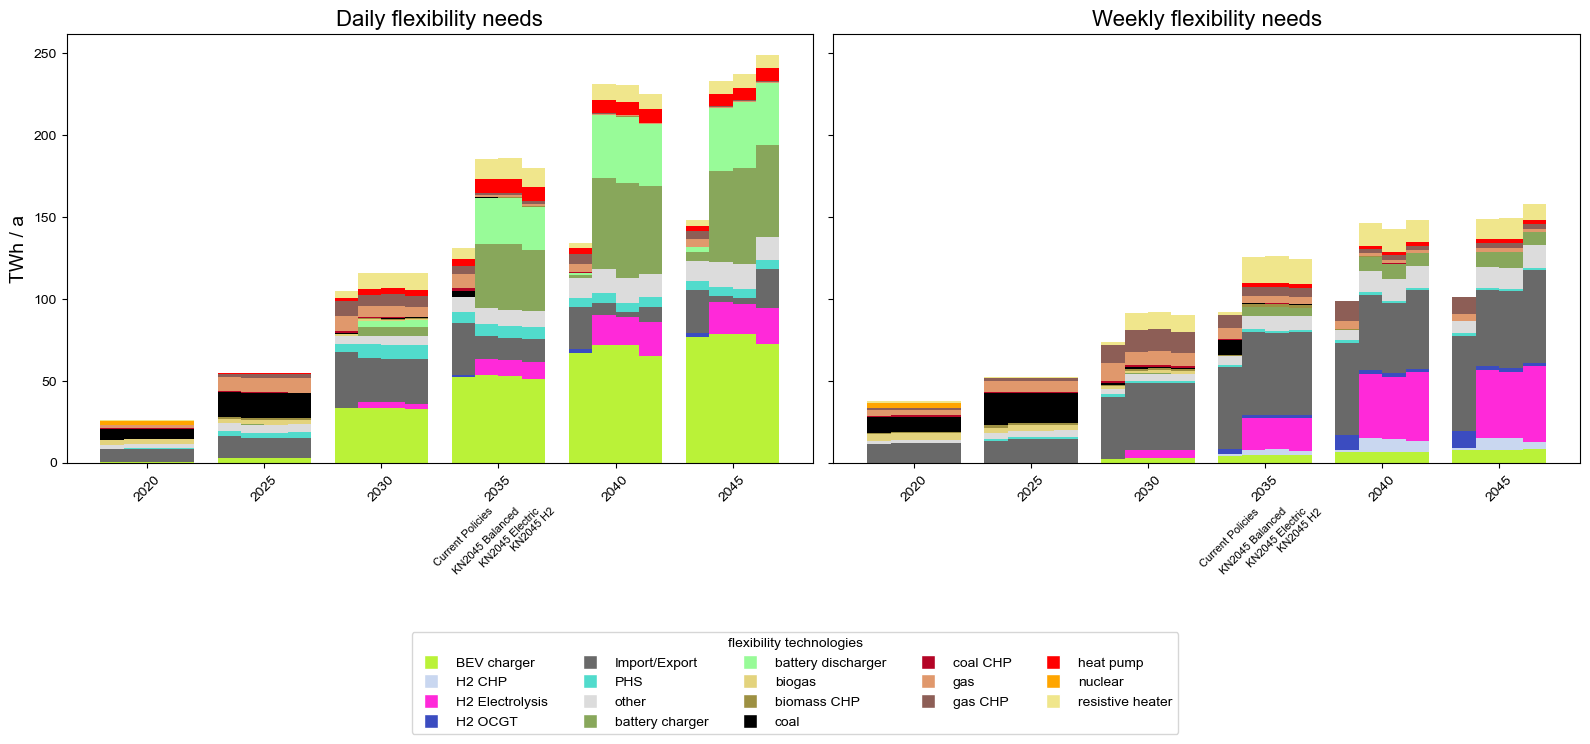

In [ ]:
import numpy as np

# Dictionary to store all dataframes
scenarios = {
    'Current Policies': {
        'daily': fc_cp_2019_d,
        'weekly': fc_cp_2019_w
    },
    'KN2045 Balanced': {
        'daily': fc_mix_2019_d,
        'weekly': fc_mix_2019_w
    },
    'KN2045 Electric': {
        'daily': fc_elec_2019_d,
        'weekly': fc_elec_2019_w
    },
    'KN2045 H2': {
        'daily': fc_h2_2019_d,
        'weekly': fc_h2_2019_w
    }
}

# Set up the subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Function to plot multiple scenarios as grouped bars
def plot_scenarios(ax_subplot, data_dict, title):
    # Get all years from the first scenario
    years = data_dict[list(scenarios.keys())[0]].columns
    
    # Set up positions for grouped bars
    n_scenarios = len(scenarios)
    n_years = len(years)
    bar_width = 0.8 / n_scenarios
    x_positions = np.arange(n_years)
    
    # Get all unique technologies across all scenarios for this plot type
    all_technologies = set()
    for scenario_name in scenarios.keys():
        if scenario_name in data_dict and not data_dict[scenario_name].empty:
            all_technologies.update(data_dict[scenario_name].index)
    all_technologies = sorted(all_technologies)
    
    # Debug: print technologies found
    print(f"Technologies found for {title}: {all_technologies}")
    
    # Plot each scenario
    for i, (scenario_name, df) in enumerate(data_dict.items()):
        # Calculate x positions for this scenario
        x_pos = x_positions + (i - n_scenarios/2 + 0.5) * bar_width
        
        # Prepare data for stacking
        bottom = np.zeros(len(years))
        
        # Plot each technology as part of the stack
        for tech in all_technologies:
            if tech in df.index:
                values = df.loc[tech].values
                # Handle NaN values by replacing with 0
                values = np.nan_to_num(values, nan=0.0)
            else:
                # If technology doesn't exist in this scenario, use zeros
                values = np.zeros(len(years))
            
            color = tech_colors.get(tech, 'gray')
            # Only plot if there are non-zero values
            if np.any(values != 0):
                ax_subplot.bar(x_pos, values, bar_width, bottom=bottom, 
                             color=color, label=tech if i == 0 else "")
            bottom += values
    
    # Customize the subplot
    ax_subplot.set_title(title, fontsize=16)
    ax_subplot.set_xticks(x_positions)
    ax_subplot.set_xticklabels(years, rotation=45)
    
    # Add scenario labels below x-axis
    scenario_labels = list(scenarios.keys())
    for i, scenario in enumerate(scenario_labels):
        x_pos = x_positions + (i - n_scenarios/2 + 0.5) * bar_width
        for j, x in enumerate(x_pos):
            if j == len(x_pos) // 2:  # Only label in the middle
                ax_subplot.text(x, ax_subplot.get_ylim()[0] - (ax_subplot.get_ylim()[1] - ax_subplot.get_ylim()[0]) * 0.1, 
                              scenario, ha='center', va='top', fontsize=8, rotation=45)

# Create data dictionaries for daily and weekly
daily_data = {name: info['daily'] for name, info in scenarios.items()}
weekly_data = {name: info['weekly'] for name, info in scenarios.items()}

# Plot daily flexibility needs
plot_scenarios(ax[0], daily_data, "Daily flexibility needs")
ax[0].set_ylabel("TWh / a", fontsize=14)

# Plot weekly flexibility needs  
plot_scenarios(ax[1], weekly_data, "Weekly flexibility needs")

# Get all unique technologies for legend
all_technologies = set()
for scenario_info in scenarios.values():
    all_technologies.update(scenario_info['daily'].index)
    all_technologies.update(scenario_info['weekly'].index)
all_technologies = sorted(all_technologies)

# Create the legend handles and labels for all distinct technologies
handles, labels = [], []
for tech in all_technologies:
    if tech in tech_colors:
        handles.append(plt.Line2D([0], [0], marker='s', color='w', 
                                markerfacecolor=tech_colors[tech], markersize=10))
        labels.append(tech if tech != "Sonstige" else "other")

# Place the legend below both subplots
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    title="flexibility technologies"
)

# Tighten layout to ensure everything fits
plt.tight_layout()

# Save the combined plot
plt.savefig(PLOT_DIR + "/flexibility_needs_scenarios_combined_english", bbox_inches='tight')

# Show the plot
plt.show()

Technologies found for Daily flexibility needs: ['BEV charger', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'Sonstige', 'battery charger', 'battery discharger', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']
Technologies missing colors: ['H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'battery discharger', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']
Technologies found for Weekly flexibility needs: ['BEV charger', 'H2 CHP', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'Sonstige', 'battery charger', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']
Technologies missing colors: ['H2 CHP', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']


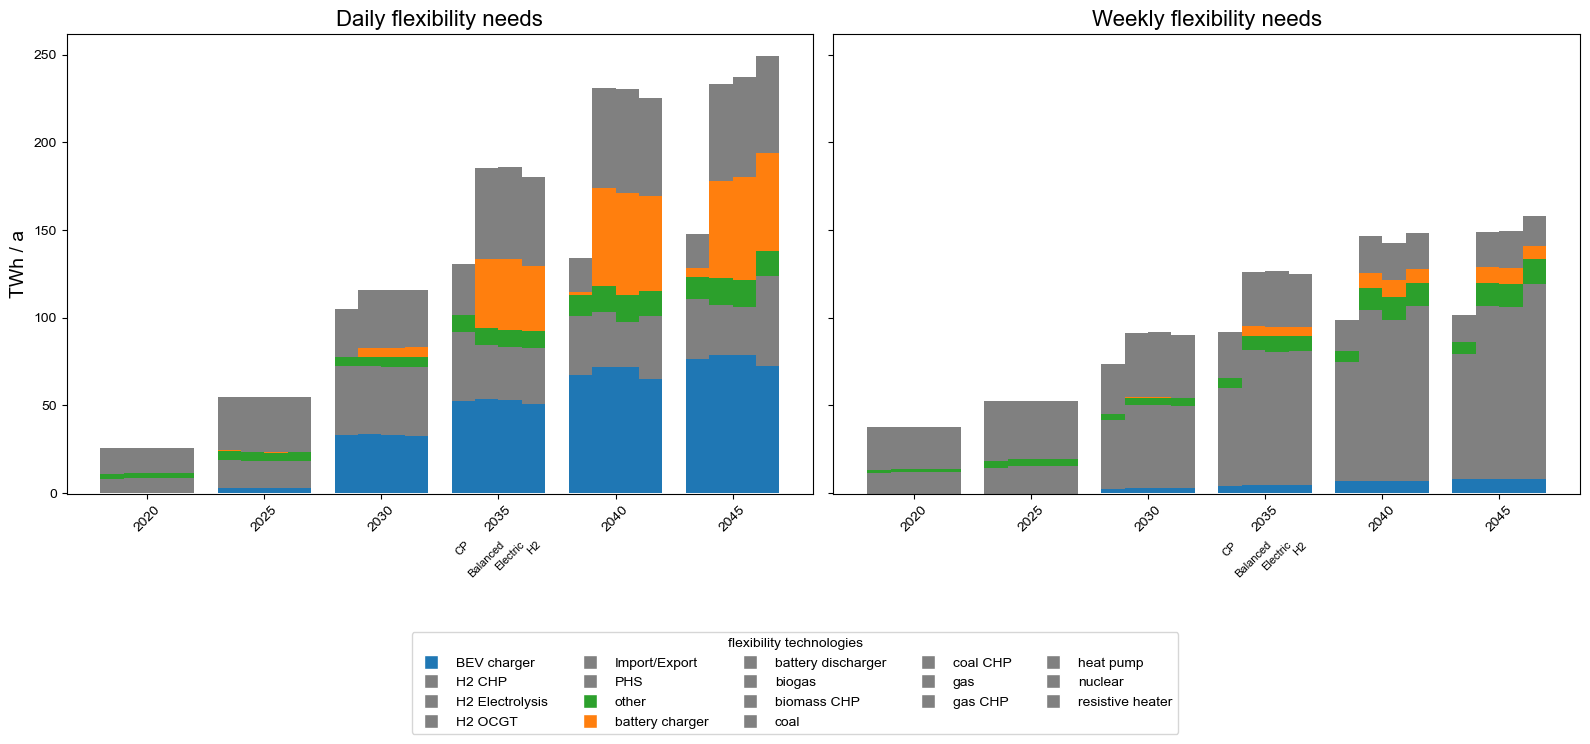

In [ ]:
import numpy as np
import pandas as pd

# Define scenarios configuration with display names
scenario_config = {
    'Current Policies': {
        'file_suffix': 'CurrentPolicies_2019',
        'display_name': 'CP'  # Short name for plots
    },
    'KN2045 Balanced': {
        'file_suffix': 'KN2045_Bal_v4_2019',
        'display_name': 'Balanced'
    },
    'KN2045 Electric': {
        'file_suffix': 'KN2045_Elec_v4_2019', 
        'display_name': 'Electric'
    },
    'KN2045 H2': {
        'file_suffix': 'KN2045_H2_v4_2019',
        'display_name': 'H2'
    }
}

# Base path for data files
base_path = "/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/"

# Load all scenarios automatically
scenarios = {}
for scenario_name, config in scenario_config.items():
    scenarios[scenario_name] = {
        'daily': pd.read_csv(f"{base_path}flex_contribution_d_{config['file_suffix']}.csv", index_col=0),
        'weekly': pd.read_csv(f"{base_path}flex_contribution_w_{config['file_suffix']}.csv", index_col=0),
        'display_name': config['display_name']
    }

# Set up the subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Function to plot multiple scenarios as grouped bars
def plot_scenarios(ax_subplot, data_dict, title):
    # Get all years from the first scenario
    years = data_dict[list(scenarios.keys())[0]].columns
    
    # Set up positions for grouped bars
    n_scenarios = len(scenarios)
    n_years = len(years)
    bar_width = 0.8 / n_scenarios
    x_positions = np.arange(n_years)
    
    # Get all unique technologies across all scenarios for this plot type
    all_technologies = set()
    for scenario_name in scenarios.keys():
        if scenario_name in data_dict and not data_dict[scenario_name].empty:
            all_technologies.update(data_dict[scenario_name].index)
    all_technologies = sorted(all_technologies)
    
    # Debug: print technologies found and check colors
    print(f"Technologies found for {title}: {all_technologies}")
    missing_colors = [tech for tech in all_technologies if tech not in tech_colors]
    if missing_colors:
        print(f"Technologies missing colors: {missing_colors}")
    
    # Plot each scenario
    for i, (scenario_name, df) in enumerate(data_dict.items()):
        # Calculate x positions for this scenario
        x_pos = x_positions + (i - n_scenarios/2 + 0.5) * bar_width
        
        # Prepare data for stacking
        bottom = np.zeros(len(years))
        
        # Plot each technology as part of the stack
        for tech in all_technologies:
            if tech in df.index:
                values = df.loc[tech].values
                # Handle NaN values by replacing with 0
                values = np.nan_to_num(values, nan=0.0)
            else:
                # If technology doesn't exist in this scenario, use zeros
                values = np.zeros(len(years))
            
            color = tech_colors.get(tech, 'gray')
            # Only plot if there are non-zero values
            if np.any(values != 0):
                ax_subplot.bar(x_pos, values, bar_width, bottom=bottom, 
                             color=color, label=tech if i == 0 else "")
            bottom += values
    
    # Customize the subplot
    ax_subplot.set_title(title, fontsize=16)
    ax_subplot.set_xticks(x_positions)
    ax_subplot.set_xticklabels(years, rotation=45)
    
    # Add scenario labels below x-axis
    for i, scenario_name in enumerate(scenarios.keys()):
        display_name = scenarios[scenario_name]['display_name']
        x_pos = x_positions + (i - n_scenarios/2 + 0.5) * bar_width
        for j, x in enumerate(x_pos):
            if j == len(x_pos) // 2:  # Only label in the middle
                ax_subplot.text(x, ax_subplot.get_ylim()[0] - (ax_subplot.get_ylim()[1] - ax_subplot.get_ylim()[0]) * 0.1, 
                              display_name, ha='center', va='top', fontsize=8, rotation=45)

# Create data dictionaries for daily and weekly
daily_data = {name: info['daily'] for name, info in scenarios.items()}
weekly_data = {name: info['weekly'] for name, info in scenarios.items()}

# Plot daily flexibility needs
plot_scenarios(ax[0], daily_data, "Daily flexibility needs")
ax[0].set_ylabel("TWh / a", fontsize=14)

# Plot weekly flexibility needs  
plot_scenarios(ax[1], weekly_data, "Weekly flexibility needs")

# Get all unique technologies for legend
all_technologies_legend = set()
for scenario_info in scenarios.values():
    all_technologies_legend.update(scenario_info['daily'].index)
    all_technologies_legend.update(scenario_info['weekly'].index)
all_technologies_legend = sorted(all_technologies_legend)

# Create the legend handles and labels for all distinct technologies
handles, labels = [], []
for tech in all_technologies_legend:
    handles.append(plt.Line2D([0], [0], marker='s', color='w', 
                            markerfacecolor=tech_colors.get(tech, 'gray'), markersize=10))
    labels.append(tech if tech != "Sonstige" else "other")

# Place the legend below both subplots
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    title="flexibility technologies"
)

# Tighten layout to ensure everything fits
plt.tight_layout()

# Save the combined plot
plt.savefig(PLOT_DIR + "/flexibility_needs_scenarios_combined_english", bbox_inches='tight')

# Show the plot
plt.show()

Technologies found for Daily flexibility needs: ['BEV charger', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'Sonstige', 'battery charger', 'battery discharger', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']
Technologies missing colors: ['H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'battery discharger', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']
Technologies found for Weekly flexibility needs: ['BEV charger', 'H2 CHP', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'Sonstige', 'battery charger', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']
Technologies missing colors: ['H2 CHP', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'biogas', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']


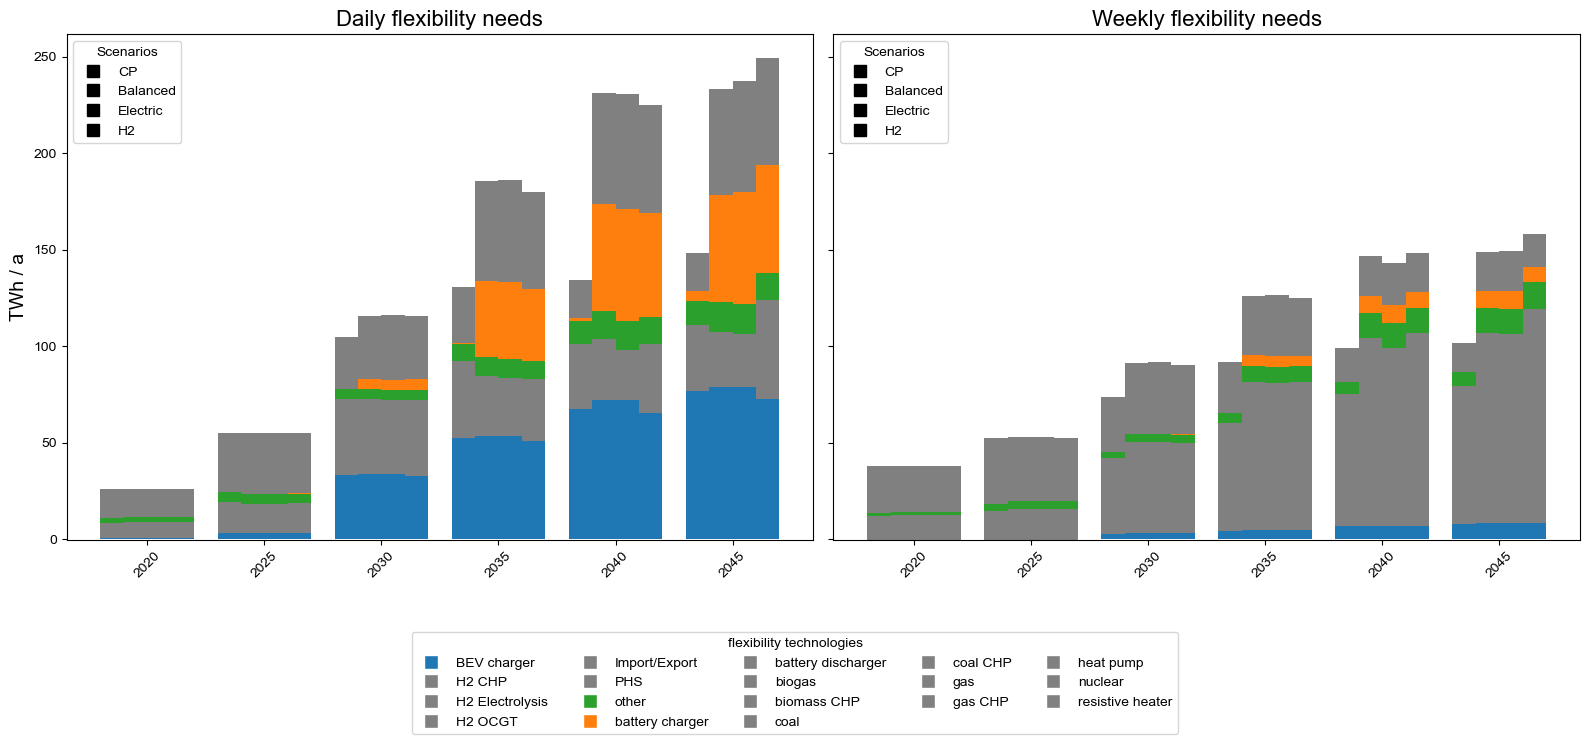

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define scenarios configuration with display names
scenario_config = {
    'Current Policies': {
        'file_suffix': 'CurrentPolicies_2019',
        'display_name': 'CP'  # Short name for plots
    },
    'KN2045 Balanced': {
        'file_suffix': 'KN2045_Bal_v4_2019',
        'display_name': 'Balanced'
    },
    'KN2045 Electric': {
        'file_suffix': 'KN2045_Elec_v4_2019', 
        'display_name': 'Electric'
    },
    'KN2045 H2': {
        'file_suffix': 'KN2045_H2_v4_2019',
        'display_name': 'H2'
    }
}

# Base path for data files
base_path = "/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/"

# Example tech_colors dictionary (replace with your actual colors)
tech_colors = {
    # Example tech colors (replace with your own)
    'BEV charger': '#1f77b4',
    'battery charger': '#ff7f0e',
    'Sonstige': '#2ca02c',
    # Add all your techs here with colors...
}

# Load all scenarios automatically
scenarios = {}
for scenario_name, config in scenario_config.items():
    scenarios[scenario_name] = {
        'daily': pd.read_csv(f"{base_path}flex_contribution_d_{config['file_suffix']}.csv", index_col=0),
        'weekly': pd.read_csv(f"{base_path}flex_contribution_w_{config['file_suffix']}.csv", index_col=0),
        'display_name': config['display_name']
    }

# Set up the subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Function to plot multiple scenarios as grouped stacked bars
def plot_scenarios(ax_subplot, data_dict, title):
    # Get all years from the first scenario
    years = data_dict[list(data_dict.keys())[0]].columns
    
    # Set up positions for grouped bars
    n_scenarios = len(data_dict)
    n_years = len(years)
    bar_width = 0.8 / n_scenarios
    x_positions = np.arange(n_years)
    
    # Get all unique technologies across all scenarios for this plot type
    all_technologies = set()
    for scenario_name in data_dict.keys():
        if not data_dict[scenario_name].empty:
            all_technologies.update(data_dict[scenario_name].index)
    all_technologies = sorted(all_technologies)
    
    # Debug: print technologies found and check colors
    print(f"Technologies found for {title}: {all_technologies}")
    missing_colors = [tech for tech in all_technologies if tech not in tech_colors]
    if missing_colors:
        print(f"Technologies missing colors: {missing_colors}")
    
    # Plot each scenario
    for i, (scenario_name, df) in enumerate(data_dict.items()):
        # Calculate x positions for this scenario
        x_pos = x_positions + (i - n_scenarios/2 + 0.5) * bar_width
        
        # Prepare data for stacking
        bottom = np.zeros(len(years))
        
        # Plot each technology as part of the stack
        for tech in all_technologies:
            if tech in df.index:
                values = df.loc[tech].values
                # Handle NaN values by replacing with 0
                values = np.nan_to_num(values, nan=0.0)
            else:
                # If technology doesn't exist in this scenario, use zeros
                values = np.zeros(len(years))
            
            color = tech_colors.get(tech, 'gray')
            # Only plot if there are non-zero values
            if np.any(values != 0):
                ax_subplot.bar(x_pos, values, bar_width, bottom=bottom, 
                             color=color, label=tech if i == 0 else "")
            bottom += values
    
    # Customize the subplot
    ax_subplot.set_title(title, fontsize=16)
    ax_subplot.set_xticks(x_positions)
    ax_subplot.set_xticklabels(years, rotation=45)
    
    # Add scenario legend in upper left with black square markers (does NOT affect bar colors)
    scenario_handles = []
    for scenario_name in data_dict.keys():
        display_name = scenarios[scenario_name]['display_name']
        handle = plt.Line2D([0], [0], color='black', marker='s', linestyle='', markersize=8, label=display_name)
        scenario_handles.append(handle)
    ax_subplot.legend(handles=scenario_handles, title="Scenarios", loc="upper left")

# Create data dictionaries for daily and weekly
daily_data = {name: info['daily'] for name, info in scenarios.items()}
weekly_data = {name: info['weekly'] for name, info in scenarios.items()}

# Plot daily flexibility needs
plot_scenarios(ax[0], daily_data, "Daily flexibility needs")
ax[0].set_ylabel("TWh / a", fontsize=14)

# Plot weekly flexibility needs  
plot_scenarios(ax[1], weekly_data, "Weekly flexibility needs")

# Get all unique technologies for legend
all_technologies_legend = set()
for scenario_info in scenarios.values():
    all_technologies_legend.update(scenario_info['daily'].index)
    all_technologies_legend.update(scenario_info['weekly'].index)
all_technologies_legend = sorted(all_technologies_legend)

# Create the legend handles and labels for all distinct technologies
handles, labels = [], []
for tech in all_technologies_legend:
    handles.append(plt.Line2D([0], [0], marker='s', color='w', 
                            markerfacecolor=tech_colors.get(tech, 'gray'), markersize=10))
    labels.append(tech if tech != "Sonstige" else "other")

# Place the legend below both subplots
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    title="flexibility technologies"
)

# Tighten layout to ensure everything fits
plt.tight_layout()

# Define PLOT_DIR (adjust as needed)
PLOT_DIR = "/home/julian-geis/repos/01_pricing-paper/pricing_analysis/plots"

# Save the combined plot
plt.savefig(f"{PLOT_DIR}/flexibility_needs_scenarios_combined_english.png", bbox_inches='tight')

# Show the plot
plt.show()


Technologies found for Daily flexibility needs: ['BEV charger', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'Sonstige', 'battery charger', 'battery discharger', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'hydro', 'nuclear', 'resistive heater']
Technologies found for Weekly flexibility needs: ['BEV charger', 'H2 Electrolysis', 'H2 OCGT', 'Import/Export', 'PHS', 'Sonstige', 'battery charger', 'battery discharger', 'biomass CHP', 'coal', 'coal CHP', 'gas', 'gas CHP', 'heat pump', 'nuclear', 'resistive heater']


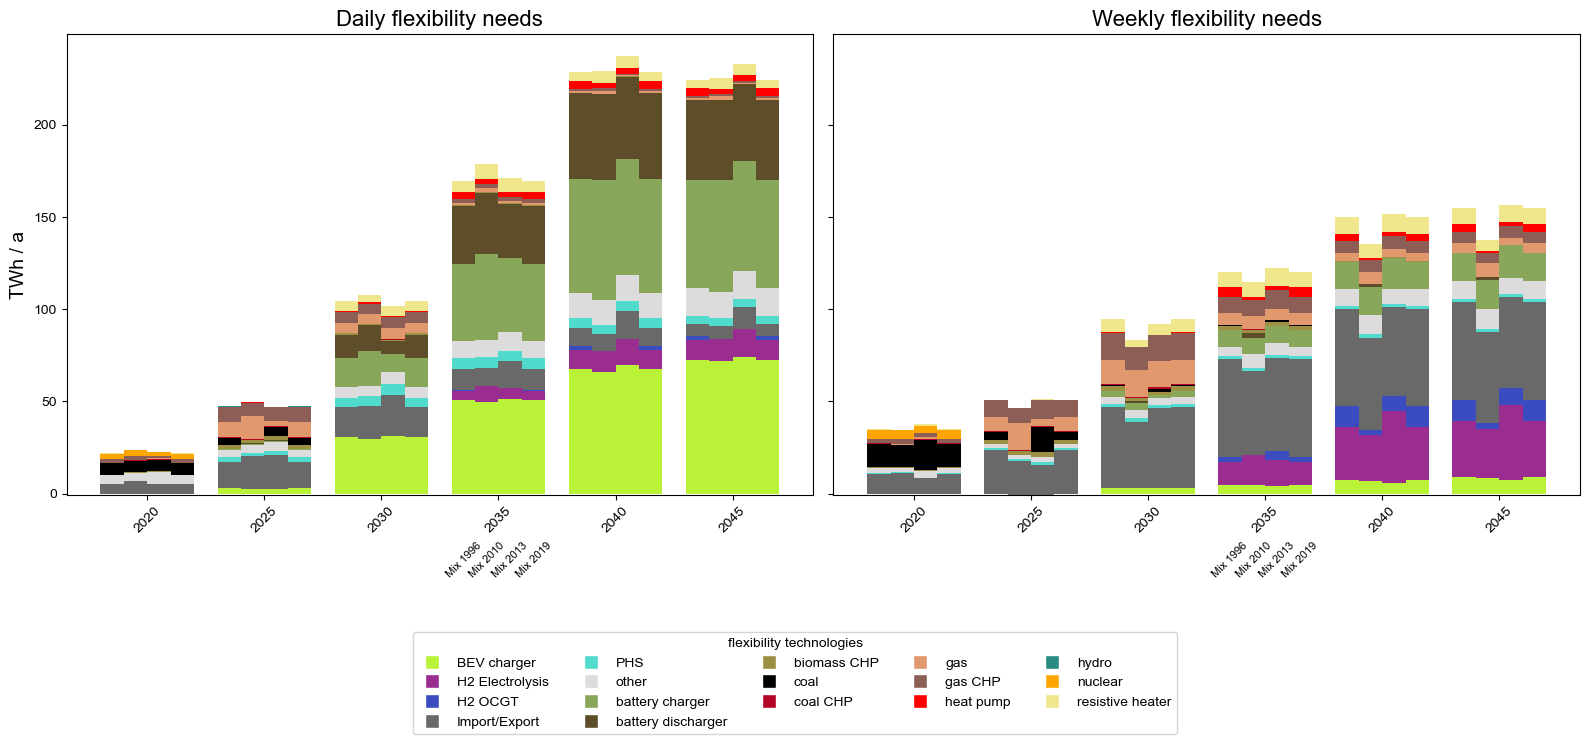

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dictionary to store all dataframes
scenarios = {
    'Mix 1996': {
        'daily': fc_mix_1996_d,
        'weekly': fc_mix_1996_w
    },
    'Mix 2010': {
        'daily': fc_mix_2010_d,
        'weekly': fc_mix_2010_w
    },
    'Mix 2013': {
        'daily': fc_mix_2013_d,
        'weekly': fc_mix_2013_w
    },
    'Mix 2019': {
        'daily': fc_mix_1996_d,
        'weekly': fc_mix_1996_w
    }
}

# Set up the subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Function to plot multiple scenarios as grouped bars
def plot_scenarios(ax_subplot, data_dict, title):
    # Get all years from the first scenario
    years = data_dict[list(scenarios.keys())[0]].columns
    
    # Set up positions for grouped bars
    n_scenarios = len(scenarios)
    n_years = len(years)
    bar_width = 0.8 / n_scenarios
    x_positions = np.arange(n_years)
    
    # Get all unique technologies across all scenarios for this plot type
    all_technologies = set()
    for scenario_name in scenarios.keys():
        if scenario_name in data_dict and not data_dict[scenario_name].empty:
            all_technologies.update(data_dict[scenario_name].index)
    all_technologies = sorted(all_technologies)
    
    # Debug: print technologies found
    print(f"Technologies found for {title}: {all_technologies}")
    
    # Plot each scenario
    for i, (scenario_name, df) in enumerate(data_dict.items()):
        # Calculate x positions for this scenario
        x_pos = x_positions + (i - n_scenarios/2 + 0.5) * bar_width
        
        # Prepare data for stacking
        bottom = np.zeros(len(years))
        
        # Plot each technology as part of the stack
        for tech in all_technologies:
            if tech in df.index:
                values = df.loc[tech].values
                # Handle NaN values by replacing with 0
                values = np.nan_to_num(values, nan=0.0)
            else:
                # If technology doesn't exist in this scenario, use zeros
                values = np.zeros(len(years))
            
            color = tech_colors.get(tech, 'gray')
            
            # Only plot if there are non-zero values
            if np.any(values != 0):
                ax_subplot.bar(x_pos, values, bar_width, bottom=bottom,
                             color=color, label=tech if i == 0 else "")
            
            bottom += values
    
    # Customize the subplot
    ax_subplot.set_title(title, fontsize=16)
    ax_subplot.set_xticks(x_positions)
    ax_subplot.set_xticklabels(years, rotation=45)
    
    # Add scenario labels below x-axis
    scenario_labels = list(scenarios.keys())
    for i, scenario in enumerate(scenario_labels):
        x_pos = x_positions + (i - n_scenarios/2 + 0.5) * bar_width
        for j, x in enumerate(x_pos):
            if j == len(x_pos) // 2:  # Only label in the middle
                ax_subplot.text(x, ax_subplot.get_ylim()[0] - (ax_subplot.get_ylim()[1] - ax_subplot.get_ylim()[0]) * 0.1,
                              scenario, ha='center', va='top', fontsize=8, rotation=45)

# Create data dictionaries for daily and weekly
daily_data = {name: info['daily'] for name, info in scenarios.items()}
weekly_data = {name: info['weekly'] for name, info in scenarios.items()}

# Plot daily flexibility needs
plot_scenarios(ax[0], daily_data, "Daily flexibility needs")
ax[0].set_ylabel("TWh / a", fontsize=14)

# Plot weekly flexibility needs
plot_scenarios(ax[1], weekly_data, "Weekly flexibility needs")

# Get all unique technologies for legend
all_technologies = set()
for scenario_info in scenarios.values():
    all_technologies.update(scenario_info['daily'].index)
    all_technologies.update(scenario_info['weekly'].index)
all_technologies = sorted(all_technologies)

# Create the legend handles and labels for all distinct technologies
handles, labels = [], []
for tech in all_technologies:
    if tech in tech_colors:
        handles.append(plt.Line2D([0], [0], marker='s', color='w',
                                markerfacecolor=tech_colors[tech], markersize=10))
        labels.append(tech if tech != "Sonstige" else "other")

# Place the legend below both subplots
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    title="flexibility technologies"
)

# Tighten layout to ensure everything fits
plt.tight_layout()

# Save the combined plot
plt.savefig(PLOT_DIR + "/flexibility_needs_weather_years_combined_english", bbox_inches='tight')

# Show the plot
plt.show()

#### Cumulative

In [ ]:
df_all_cum_w = pd.DataFrame()

for year in np.arange(2020, 2050, 5):
    df = result_cumulative[year].dropna().diff() * -1
    df_all_cum_w = pd.concat([df_all_cum_w,df], axis=1)

df_all_cum_w

,2020,2025,2030,2035,2040,2045
no,NaN,NaN,NaN,NaN,NaN,NaN
import,2.79,7.15,14.9,22.59,25.95,30.86
coal,11.95,0.05,0.02,0.25,NaN,NaN
gas,0.18,15.0,14.52,7.33,6.39,7.57
oil,-0.0,-0.0,-0.0,0.01,0.01,0.03
nuclear,4.63,NaN,NaN,NaN,NaN,NaN
solid biomass,0.01,-0.0,-0.0,-0.0,NaN,NaN
PHS discharging,0.08,0.04,-0.16,0.15,0.05,0.07
battery discharger,-0.0,-0.08,1.0,3.2,2.17,2.63
coal CHP,0.26,0.74,0.52,0.25,0.07,NaN


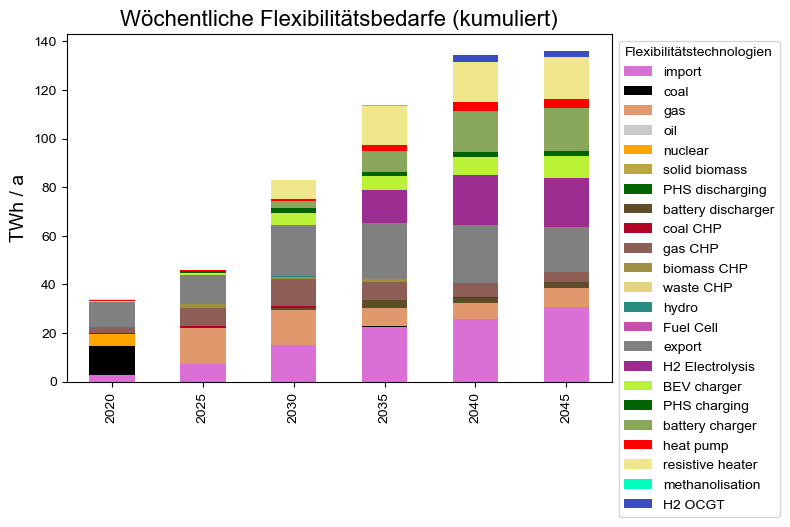

In [ ]:
df = df_all_cum_w.drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Wöchentliche Flexibilitätsbedarfe (kumuliert)", fontsize=16)
ax.set_ylabel("TWh / a", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

plt.savefig(PLOT_DIR+"/weekly_flex_cumulative")

### Annual

In [ ]:
years = np.arange(2020, 2050, 5)

result_single = pd.DataFrame(index=all_flex_techs, columns=years)
result_cumulative = pd.DataFrame(index=all_flex_techs, columns=years)

for year in years:
    n = networks[year]
    
    for cumulative in [True, False]:

        if cumulative:
            electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)
        else:
            electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)

        non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index

        vre_gen = electricity_supply.loc[vre_gens].sum()
        load = electricity_demand.loc[load_carriers].sum()
        
        residual_load = load - vre_gen

        for flex_tech in all_flex_techs:
            
            # 1. Calculate initial residual load
            if flex_tech == "no":
                sub = 0
            elif flex_tech in flex_techs_supply.keys():
                count = sum(item in electricity_supply.index for item in flex_techs_supply[flex_tech]) # how many of the techs are present
                techs = [item for item in flex_techs_supply[flex_tech] if item in electricity_supply.index] # which techs are present
                if count > 1:
                    sub = electricity_supply.loc[techs].sum()
                elif count == 1:
                    sub = electricity_supply.loc[techs[0]]
                else:
                    print(f"Flex tech {flex_tech} not in electricity supply for year {year}")
                    continue
            elif flex_tech in flex_techs_demand.keys():
                count = sum(item in electricity_demand.index for item in flex_techs_demand[flex_tech])
                techs = [item for item in flex_techs_demand[flex_tech] if item in electricity_demand.index]
                if count > 1:
                    sub = electricity_demand.loc[techs].sum() * -1
                elif count == 1:
                    sub = electricity_demand.loc[techs[0]] * -1
                else:
                    print(f"Flex tech {flex_tech} not in electricity demand for year {year}")
                    continue
            else:
                print(f"Flex tech {flex_tech} not in any flex tech list")
                continue

            if cumulative:
                residual_load = residual_load - sub
            else:
                residual_load = load - vre_gen - sub

            # Compute daily average of residual load
            daily_average_residual = residual_load.resample('D').mean()

            # Expand daily averages to hourly resolution for comparison
            daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='bfill')

            # Compute weekly average of daily averages
            weekly_average_residual = daily_average_residual.resample('W').mean()
            weekly_average_hourly = weekly_average_residual.reindex(residual_load.index, method='bfill')

            # Compute monthly average of weekly averages
            monthly_average_residual = weekly_average_residual.resample('ME').mean()
            monthly_average_hourly = monthly_average_residual.reindex(residual_load.index, method='bfill')

            # Compute yearly average of monthly averages
            yearly_average_residual = monthly_average_residual.resample('YE').mean()
            yearly_average_hourly = yearly_average_residual.reindex(residual_load.index, method='bfill')

            # Compute the difference between monthly average and yearly (only the positive part)
            yearly_flexibility_needs = (monthly_average_hourly - yearly_average_hourly).clip(lower=0)

            # Calculate weekly flexibility needs 
            yearly_flexibility_needs = yearly_flexibility_needs.resample('D').sum()

            # Calculate total weekly flexibility needs for one year (TWh/a)
            total_annual_flexibility = yearly_flexibility_needs.sum()

            if cumulative:
                result_cumulative.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2)
            else: 
                result_single.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2) 

584.90210727387
584.90210727387
Flex tech interconnectors supply not in electricity supply for year 2020
Flex tech biogas not in electricity supply for year 2020
Flex tech H2 OCGT not in electricity supply for year 2020
Flex tech H2 CHP not in electricity supply for year 2020
Flex tech interconnectors demand not in electricity demand for year 2020
584.90210727387
584.90210727387
Flex tech interconnectors supply not in electricity supply for year 2020
Flex tech biogas not in electricity supply for year 2020
Flex tech H2 OCGT not in electricity supply for year 2020
Flex tech H2 CHP not in electricity supply for year 2020
Flex tech interconnectors demand not in electricity demand for year 2020
620.1674603276399
620.1674603276399
Flex tech interconnectors supply not in electricity supply for year 2025
Flex tech biogas not in electricity supply for year 2025
Flex tech nuclear not in electricity supply for year 2025
Flex tech H2 OCGT not in electricity supply for year 2025
Flex tech H2 CHP n

#### Single

In [ ]:
df_all_single_a = pd.DataFrame()

for year in np.arange(2020, 2050, 5):
    df = result_single[year]
    no_total_i = df.drop("no").index
    # calc flexibility contribution 
    df[no_total_i] = -(result_single[year] - result_single[year].loc["no"])[no_total_i]
    df_all_single_a = pd.concat([df_all_single_a,df], axis=1)

df_all_single_a

,2020,2025,2030,2035,2040,2045
no,8.11,16.35,34.03,51.91,65.76,66.12
interconnectors supply,NaN,NaN,NaN,NaN,NaN,NaN
import,0.11,-4.99,-4.77,17.89,23.43,24.97
coal,2.1,0.05,0.01,0.13,NaN,NaN
gas,-0.05,7.83,17.1,8.02,7.61,11.48
biogas,NaN,NaN,NaN,NaN,NaN,NaN
oil,-0.0,-0.0,-0.0,-0.0,0.01,0.02
nuclear,0.81,NaN,NaN,NaN,NaN,NaN
solid biomass,-0.0,-0.0,-0.0,-0.0,NaN,NaN
PHS discharging,0.05,-0.16,-0.88,-0.99,-0.89,-0.66


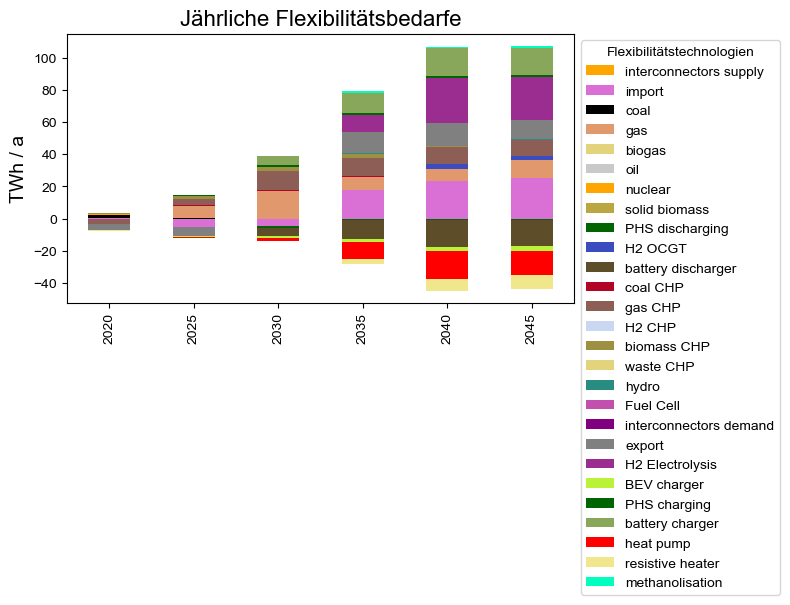

In [ ]:
df = df_all_single_a.drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Jährliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh / a", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# nice plot
df_single_overall_light_a = df_all_single_a.copy()
df_single_overall_light_a.loc["Import/Export"] = df_single_overall_light_a.loc[["import", "export"]].sum()
df_single_overall_light_a.loc["PHS"] = df_single_overall_light_a.loc[["PHS charging", "PHS discharging"]].sum()
df_single_overall_light_a = df_single_overall_light_a.drop(["import", "export", "interconnectors supply", "interconnectors demand", "PHS charging", "PHS discharging"])

# drop rows which have less than 1 % of the total flexibility needs in all years
shares = df_single_overall_light_a / df_single_overall_light_a.drop("no").sum() 
techs = shares[shares > 0.01].dropna(how="all").index 
df_single_overall_light_a = df_single_overall_light_a.loc[techs]
sorted_techs = df_single_overall_light_a.sum(axis=1).sort_values(ascending=False).index
df_single_overall_light_a = df_single_overall_light_a.loc[sorted_techs]
df_single_overall_light_a.loc["Sonstige"] = df_single_overall_light_a.loc["no"] - df_single_overall_light_a.drop("no").sum() 
df_single_overall_light_a = df_single_overall_light_a.drop("no")

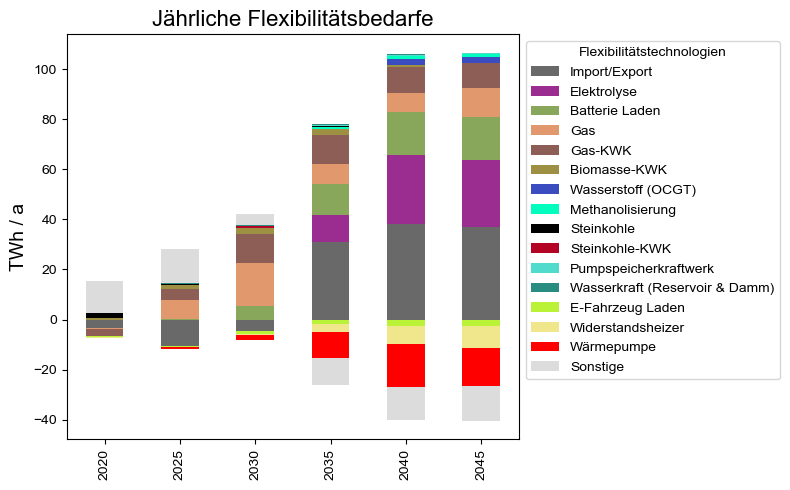

In [ ]:
df = (df_single_overall_light_a)

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  
# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Jährliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh / a", fontsize=14)

# Move the legend outside the plot
ax.legend(
    labels = [carriers_in_german.get(l, l) for l in df.index],
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

plt.savefig(PLOT_DIR+"/annual_flex_single_nice")

#### Cumulative

In [ ]:
df_all_cum_a = pd.DataFrame()

for year in np.arange(2020, 2050, 5):
    df = result_cumulative[year].dropna().diff() * -1
    df_all_cum_a = pd.concat([df_all_cum_a,df], axis=1)

df_all_cum_a

,2020,2025,2030,2035,2040,2045
no,NaN,NaN,NaN,NaN,NaN,NaN
import,0.11,-4.99,-4.77,17.89,23.43,24.97
coal,3.78,0.06,0.01,0.13,NaN,NaN
gas,0.08,12.58,23.63,6.68,6.64,8.72
oil,-0.0,-0.0,-0.0,0.01,0.01,0.02
nuclear,0.64,NaN,NaN,NaN,NaN,NaN
solid biomass,-0.0,-0.0,-0.0,-0.0,NaN,NaN
PHS discharging,-0.07,-0.24,-0.88,-0.8,-0.71,-0.22
battery discharger,-0.0,-0.15,-5.42,-10.67,-15.59,-13.08
coal CHP,-0.43,0.37,0.78,0.28,0.14,NaN


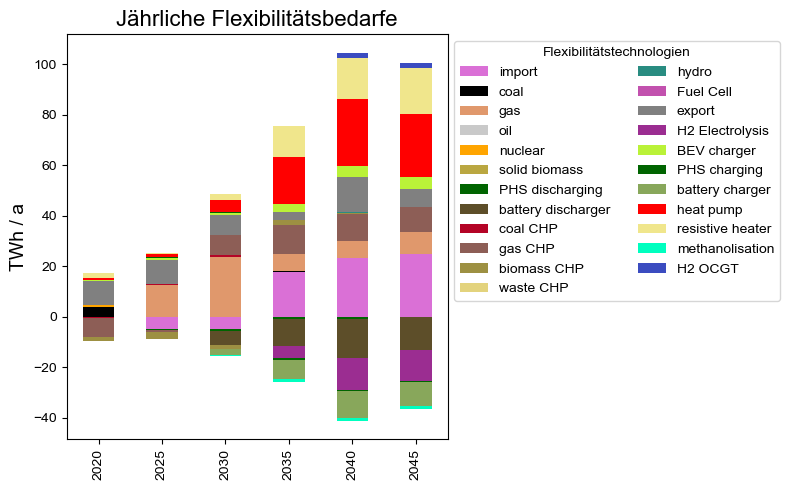

In [ ]:
df = df_all_cum_a.drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Jährliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh / a", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien",
    ncol=2,
)

# Tighten the layout to fit everything
plt.tight_layout()

plt.savefig(PLOT_DIR+"/annual_flex_cumulative")

### Flexibility needs overall

In [ ]:
# Stromproduktion in 2045
s,d = supply_demand(networks[2045], interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, add_diff_as_import=True)
s.drop("import", errors="ignore").sum().sum() / 1e6

1396.32002411892
1396.32002411892


1249.34655707895

In [ ]:
240 / (s.drop("import", errors="ignore").sum().sum() / 1e6)

0.1921004213283582

In [ ]:
flex_needs = pd.DataFrame()
flex_needs["daily"] = df_all_single_d.loc["no"]
flex_needs["weekly"] = df_all_single_w.loc["no"]
flex_needs["annual"] = df_all_single_a.loc["no"]
flex_needs

,daily,weekly,annual
2020,23.59,34.46,8.11
2025,49.85,46.31,16.35
2030,107.82,83.44,34.03
2035,178.44,114.95,51.91
2040,229.14,135.41,65.76
2045,225.05,137.4,66.12


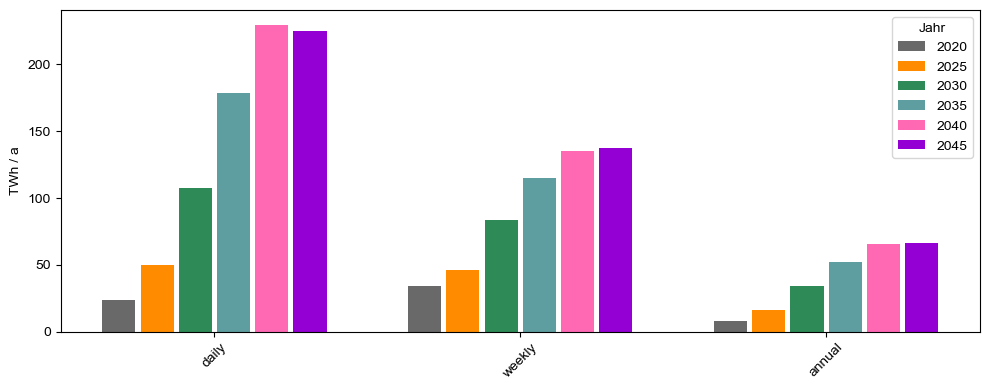

In [ ]:
# Transpose the DataFrame
flex_needs_t = flex_needs.transpose()

# Adjusting for spacing
bar_width = 0.13  # Width of each bar
inner_spacing = 0.02  # Small gap between bars within each category
group_spacing = 0.2  # Larger gap between categories

# Plotting
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(flex_needs_t))

# Create bars for each year
for i, year in enumerate(flex_needs_t.columns):
    ax.bar(
        [p + i * (bar_width + inner_spacing) + p * group_spacing for p in x],
        flex_needs_t[year],
        width=bar_width,
        label=year,
        color=year_colors[year]
    )

# Configure plot
ax.set_xticks([p + (len(flex_needs_t.columns) - 1) * (bar_width + inner_spacing) / 2 + p * group_spacing for p in x])
ax.set_xticklabels(flex_needs_t.index, rotation=45)
ax.set_ylabel("TWh / a")
ax.legend(title="Jahr")

plt.tight_layout()
plt.savefig(PLOT_DIR+"/flex_needs_overall")

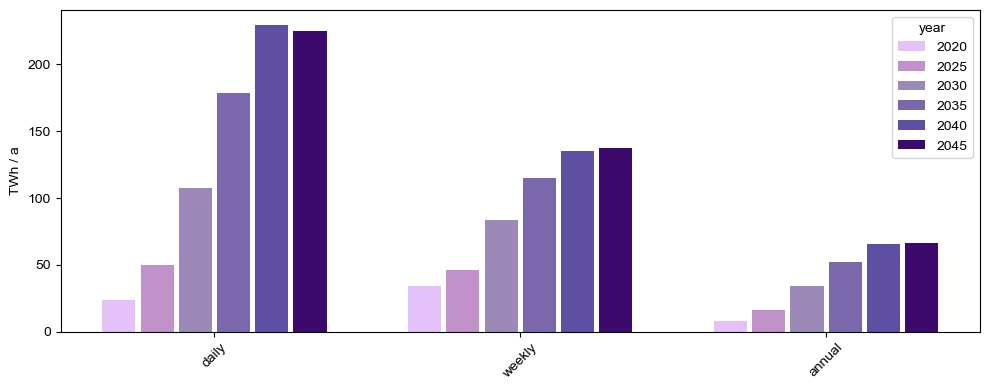

In [ ]:
year_colors_gradient = {
    2020: "#e4c1f9",  # Pale Lavender
    2025: "#c191c9",  # Soft Lilac
    2030: "#9c89b8",  # Lavender Purple
    2035: "#7b68ac",  # Muted Purple
    2040: "#5e4fa2",  # Deep Violet
    2045: "#3c096c",  # Intense Purple
}

# Transpose the DataFrame
flex_needs_t = flex_needs.transpose()

# Adjusting for spacing
bar_width = 0.13  # Width of each bar
inner_spacing = 0.02  # Small gap between bars within each category
group_spacing = 0.2  # Larger gap between categories

# Plotting
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(flex_needs_t))

# Create bars for each year
for i, year in enumerate(flex_needs_t.columns):
    ax.bar(
        [p + i * (bar_width + inner_spacing) + p * group_spacing for p in x],
        flex_needs_t[year],
        width=bar_width,
        label=year,
        color=year_colors_gradient[year]
    )

# Configure plot
ax.set_xticks([p + (len(flex_needs_t.columns) - 1) * (bar_width + inner_spacing) / 2 + p * group_spacing for p in x])
ax.set_xticklabels(flex_needs_t.index, rotation=45)
ax.set_ylabel("TWh / a")
ax.legend(title="year")

plt.tight_layout()
plt.savefig(PLOT_DIR + "/flex_needs_overall_gradient_english")
plt.show()


In [ ]:
year_colors_gradient = {
    2020: "#e4c1f9",  # Pale Lavender
    2025: "#c191c9",  # Soft Lilac
    2030: "#9c89b8",  # Lavender Purple
    2035: "#7b68ac",  # Muted Purple
    2040: "#5e4fa2",  # Deep Violet
    2045: "#3c096c",  # Intense Purple
}

# Transpose the DataFrame
flex_needs_t = flex_needs.transpose()

# Adjusting for spacing
bar_width = 0.13  # Width of each bar
inner_spacing = 0.02  # Small gap between bars within each category
group_spacing = 0.2  # Larger gap between categories

# Plotting
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(flex_needs_t))

# Create bars for each year
for i, year in enumerate(flex_needs_t.columns):
    ax.bar(
        [p + i * (bar_width + inner_spacing) + p * group_spacing for p in x],
        flex_needs_t[year],
        width=bar_width,
        label=year,
        color=year_colors_gradient[year]
    )

# Configure plot
ax.set_xticks([p + (len(flex_needs_t.columns) - 1) * (bar_width + inner_spacing) / 2 + p * group_spacing for p in x])
ax.set_xticklabels(flex_needs_t.index, rotation=45)
ax.set_ylabel("TWh / a")
ax.legend(title="year")

plt.tight_layout()
plt.savefig(PLOT_DIR + "/flex_needs_overall_gradient_english")
plt.show()


In [ ]:
fn_1996 = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_overall_Mix_1996.csv", index_col=0)
fn_2010 = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_overall_Mix_2010.csv", index_col=0)
fn_2013 = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_overall_Mix_2013.csv", index_col=0)
fn_2019 = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_overall_KN2045_Bal_v4_2019.csv", index_col=0)

In [ ]:
flex_needs_dict = {
    1996: fn_1996,
    2010: fn_2010,
    2013: fn_2013,
    2019: fn_2019
}


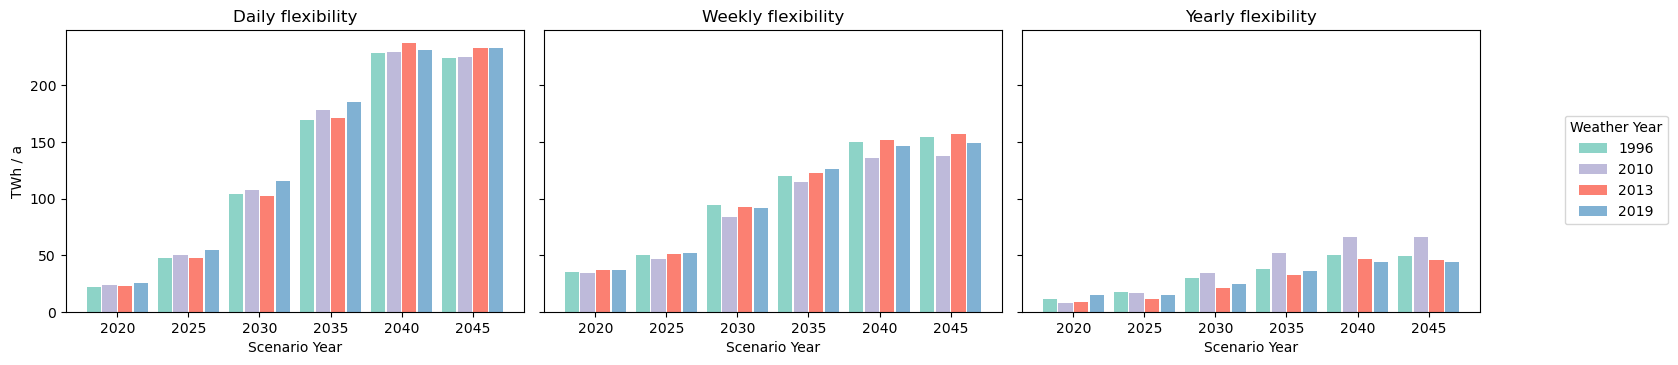

In [ ]:
# Color per weather year (distinct and colorblind-friendly)
weather_colors = {
    1996: "#8dd3c7",  # Soft teal
    2010: "#bebada",  # Soft purple
    2013: "#fb8072",  # Coral
    2019: "#80b1d3",  # Muted blue
}

# Translation of categories
category_labels = {
    "täglich": "daily",
    "wöchentlich": "weekly",
    "jährlich": "yearly"
}

# Input
scenario_years = [2020, 2025, 2030, 2035, 2040, 2045]
weather_years = list(flex_needs_dict.keys())
bar_width = 0.2
inner_spacing = 0.02

categories = list(category_labels.keys())  # ['täglich', 'wöchentlich', 'jährlich']

fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

x = np.arange(len(scenario_years))  # base x positions for scenario years

for ax, category in zip(axs, categories):
    for i, weather_year in enumerate(weather_years):
        offsets = x + i * (bar_width + inner_spacing)
        heights = [
            flex_needs_dict[weather_year].loc[year, category] if year in flex_needs_dict[weather_year].index else 0
            for year in scenario_years
        ]

        ax.bar(
            offsets,
            heights,
            width=bar_width,
            label=str(weather_year),
            color=weather_colors[weather_year]
        )

    # X-axis ticks centered
    middle_offset = ((len(weather_years) - 1) * (bar_width + inner_spacing)) / 2
    ax.set_xticks(x + middle_offset)
    ax.set_xticklabels(scenario_years)
    ax.set_title(f"{category_labels[category].capitalize()} flexibility")
    ax.set_xlabel("Scenario Year")

axs[0].set_ylabel("TWh / a")

# Shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    title="Weather Year",   # Legend title
    loc="center right",  # Position on the right center
    ncol=1,              # Single column
    bbox_to_anchor=(1.12, 0.5)  # Slightly outside right of the plot
)
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # room for legend
plt.savefig(f"/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_combined_weather_years.png", dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
fn_mix = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_overall_KN2045_Bal_v4_2019.csv", index_col=0)
fn_elec = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_overall_KN2045_Elec_v4_2019.csv", index_col=0)
fn_h2 = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_overall_KN2045_H2_v4_2019.csv", index_col=0)
fn_cp = pd.read_csv("/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_overall_CurrentPolicies_2019.csv", index_col=0)

In [ ]:
flex_needs_scenarios = {
    "KN2045_Bal_v4": fn_mix,
    "KN2045_Elec_v4": fn_elec,
    "KN2045_H2_v4": fn_h2,
    "CurrentPolicies": fn_cp
}

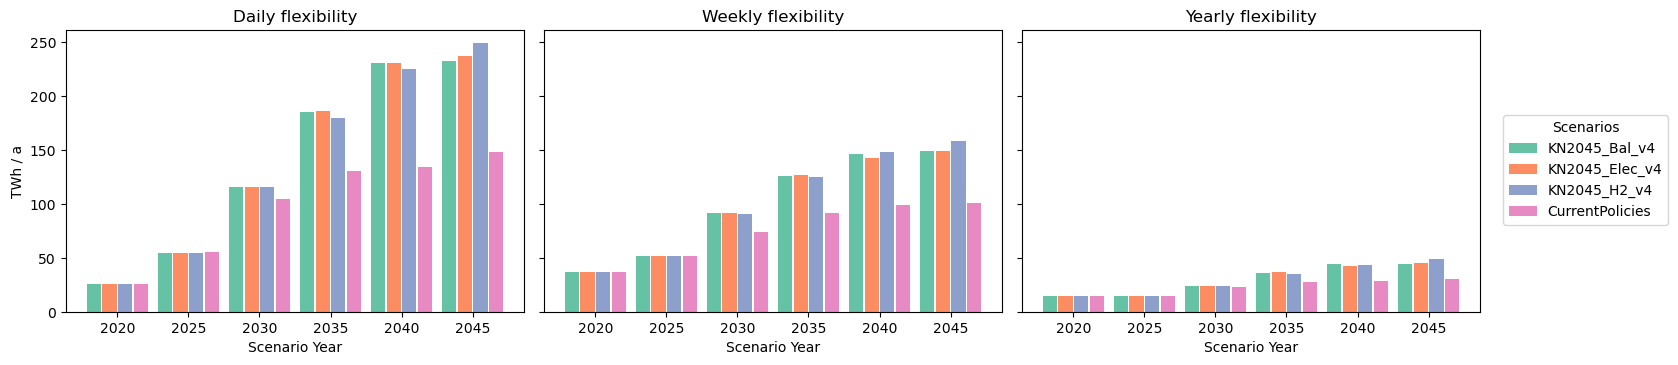

In [ ]:
scenario_colors = {
    "KN2045_Bal_v4": "#66c2a5",       # Teal (balanced)
    "KN2045_Elec_v4": "#fc8d62",      # Orange (electricity-focused)
    "KN2045_H2_v4": "#8da0cb",        # Lavender blue (hydrogen-focused)
    "CurrentPolicies": "#e78ac3"      # Soft pink (status quo)
}

# Translation of categories
category_labels = {
    "täglich": "daily",
    "wöchentlich": "weekly",
    "jährlich": "yearly"
}

# Configuration
scenario_years = [2020, 2025, 2030, 2035, 2040, 2045]
scenarios = list(flex_needs_scenarios.keys())
bar_width = 0.2
inner_spacing = 0.02

categories = list(category_labels.keys())

fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

x = np.arange(len(scenario_years))  # one per scenario year

for ax, category in zip(axs, categories):
    for i, scenario in enumerate(scenarios):
        offsets = x + i * (bar_width + inner_spacing)
        heights = [
            flex_needs_scenarios[scenario].loc[year, category] if year in flex_needs_scenarios[scenario].index else 0
            for year in scenario_years
        ]

        ax.bar(
            offsets,
            heights,
            width=bar_width,
            label=scenario,
            color=scenario_colors[scenario]
        )

    # Center xticks
    middle_offset = ((len(scenarios) - 1) * (bar_width + inner_spacing)) / 2
    ax.set_xticks(x + middle_offset)
    ax.set_xticklabels(scenario_years)
    ax.set_title(f"{category_labels[category].capitalize()} flexibility")
    ax.set_xlabel("Scenario Year")

axs[0].set_ylabel("TWh / a")

# Shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    title="Scenarios",   # Legend title
    loc="center right",  # Position on the right center
    ncol=1,              # Single column
    bbox_to_anchor=(1.12, 0.5)  # Slightly outside right of the plot
)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig(f"/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_by_scenario_subplots.png", dpi=300, bbox_inches='tight')
plt.show()


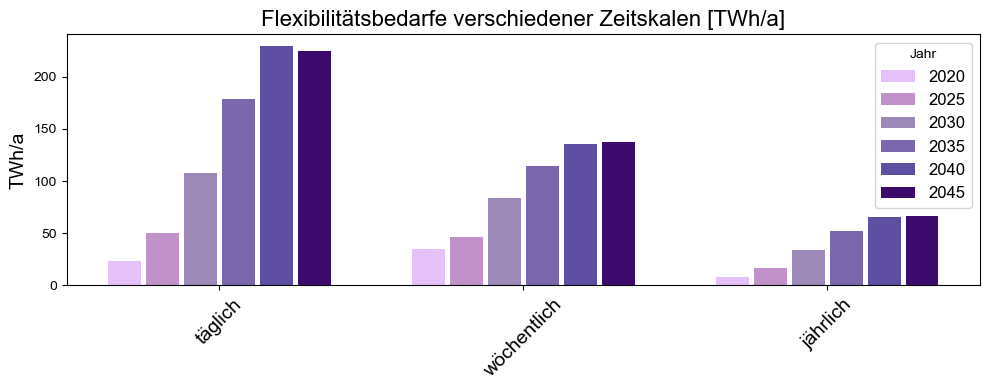

In [ ]:
year_colors_gradient = {
    2020: "#e4c1f9",  # Pale Lavender
    2025: "#c191c9",  # Soft Lilac
    2030: "#9c89b8",  # Lavender Purple
    2035: "#7b68ac",  # Muted Purple
    2040: "#5e4fa2",  # Deep Violet
    2045: "#3c096c",  # Intense Purple
}

# Transpose the DataFrame
flex_needs.columns = ["täglich", "wöchentlich", "jährlich"]
flex_needs_t = flex_needs.transpose()


# Adjusting for spacing
bar_width = 0.13  # Width of each bar
inner_spacing = 0.02  # Small gap between bars within each category
group_spacing = 0.2  # Larger gap between categories

# Plotting
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(flex_needs_t))

# Create bars for each year
for i, year in enumerate(flex_needs_t.columns):
    ax.bar(
        [p + i * (bar_width + inner_spacing) + p * group_spacing for p in x],
        flex_needs_t[year],
        width=bar_width,
        label=year,
        color=year_colors_gradient[year]
    )

# Configure plot
ax.set_xticks([p + (len(flex_needs_t.columns) - 1) * (bar_width + inner_spacing) / 2 + p * group_spacing for p in x])
ax.set_xticklabels(flex_needs_t.index, rotation=45, fontsize=14)
ax.set_title("Flexibilitätsbedarfe verschiedener Zeitskalen [TWh/a]", fontsize=16)
ax.set_ylabel("TWh/a", fontsize=14)
ax.legend(title="Jahr", fontsize=12)

plt.tight_layout()
plt.savefig(PLOT_DIR + "/flex_needs_overall_gradient.png")
plt.savefig(PLOT_DIR + "/flex_needs_overall_gradient.pdf")
plt.show()

# save df
flex_needs.to_csv(f"/home/julian-geis/repos/01_pricing-paper/pricing_analysis/data/results/flex_plots/flex_needs_overall_{scenario}_{weather_year}.csv")



In [ ]:
assert 0

AssertionError: 

In [ ]:
from ecmwfapi import ECMWFDataServer

server = ECMWFDataServer()

server.retrieve({
    "class": "ti",
    "dataset": "tigge",
    "date": "2019-01-01/to/2019-01-31",
    "expver": "prod",
    "grid": "0.5/0.5",
    "levtype": "sfc",
    "number": "1",
    "origin": "kwbc",
    "param": "166/177",
    "step": "0",
    "time": "00:00:00/06:00:00/12:00:00/18:00:00",
    "type": "pf",
    "target": "output"
})

2025-07-25 15:42:39 ECMWF API python library 1.6.5
2025-07-25 15:42:39 ECMWF API at https://api.ecmwf.int/v1
2025-07-25 15:42:39 Welcome Julian Geis
2025-07-25 15:42:40 In case of problems, please check https://confluence.ecmwf.int/display/WEBAPI/Web+API+FAQ or contact servicedesk@ecmwf.int
2025-07-25 15:42:40 ------------ WARNING ------------
2025-07-25 15:42:40 Access to this dataset is transitioning to a new interface, dates to be announced soon
2025-07-25 15:42:40 For more information on how to access this data in the future, visit https://confluence.ecmwf.int/x/-wUiEw
2025-07-25 15:42:40 ---------------------------------
2025-07-25 15:42:40 Request submitted
2025-07-25 15:42:40 Request id: 688389d08e2f771cfc14233e
2025-07-25 15:42:40 Request is submitted
2025-07-25 15:42:42 Calling 'nice mars /tmp/20250725-1340/2d/tmp-_mars-Z1eRqc-4582576502c5ebffd84a0030930ffe7e.req'
2025-07-25 15:42:42 Forcing MIR_CACHE_PATH=/data/ec_coeff
2025-07-25 15:42:42 mars - WARN -
2025-07-25 15:42:42 ma

KeyboardInterrupt: 

## Flexibility by supply and demand (not aggregated)

old problems:
- how would you see the flexibility contribution of a technology that does only shift between the buses (AC+DC) if you aggregate all buses?

new problems:
- how do you see the flexibility contribution of a technology to the overall DE residual load if you only see the residual load of the bus (OCGT plant providing electricity for another bus)


In [ ]:
# Define flexible technologies
flex_techs_supply = {
    "no": "",
    "interconnectors supply": ["AC", "DC"],
    "coal": ["lignite", "coal"],
    "gas": ["OCGT", "CCGT"],
    "biogas": ["biogas"],
    "oil": ["oil"],
    "nuclear": ["nuclear"],
    "solid biomass": ["solid biomass"],
    "PHS discharging": ["PHS"],
    "H2 OCGT": ["H2 OCGT", "H2 retrofit OCGT"],
    "battery discharger": ["battery discharger", "home battery discharger"],
    "coal CHP": ["urban central coal CHP", "urban central lignite CHP"],
    "gas CHP": ["urban central gas CHP", "urban central gas CHP CC"],
    "H2 CHP": ["urban central H2 CHP", "urban central H2 retrofit CHP"],
    "biomass CHP": ["urban central solid biomass CHP", "urban central solid biomass CHP CC"],
    "waste CHP": ["waste CHP", "waste CHP CC"],
    "hydro": ["hydro"],
    "Fuel Cell": ["H2 Fuel Cell"],
}

flex_techs_demand = {
    "interconnectors demand": ["AC", "DC"],
    "H2 Electrolysis": ["H2 Electrolysis"],
    "BEV charger": ["BEV charger"],
    "PHS charging" : ["PHS"],
    "battery charger": ["battery charger", "home battery charger"],
    "heat pump": ["rural ground heat pump", "rural air heat pump", "urban decentral air heat pump", "urban central air heat pump"],
    "resistive heater": ["rural resistive heater", "urban decentral resistive heater", "urban central resistive heater"],
    "methanolisation": ["methanolisation"],
}

all_flex_techs = list(flex_techs_supply.keys()) + list(flex_techs_demand.keys())
bus_regions_de = n.buses.location[n.buses.location.str.contains("DE")].unique().tolist()

In [ ]:
n = networks[2045]
s,d = supply_demand(n, interconnectors=True, merge_dist_grid=True, drop_dist_grid=False)

2538.48050558286
2538.48051066048


In [ ]:
locs = n.buses.location[n.buses.location.str.contains("DE")].unique().tolist()
loc = locs[0]

bus_strings = []
for loc in locs:
    bus_A = n.buses[(n.buses.carrier == "AC") & (n.buses.location == loc)].index
    bus_B = n.buses[(n.buses.carrier == "low voltage") & (n.buses.location == loc)].index

    bus_strings.append(list(map(str, list(bus_A) + list(bus_B))))

### Daily

In [ ]:
# simple testing
n = networks[2045]
electricity_supply, electricity_demand = supply_demand(n, interconnectors=True, merge_dist_grid=True, drop_dist_grid=False, buses=bus_strings[1])

non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index
vre_gens_s = list(set(vre_gens) & set(electricity_supply.index))

vre_gen = electricity_supply.loc[vre_gens_s].sum()
load = electricity_demand.loc[load_carriers].sum()
demand = electricity_demand.sum()

residual_load = load - vre_gen# - electricity_supply.loc["oil"]# - electricity_supply.loc["DC"]#+ electricity_demand.loc["AC"] #- electricity_supply.loc["PHS"]

# Compute daily average of residual load
daily_average_residual = residual_load.resample('D').mean()

# Expand daily averages to hourly resolution for comparison
daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

# Compute the difference between residual load and daily average (only the positive part)
hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

# Calculate daily flexibility needs 
daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

# Calculate total annual flexibility needs
total_annual_flexibility = hourly_flexibility_needs.sum()

print(f"Total annual flexibility needs: {round(total_annual_flexibility / 1e6, 2)} TWh")

52.18182317238
52.18182344504999
Total annual flexibility needs: 6.0 TWh


In [ ]:
# 25 min for all buses single + cumulative

years = np.arange(2020, 2050, 5)

result_single_all_buses = {}
result_cumulative_all_buses = {}


load_carriers=["electricity", "agriculture electricity", "industry electricity"]
vre_gens=["onwind", "offwind-ac", "offwind-dc", "solar", "solar-hsat","solar rooftop", "ror"]

for buses in bus_strings: 
    result_single = pd.DataFrame(index=all_flex_techs, columns=years)
    result_cumulative = pd.DataFrame(index=all_flex_techs, columns=years)

    for year in years: #[2020,2040,2045]:
        n = networks[year]
    
        for cumulative in [True, False]:
            
            if cumulative:
                electricity_supply, electricity_demand = supply_demand(n, interconnectors=True, merge_dist_grid=True, drop_dist_grid=False, buses=buses)
            else:
                electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, buses=buses)

            vre_gens_s = list(set(vre_gens) & set(electricity_supply.index))
            non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index

            vre_gen = electricity_supply.loc[vre_gens_s].sum()
            load = electricity_demand.loc[load_carriers].sum()
            
            residual_load = load - vre_gen

            for flex_tech in all_flex_techs:
                
                # 1. Calculate initial residual load
                if flex_tech == "no":
                    sub = 0
                elif flex_tech in flex_techs_supply.keys():
                    count = sum(item in electricity_supply.index for item in flex_techs_supply[flex_tech]) # how many of the techs are present
                    techs = [item for item in flex_techs_supply[flex_tech] if item in electricity_supply.index] # which techs are present
                    if count > 1:
                        sub = electricity_supply.loc[techs].sum()
                    elif count == 1:
                        sub = electricity_supply.loc[techs[0]]
                    else:
                        print(f"Flex tech {flex_tech} not in electricity supply for year {year}")
                        continue
                elif flex_tech in flex_techs_demand.keys():
                    count = sum(item in electricity_demand.index for item in flex_techs_demand[flex_tech])
                    techs = [item for item in flex_techs_demand[flex_tech] if item in electricity_demand.index]
                    if count > 1:
                        sub = electricity_demand.loc[techs].sum() * -1
                    elif count == 1:
                        sub = electricity_demand.loc[techs[0]] * -1
                    else:
                        print(f"Flex tech {flex_tech} not in electricity demand for year {year}")
                        continue
                else:
                    print(f"Flex tech {flex_tech} not in any flex tech list")
                    continue

                if cumulative:
                    residual_load = residual_load - sub
                else:
                    residual_load = demand - vre_gen - sub

                # 2. Compute daily average of residual load
                daily_average_residual = residual_load.resample('D').mean()

                # Expand daily averages to hourly resolution for comparison
                daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

                # 3. Compute the difference between residual load and daily average (only the positive part)
                hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

                # Calculate daily flexibility needs 
                daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

                # 4. Calculate total annual flexibility needs
                total_annual_flexibility = hourly_flexibility_needs.sum()

                if cumulative:
                    result_cumulative.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2)
                else: 
                    result_single.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2) 

        result_single_all_buses[buses[0]] = result_single
        result_cumulative_all_buses[buses[0]] = result_cumulative


56.12556223440001
56.125561943790004
Flex tech nuclear not in electricity supply for year 2020
Flex tech PHS discharging not in electricity supply for year 2020
Flex tech H2 OCGT not in electricity supply for year 2020
Flex tech H2 CHP not in electricity supply for year 2020
Flex tech hydro not in electricity supply for year 2020
Flex tech PHS charging not in electricity demand for year 2020
11.011113261300002
46.15115253384
Flex tech interconnectors supply not in electricity supply for year 2020
Flex tech nuclear not in electricity supply for year 2020
Flex tech PHS discharging not in electricity supply for year 2020
Flex tech H2 OCGT not in electricity supply for year 2020
Flex tech H2 CHP not in electricity supply for year 2020
Flex tech hydro not in electricity supply for year 2020
Flex tech interconnectors demand not in electricity demand for year 2020
Flex tech PHS charging not in electricity demand for year 2020
65.6296311816
65.62963122888
Flex tech nuclear not in electricity s

KeyboardInterrupt: 

- if only one buses argument is selected but all years it seems correct
- if more than one buses arg is selected all entries are wrong

#### cumulative 

In [ ]:
# calc technology contribution for every region
result_cumulative_all_buses_diff = {}

for bus_region in bus_regions_de:
    df_all_cum = pd.DataFrame()
    for year in np.arange(2020, 2050, 5):
        df = result_cumulative_all_buses[bus_region][year].dropna().diff() * -1
        df_all_cum = pd.concat([df_all_cum,df], axis=1)

    result_cumulative_all_buses_diff[bus_region] = df_all_cum

NameError: name 'bus_regions_de' is not defined

In [ ]:
# aggregate all regions
df_cum_overall = pd.DataFrame(index=all_flex_techs, columns=years, dtype=float).fillna(0.0)

for bus_region in bus_regions_de:
    df = result_cumulative_all_buses_diff[bus_region]
    df = df.astype(float)
    df_cum_overall.loc[df.index] = df_cum_overall.loc[df.index].add(df, fill_value=0.0)

df_cum_overall_daily_b = df_cum_overall

NameError: name 'pd' is not defined

In [ ]:
df = (df_cum_overall_daily_b * 1e3 / 365).drop(["no"], errors="ignore") 


# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("GWh / Tag", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()


NameError: name 'df_cum_overall_daily_b' is not defined

In [ ]:
df_cum_overall_light = df_cum_overall_daily_b.copy()
df_cum_overall_light.loc["Stromnetz"] = df_cum_overall_light.loc[["interconnectors supply", "interconnectors demand"]].sum()
df_cum_overall_light.loc["PHS"] = df_cum_overall_light.loc[["PHS charging", "PHS discharging"]].sum()
df_cum_overall_light = df_cum_overall_light.drop(["no", "interconnectors supply", "interconnectors demand", "PHS charging", "PHS discharging"])
# drop rows which have less than 1 % of the total flexibility needs in all years

shares = df_cum_overall_light / df_cum_overall_light.sum() 
techs = shares[shares > 0.01].dropna(how="all").index 
df_cum_overall_light = df_cum_overall_light.loc[techs]
sorted_techs = df_cum_overall_light.sum(axis=1).sort_values(ascending=False).index
df_cum_overall_light = df_cum_overall_light.loc[sorted_techs]

NameError: name 'df_cum_overall_daily_b' is not defined

In [ ]:
df_cum_overall_light

NameError: name 'df_cum_overall_light' is not defined

In [ ]:
df = (df_cum_overall_light * 1e3 / 365)
tech_colors["Stromnetz"] = "dimgrey"
tech_colors["battery discharger"] = "palegreen"
tech_colors["resistive heater"] = "khaki"

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  
# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("GWh / Tag", fontsize=14)

# Move the legend outside the plot
ax.legend(
    labels = [carriers_in_german.get(l, l) for l in df.index],
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()

NameError: name 'df_cum_overall_light' is not defined

#### single

In [ ]:
# calc technology contribution for every region
result_single_all_buses_diff = {}

for bus_region in bus_regions_de:
    df_all_single = pd.DataFrame()
    for year in np.arange(2020, 2050, 5):
        df = result_single_all_buses[bus_region][year].copy()
        no_total_i = df.drop("no").index
        df[no_total_i] = -(df - df.loc["no"])[no_total_i]
        df_all_single = pd.concat([df_all_single,df], axis=1)

    result_single_all_buses_diff[bus_region] = df_all_single

NameError: name 'bus_regions_de' is not defined

In [ ]:
# aggregate all regions
df_single_overall = pd.DataFrame(index=all_flex_techs, columns=years, dtype=float).fillna(0.0)

for bus_region in bus_regions_de:
    df = result_single_all_buses_diff[bus_region]
    df = df.astype(float)
    df_single_overall.loc[df.index] = df_single_overall.loc[df.index].add(df, fill_value=0.0)

df_single_overall_daily_b = df_single_overall

NameError: name 'pd' is not defined

In [ ]:
df_single_overall

NameError: name 'df_single_overall' is not defined

In [ ]:
df = df_single_overall_daily_b.drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("GWh / Tag", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()

NameError: name 'df_single_overall_daily_b' is not defined

### Weekly

In [ ]:
# simple testing
n = networks[2045]

# local elec supply / demand at bus level
electricity_supply, electricity_demand = supply_demand(n, interconnectors=True, merge_dist_grid=True, drop_dist_grid=False, buses=['DE0 20', 'DE0 20 low voltage']) #bus_strings[5])

non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index
vre_gens_s = list(set(vre_gens) & set(electricity_supply.index))

vre_gen = electricity_supply.loc[vre_gens_s].sum()
load = electricity_demand.loc[load_carriers].sum()

residual_load = load - vre_gen - electricity_supply.loc["AC"] #electricity_supply.loc["urban central gas CHP"]# - electricity_supply.loc["DC"]#+ electricity_demand.loc["AC"] #- electricity_supply.loc["PHS"]

# overall elec supply / demand in Germany 
electricity_supply_de, electricity_demand_de = supply_demand(n, interconnectors=True, merge_dist_grid=True, drop_dist_grid=False)

non_vre_gens = electricity_supply_de[~electricity_supply_de.index.isin(vre_gens)].index
vre_gens_s = list(set(vre_gens) & set(electricity_supply.index))

vre_gen_de = electricity_supply_de.loc[vre_gens_s].sum()
load_de = electricity_demand_de.loc[load_carriers].sum()

residual_load_de = load_de - vre_gen_de - electricity_supply_de.loc["AC"] + electricity_demand_de.loc["AC"] - electricity_supply.loc["H2 OCGT"]#+ electricity_demand.loc["AC"] #- electricity_supply.loc["PHS"]
residual_load = residual_load_de

# Compute daily average of residual load
daily_average_residual = residual_load.resample('D').mean()

# Expand daily averages to hourly resolution for comparison
daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

# Compute weekly average of daily averages
weekly_average_residual = daily_average_residual.resample('W').mean()
weekly_average_hourly = weekly_average_residual.reindex(residual_load.index, method='ffill')

# Compute the difference between daily average and weekly average (only the positive part)
weekly_flexibility_needs = (daily_average_hourly - weekly_average_hourly).clip(lower=0)

# Calculate weekly flexibility needs 
weekly_flexibility_needs = weekly_flexibility_needs.resample('W').sum()

# Calculate total weekly flexibility needs for one year (TWh/a)
total_annual_flexibility = weekly_flexibility_needs.sum()

print(f"Total annual flexibility needs: {round(total_annual_flexibility / 1e6, 2)} TWh")
# 108.15 TWh

NameError: name 'networks' is not defined

In [ ]:
# 20 min fo all buses and single + cumulative

years = np.arange(2020, 2050, 5)

result_single_all_buses = {}
result_cumulative_all_buses = {}


load_carriers=["electricity", "agriculture electricity", "industry electricity"]
vre_gens=["onwind", "offwind-ac", "offwind-dc", "solar", "solar-hsat","solar rooftop", "ror"]

for buses in bus_strings: 
    result_single = pd.DataFrame(index=all_flex_techs, columns=years)
    result_cumulative = pd.DataFrame(index=all_flex_techs, columns=years)

    for year in years: #[2020,2040,2045]:
        n = networks[year]
    
        for cumulative in [True, False]:
            
            if cumulative:
                electricity_supply, electricity_demand = supply_demand(n, interconnectors=True, merge_dist_grid=True, drop_dist_grid=False, buses=buses)
            else:
                electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, buses=buses)

            vre_gens_s = list(set(vre_gens) & set(electricity_supply.index))
            non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index

            vre_gen = electricity_supply.loc[vre_gens_s].sum()
            load = electricity_demand.loc[load_carriers].sum()
            
            residual_load = load - vre_gen

            for flex_tech in all_flex_techs:
                
                # 1. Calculate initial residual load
                if flex_tech == "no":
                    sub = 0
                elif flex_tech in flex_techs_supply.keys():
                    count = sum(item in electricity_supply.index for item in flex_techs_supply[flex_tech]) # how many of the techs are present
                    techs = [item for item in flex_techs_supply[flex_tech] if item in electricity_supply.index] # which techs are present
                    if count > 1:
                        sub = electricity_supply.loc[techs].sum()
                    elif count == 1:
                        sub = electricity_supply.loc[techs[0]]
                    else:
                        print(f"Flex tech {flex_tech} not in electricity supply for year {year}")
                        continue
                elif flex_tech in flex_techs_demand.keys():
                    count = sum(item in electricity_demand.index for item in flex_techs_demand[flex_tech])
                    techs = [item for item in flex_techs_demand[flex_tech] if item in electricity_demand.index]
                    if count > 1:
                        sub = electricity_demand.loc[techs].sum() * -1
                    elif count == 1:
                        sub = electricity_demand.loc[techs[0]] * -1
                    else:
                        print(f"Flex tech {flex_tech} not in electricity demand for year {year}")
                        continue
                else:
                    print(f"Flex tech {flex_tech} not in any flex tech list")
                    continue

                if cumulative:
                    residual_load = residual_load - sub
                else:
                    residual_load = demand - vre_gen - sub

                # Compute daily average of residual load
                daily_average_residual = residual_load.resample('D').mean()

                # Expand daily averages to hourly resolution for comparison
                daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

                # Compute weekly average of daily averages
                weekly_average_residual = daily_average_residual.resample('W').mean()
                weekly_average_hourly = weekly_average_residual.reindex(residual_load.index, method='ffill')

                # Compute the difference between daily average and weekly average (only the positive part)
                weekly_flexibility_needs = (daily_average_hourly - weekly_average_hourly).clip(lower=0)

                # Calculate weekly flexibility needs 
                weekly_flexibility_needs = weekly_flexibility_needs.resample('W').sum()

                # Calculate total weekly flexibility needs for one year (TWh/a)
                total_annual_flexibility = weekly_flexibility_needs.sum()

                if cumulative:
                    result_cumulative.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2)
                else: 
                    result_single.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2) 

        result_single_all_buses[buses[0]] = result_single
        result_cumulative_all_buses[buses[0]] = result_cumulative

NameError: name 'np' is not defined

#### cumulative

In [ ]:
# calc technology contribution for every region
result_cumulative_all_buses_diff = {}

for bus_region in bus_regions_de:
    df_all_cum = pd.DataFrame()
    for year in np.arange(2020, 2050, 5):
        df = result_cumulative_all_buses[bus_region][year].dropna().diff() * -1
        df_all_cum = pd.concat([df_all_cum,df], axis=1)

    result_cumulative_all_buses_diff[bus_region] = df_all_cum

# aggregate all regions
df_cum_overall = pd.DataFrame(index=all_flex_techs, columns=years, dtype=float).fillna(0.0)

for bus_region in bus_regions_de:
    df = result_cumulative_all_buses_diff[bus_region]
    df = df.astype(float)
    df_cum_overall.loc[df.index] = df_cum_overall.loc[df.index].add(df, fill_value=0.0)

df_cum_overall_weekly_b = df_cum_overall

NameError: name 'bus_regions_de' is not defined

In [ ]:
df_cum_overall_weekly_b

NameError: name 'df_cum_overall_weekly_b' is not defined

In [ ]:
df = (df_cum_overall_weekly_b / 52).drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Wöchentliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh / Woche", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()


NameError: name 'df_cum_overall_weekly_b' is not defined

In [ ]:
df_cum_overall_weekly_b_light = df_cum_overall_weekly_b.copy()
df_cum_overall_weekly_b_light.loc["Stromnetz"] = df_cum_overall_weekly_b_light.loc[["interconnectors supply", "interconnectors demand"]].sum()
df_cum_overall_weekly_b_light.loc["PHS"] = df_cum_overall_weekly_b_light.loc[["PHS charging", "PHS discharging"]].sum()
v_light = df_cum_overall_weekly_b_light.drop(["no", "interconnectors supply", "interconnectors demand", "PHS charging", "PHS discharging"])
# drop rows which have less than 1 % of the total flexibility needs in all years

shares = v_light / df_cum_overall_weekly_b_light.sum() 
techs = shares[shares > 0.005].dropna(how="all").index 
df_cum_overall_weekly_b_light = df_cum_overall_weekly_b_light.loc[techs]
sorted_techs = df_cum_overall_weekly_b_light.sum(axis=1).sort_values(ascending=False).index
df_cum_overall_weekly_b_light = df_cum_overall_weekly_b_light.loc[sorted_techs]

NameError: name 'df_cum_overall_weekly_b' is not defined

In [ ]:
df_cum_overall_weekly_b_light

NameError: name 'df_cum_overall_weekly_b_light' is not defined

In [ ]:
df = (df_cum_overall_weekly_b_light / 52).drop(["no"], errors="ignore") 

tech_colors["Stromnetz"] = "dimgrey"
tech_colors["battery discharger"] = "palegreen"
tech_colors["resistive heater"] = "khaki"

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Wöchentliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh / Woche", fontsize=14)

# Move the legend outside the plot
ax.legend(
    labels = [carriers_in_german.get(l, l) for l in df.index],
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()

NameError: name 'df_cum_overall_weekly_b_light' is not defined

#### single

In [ ]:
# calc technology contribution for every region
result_single_all_buses_diff = {}

for bus_region in bus_regions_de:
    df_all_single = pd.DataFrame()
    for year in np.arange(2020, 2050, 5):
        df = result_single_all_buses[bus_region][year].copy()
        no_total_i = df.drop("no").index
        df[no_total_i] = -(df - df.loc["no"])[no_total_i]
        df_all_single = pd.concat([df_all_single,df], axis=1)

    result_single_all_buses_diff[bus_region] = df_all_single

# aggregate all regions
df_single_overall = pd.DataFrame(index=all_flex_techs, columns=years, dtype=float).fillna(0.0)

for bus_region in bus_regions_de:
    df = result_single_all_buses_diff[bus_region]
    df = df.astype(float)
    df_single_overall.loc[df.index] = df_single_overall.loc[df.index].add(df, fill_value=0.0)

df_single_overall_weekly_b = df_single_overall

NameError: name 'bus_regions_de' is not defined

In [ ]:
df = df_single_overall_weekly_b.drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Wöchentliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("TWh", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()

NameError: name 'df_single_overall_weekly_b' is not defined

### Annual

In [ ]:
# 20 min fo all buses and single + cumulative

years = np.arange(2020, 2050, 5)

result_single_all_buses = {}
result_cumulative_all_buses = {}


load_carriers=["electricity", "agriculture electricity", "industry electricity"]
vre_gens=["onwind", "offwind-ac", "offwind-dc", "solar", "solar-hsat","solar rooftop", "ror"]

for buses in bus_strings: 
    result_single = pd.DataFrame(index=all_flex_techs, columns=years)
    result_cumulative = pd.DataFrame(index=all_flex_techs, columns=years)

    for year in years: #[2020,2040,2045]:
        n = networks[year]
    
        for cumulative in [True, False]:
            
            if cumulative:
                electricity_supply, electricity_demand = supply_demand(n, interconnectors=True, merge_dist_grid=True, drop_dist_grid=False, buses=buses)
            else:
                electricity_supply, electricity_demand = supply_demand(n, interconnectors=False, merge_dist_grid=True, drop_dist_grid=False, buses=buses)

            vre_gens_s = list(set(vre_gens) & set(electricity_supply.index))
            non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index

            vre_gen = electricity_supply.loc[vre_gens_s].sum()
            load = electricity_demand.loc[load_carriers].sum()
            
            residual_load = load - vre_gen

            for flex_tech in all_flex_techs:
                
                # 1. Calculate initial residual load
                if flex_tech == "no":
                    sub = 0
                elif flex_tech in flex_techs_supply.keys():
                    count = sum(item in electricity_supply.index for item in flex_techs_supply[flex_tech]) # how many of the techs are present
                    techs = [item for item in flex_techs_supply[flex_tech] if item in electricity_supply.index] # which techs are present
                    if count > 1:
                        sub = electricity_supply.loc[techs].sum()
                    elif count == 1:
                        sub = electricity_supply.loc[techs[0]]
                    else:
                        print(f"Flex tech {flex_tech} not in electricity supply for year {year}")
                        continue
                elif flex_tech in flex_techs_demand.keys():
                    count = sum(item in electricity_demand.index for item in flex_techs_demand[flex_tech])
                    techs = [item for item in flex_techs_demand[flex_tech] if item in electricity_demand.index]
                    if count > 1:
                        sub = electricity_demand.loc[techs].sum() * -1
                    elif count == 1:
                        sub = electricity_demand.loc[techs[0]] * -1
                    else:
                        print(f"Flex tech {flex_tech} not in electricity demand for year {year}")
                        continue
                else:
                    print(f"Flex tech {flex_tech} not in any flex tech list")
                    continue

                if cumulative:
                    residual_load = residual_load - sub
                else:
                    residual_load = demand - vre_gen - sub

                # Compute daily average of residual load
                daily_average_residual = residual_load.resample('D').mean()

                # Expand daily averages to hourly resolution for comparison
                daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='bfill')

                # Compute weekly average of daily averages
                weekly_average_residual = daily_average_residual.resample('W').mean()
                weekly_average_hourly = weekly_average_residual.reindex(residual_load.index, method='bfill')

                # Compute monthly average of weekly averages
                monthly_average_residual = weekly_average_residual.resample('ME').mean()
                monthly_average_hourly = monthly_average_residual.reindex(residual_load.index, method='bfill')

                # Compute yearly average of monthly averages
                yearly_average_residual = monthly_average_residual.resample('YE').mean()
                yearly_average_hourly = yearly_average_residual.reindex(residual_load.index, method='bfill')

                # Compute the difference between monthly average and yearly (only the positive part)
                yearly_flexibility_needs = (monthly_average_hourly - yearly_average_hourly).clip(lower=0)

                # Calculate weekly flexibility needs 
                yearly_flexibility_needs = yearly_flexibility_needs.resample('D').sum()

                # Calculate total weekly flexibility needs for one year (TWh/a)
                total_annual_flexibility = yearly_flexibility_needs.sum()

                if cumulative:
                    result_cumulative.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2)
                else: 
                    result_single.loc[flex_tech, year] = round(total_annual_flexibility / 1e6 , 2) 

        result_single_all_buses[buses[0]] = result_single
        result_cumulative_all_buses[buses[0]] = result_cumulative

NameError: name 'np' is not defined

#### cumulative

In [ ]:
# calc technology contribution for every region
result_cumulative_all_buses_diff = {}

for bus_region in bus_regions_de:
    df_all_cum = pd.DataFrame()
    for year in np.arange(2020, 2050, 5):
        df = result_cumulative_all_buses[bus_region][year].dropna().diff() * -1
        df_all_cum = pd.concat([df_all_cum,df], axis=1)

    result_cumulative_all_buses_diff[bus_region] = df_all_cum

# aggregate all regions
df_cum_overall = pd.DataFrame(index=all_flex_techs, columns=years, dtype=float).fillna(0.0)

for bus_region in bus_regions_de:
    df = result_cumulative_all_buses_diff[bus_region]
    df = df.astype(float)
    df_cum_overall.loc[df.index] = df_cum_overall.loc[df.index].add(df, fill_value=0.0)

df_cum_overall_annual_b = df_cum_overall

NameError: name 'bus_regions_de' is not defined

In [ ]:
df = df_cum_overall_annual_b.drop(["no"], errors="ignore") 

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("GWh / Tag", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()


NameError: name 'df_cum_overall_annual_b' is not defined

#### single

In [ ]:
# calc technology contribution for every region
result_single_all_buses_diff = {}

for bus_region in bus_regions_de:
    df_all_single = pd.DataFrame()
    for year in np.arange(2020, 2050, 5):
        df = result_single_all_buses[bus_region][year].copy()
        no_total_i = df.drop("no").index
        df[no_total_i] = -(df - df.loc["no"])[no_total_i]
        df_all_single = pd.concat([df_all_single,df], axis=1)

    result_single_all_buses_diff[bus_region] = df_all_single

# aggregate all regions
df_single_overall = pd.DataFrame(index=all_flex_techs, columns=years, dtype=float).fillna(0.0)

for bus_region in bus_regions_de:
    df = result_single_all_buses_diff[bus_region]
    df = df.astype(float)
    df_single_overall.loc[df.index] = df_single_overall.loc[df.index].add(df, fill_value=0.0)

df_single_overall_annual_b = df_single_overall

NameError: name 'bus_regions_de' is not defined

In [ ]:
df = df_single_overall_annual_b.drop(["no"], errors="ignore")

# Set plot properties
fig, ax = plt.subplots(figsize=(8, 5))  # Increase figsize

# Extract colors for the bar plot
colors = [tech_colors[tech] for tech in df.index]

# Create the bar plot
df.T.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax
)

# Add title and labels
ax.set_title("Tägliche Flexibilitätsbedarfe", fontsize=16)
ax.set_ylabel("GWh / Tag", fontsize=14)

# Move the legend outside the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),  # Position the legend outside
    title="Flexibilitätstechnologien"
)

# Tighten the layout to fit everything
plt.tight_layout()

# Display the plot
plt.show()

NameError: name 'df_single_overall_annual_b' is not defined

## Testing & Plots

In [ ]:
n = networks[2045]
buses = ['DE0 20', 'DE0 20 low voltage']
electricity_supply, electricity_demand = supply_demand(n, interconnectors=True, merge_dist_grid=True, drop_dist_grid=False, buses=buses)
vre_gens_s = list(set(vre_gens) & set(electricity_supply.index))
non_vre_gens = electricity_supply[~electricity_supply.index.isin(vre_gens)].index

vre_gen = electricity_supply.loc[vre_gens_s].sum()
load = electricity_demand.loc[load_carriers].sum()

NameError: name 'networks' is not defined

In [ ]:
electricity_supply

NameError: name 'electricity_supply' is not defined

In [ ]:
period = slice("2019-10-01", "2019-12-31")
tech1 = "AC"
tech2 = "coal"
tech3 = "lignite"
electricity_supply.loc[tech1][period].plot(figsize=(30,5), label=tech1)
# electricity_supply.loc[tech2][period].plot(label=tech2)
# electricity_supply.loc[tech3][period].plot( label=tech3)
(load-vre_gen)[period].plot(label="load-vre_gen")
(load-vre_gen-electricity_supply.loc[tech1])[period].plot(label=f"load-vre_gen-{tech1}")
# (electricity_supply.loc["AC"] - electricity_demand.loc["AC"])[period].plot(label="AC balance")
# (-vre_gen)[period].plot(label="vre_gen")
plt.legend()

NameError: name 'electricity_supply' is not defined

In [ ]:
period = slice("2019-01-01", "2019-03-01")
tech1 = "lignite"
tech2 = "coal"
tech3 = "lignite"
electricity_supply.loc[tech1][period].plot(figsize=(30,5), label=tech1)
# electricity_supply.loc[tech2][period].plot(label=tech2)
# electricity_supply.loc[tech3][period].plot( label=tech3)
(load-vre_gen)[period].plot(label="load-vre_gen")
(load-vre_gen-electricity_supply.loc[tech1])[period].plot(label=f"load-vre_gen-{tech1}")
# (electricity_supply.loc["AC"] - electricity_demand.loc["AC"])[period].plot(label="AC balance")
# (-vre_gen)[period].plot(label="vre_gen")
plt.legend()

KeyError: 'lignite'

991.2530574842699
991.2530574842699


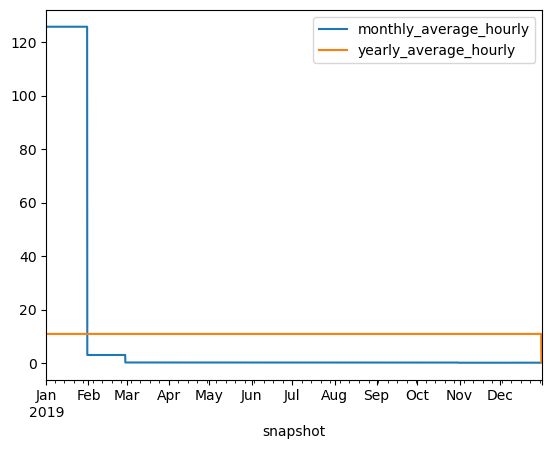

In [ ]:
n = networks[2020]
electricity_supply, electricity_demand = supply_demand(n, interconnectors=True, merge_dist_grid=True, drop_dist_grid=False)

period = slice("2019-01-01", "2019-12-31")
# (demand-vre_gen)[period].plot(figsize=(30,5), label="demand-vre_gen")
# daily_average_hourly[period].plot(label="daily_average_hourly")
# weekly_average_hourly[period].plot(label="weekly_average_hourly")
monthly_average_hourly[period].plot(label="monthly_average_hourly")
yearly_average_hourly[period].plot(label="yearly_average_hourly") 

plt.legend()

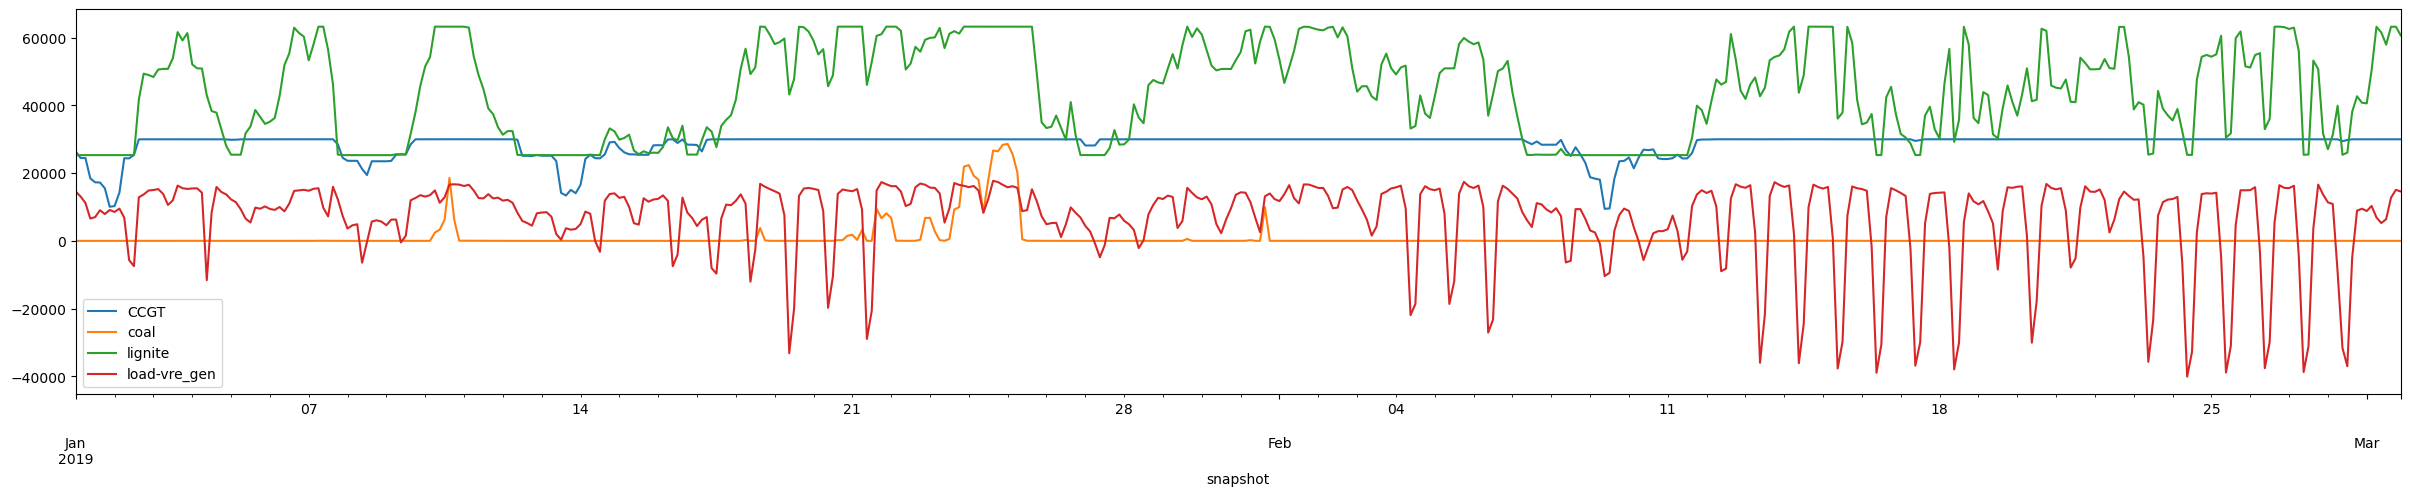

In [ ]:

period = slice("2019-01-01", "2019-03-01")
tech1 = "CCGT"
tech2 = "coal"
tech3 = "lignite"
electricity_supply.loc[tech1][period].plot(figsize=(30,5), label=tech1)
electricity_supply.loc[tech2][period].plot(label=tech2)
electricity_supply.loc[tech3][period].plot( label=tech3)
(load-vre_gen)[period].plot(label="load-vre_gen")
# (demand-vre_gen)[period].plot(label="load-vre_gen")
# (-vre_gen)[period].plot(label="vre_gen")
plt.legend()

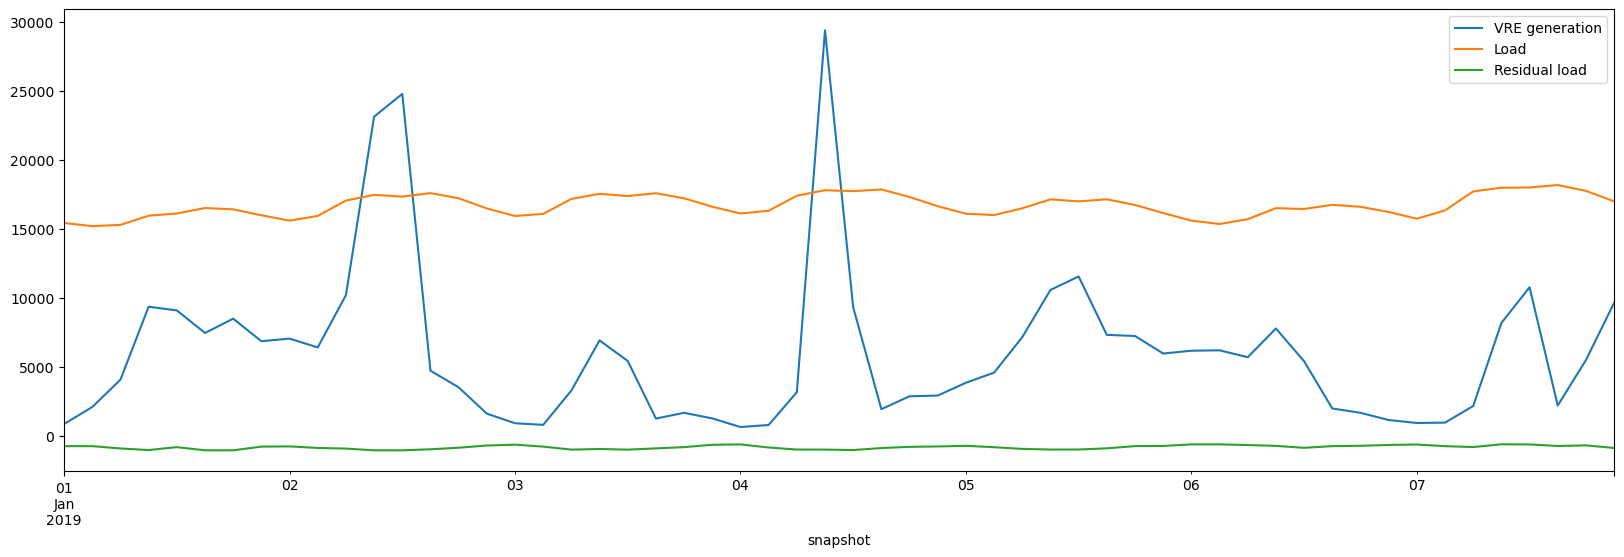

In [ ]:
# plot methodology
period = slice("2019-01-01", "2019-01-07")
vre_gen[period].plot(figsize=(20,6), label="VRE generation")
load[period].plot(label="Load")
residual_load[period].plot(label="Residual load")
plt.legend()

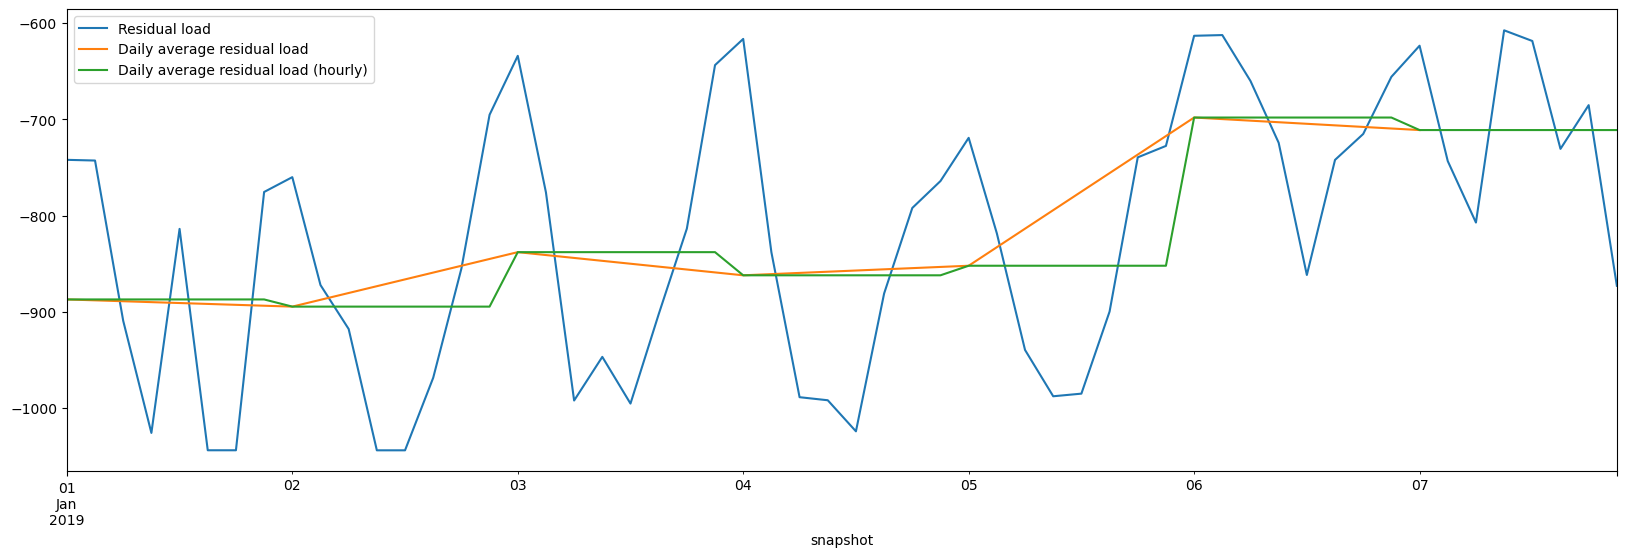

In [ ]:
# plot methodology
period = slice("2019-01-01", "2019-01-07")
residual_load[period].plot(figsize=(20,6), label="Residual load")
daily_average_residual[period].plot(label="Daily average residual load")
daily_average_hourly[period].plot(label="Daily average residual load (hourly)")
plt.legend()

0.27747608250001987
snapshot
2019-05-01 00:00:00    0.000000
2019-05-01 03:00:00    0.000000
2019-05-01 06:00:00    0.155602
2019-05-01 09:00:00    0.000000
2019-05-01 12:00:00    0.000000
2019-05-01 15:00:00    0.106539
2019-05-01 18:00:00    0.000000
2019-05-01 21:00:00    0.015335
dtype: float64


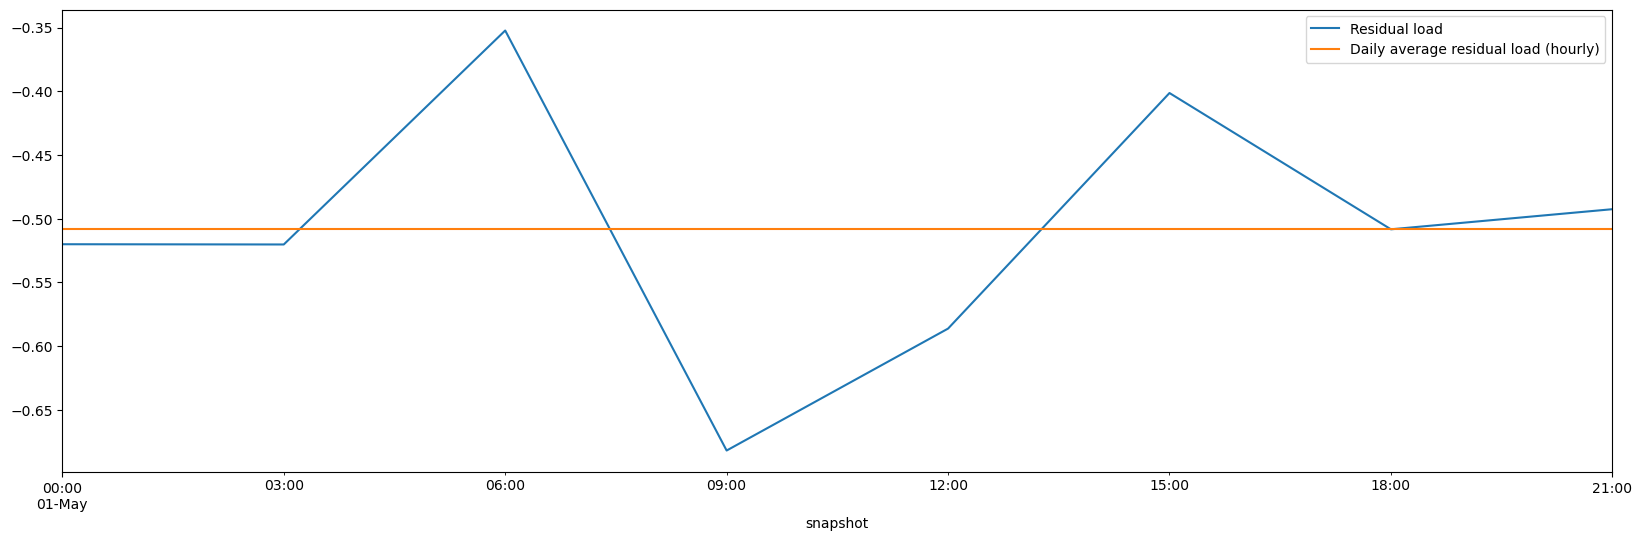

In [ ]:
day = "2019-05-01"
(residual_load[day]/1e3).plot(figsize=(20,6), label="Residual load")
(daily_average_hourly[day]/1e3).plot(label="Daily average residual load (hourly)")
plt.legend()

print(daily_flexibility_needs[day] / 1e3)
print(hourly_flexibility_needs[day]/1e3) # MWh

## Calc carrier contribution

In [ ]:
def calculate_technology_flexibility_contribution(n, 
                                                    bus_carrier=["AC", "low voltage"], 
                                                    load_carriers=["electricity", "agriculture electricity", "industry electricity"],
                                                    vre_gens=["onwind", "offwind-ac", "offwind-dc", "solar", "solar-hsat","solar rooftop", "ror"],
                                                    region="DE",
                                                    no_dist_grid=True,
                                                    ):

    kwargs = {
        "groupby": n.statistics.groupers.get_name_bus_and_carrier,
        "nice_names": False,
    }
    buses_de = n.buses[(n.buses.index.str[:2] == region) & (n.buses.carrier.isin(bus_carrier))].index

    electricity_supply = (
        n.statistics.supply(
            bus_carrier=bus_carrier, 
            aggregate_time=False, 
            **kwargs
            )
    ).multiply(n.snapshot_weightings.generators) 
    electricity_supply = electricity_supply[electricity_supply.index.get_level_values("bus").isin(buses_de)].groupby("carrier").sum()
    # electricity_supply = electricity_supply.drop(["AC", "DC", "electricity distribution grid"], errors="ignore")

    electricity_demand = (
        n.statistics.withdrawal(
            bus_carrier=bus_carrier, 
            aggregate_time=False, 
            **kwargs
            )
    ).multiply(n.snapshot_weightings.generators) 
    electricity_demand = electricity_demand[electricity_demand.index.get_level_values("bus").isin(buses_de)].groupby("carrier").sum()
    # electricity_demand = electricity_demand.drop(["AC", "DC", "electricity distribution grid"], errors="ignore")

    # assert (electricity_supply.values.sum() - electricity_demand.values.sum()) < 1e3, "Supply and demand must be equal"
    
    # 1. Calculate initial residual load
    vre_gen = electricity_supply.loc[vre_gens].sum()
    load = electricity_demand.loc[load_carriers].sum()
    demand = electricity_demand.sum()
    residual_load = load - vre_gen

    # 2. Compute daily average of residual load
    daily_average_residual = residual_load.resample('D').mean()

    # Expand daily averages to hourly resolution for comparison
    daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

    # 3. Compute the difference between residual load and daily average (only the positive part)
    hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

    # Calculate daily flexibility needs 
    daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

    # 4. Calculate total annual flexibility needs
    total_annual_flexibility = hourly_flexibility_needs.sum()
    
    # 5. Get supply technologies (excluding VRE)
    no_vre_supply = electricity_supply[~electricity_supply.index.isin(vre_gens)]

    assert (no_vre_supply.values.sum() + vre_gen.values.sum() - electricity_supply.values.sum()) < 1e3, "Supply must be met by VRE and non VRE"
    
    # 6. Calculate individual technology contributions
    tech_contributions = {}

    for tech in no_vre_supply.index:

        # Create a copy of residual load
        residual_load_tech = residual_load.copy()
        
        # Subtract the specific technology's generation
        residual_load_tech -= no_vre_supply.loc[tech]
        
        # Recompute flexibility needs without this technology
        daily_average_residual_tech = residual_load_tech.resample('D').mean()
        daily_average_hourly_tech = daily_average_residual_tech.reindex(residual_load_tech.index, method='ffill')
        
        # Compute hourly and daily flexibility needs
        hourly_flexibility_needs_tech = (residual_load_tech - daily_average_hourly_tech).clip(lower=0) # daily_average_hourly or with_tech
        daily_flexibility_needs_tech = hourly_flexibility_needs_tech.resample('D').sum()
        
        # Calculate the contribution of this technology
        tech_contribution = total_annual_flexibility - daily_flexibility_needs_tech.sum()
        tech_contributions[tech] = tech_contribution / 1e6  # Convert to TWh
    
    # Create a DataFrame of contributions
    residual_daily_flexibility_needs = pd.DataFrame.from_dict(tech_contributions, orient='index', columns=['flexibility'])
    
    return {
        'total_annual_flexibility': total_annual_flexibility / 1e6,  # Convert to TWh
        'technology_contributions': residual_daily_flexibility_needs
    }

In [ ]:
# Usage
year = 2045
n = networks[year]
result = calculate_technology_flexibility_contribution(n, region="DE")

# Print total and individual contributions
print("Total Annual Flexibility Needs:", result['total_annual_flexibility'], "TWh")
print("\nTechnology Contributions:")
print((result['technology_contributions']).round(2))

# Verify additivity
print("\nSum of Technology Contributions:", result['technology_contributions']['flexibility'].sum())
# print((result['technology_contributions'][result['technology_contributions'].flexibility > 0.1]).round(2).drop(["AC", "DC", "electricity distribution grid"]).sum())
print(result['technology_contributions'].round(2).sum())

Total Annual Flexibility Needs: 240.22596043621874 TWh

Technology Contributions:
                                    flexibility
AC                                       -62.14
BEV charger                                0.00
CCGT                                       0.59
DAC                                        0.00
DC                                         1.04
H2 Electrolysis                            0.00
H2 Fuel Cell                               0.00
H2 OCGT                                    0.67
H2 pipeline                                0.00
H2 pipeline (Kernnetz)                     0.00
H2 retrofit OCGT                           0.01
OCGT                                       0.00
PHS                                        1.98
agriculture electricity                    0.00
battery charger                            0.00
battery discharger                        40.41
electricity                                0.00
electricity distribution grid            -32.69
home b

In [ ]:
res = pd.DataFrame(index=np.arange(2020,2050,5), columns=['total_annual_flexibility'])
tech_contribution = {}
for year in np.arange(2020,2050,5):
    n = networks[year]
    result = calculate_technology_flexibility_contribution(n)
    res.loc[year, 'total_annual_flexibility'] = result['total_annual_flexibility']
    tech_contribution[year] = result['technology_contributions']

In [ ]:
res

,total_annual_flexibility
2020,25.649767
2025,54.929844
2030,127.448538
2035,179.639216
2040,232.671355
2045,240.22596


In [ ]:
all_years = summarize_small_values(tech_contribution[2020], 'flexibility')
for year in np.arange(2025,2050,5):
    df = summarize_small_values(tech_contribution[year], 'flexibility')
    all_years = pd.concat([all_years, df], axis=1)


In [ ]:
all_years

,flexibility,flexibility,flexibility,flexibility,flexibility,flexibility
AC,3.503955,NaN,NaN,NaN,NaN,NaN
CCGT,0.899903,8.058357e+00,5.554845,1.095224e+00,6.188378e-01,5.907471e-01
DC,1.151688,-1.924894e-01,6.042635,2.808481e+00,7.736256e-01,1.040117e+00
biogas,2.651195,7.199757e-01,NaN,3.101201e-02,NaN,NaN
lignite,5.767384,1.352202e+01,NaN,1.185802e-01,NaN,NaN
nuclear,2.464407,NaN,NaN,NaN,NaN,NaN
urban central coal CHP,0.269345,3.767853e-01,NaN,5.430316e-02,4.218895e-03,NaN
Other,-8.279691,-4.454293e+01,-16.236210,-5.927942e+01,-9.159919e+01,-9.482853e+01
BEV charger,NaN,-7.450581e-15,NaN,0.000000e+00,-2.980232e-14,0.000000e+00
DAC,NaN,-7.450581e-15,NaN,0.000000e+00,-2.980232e-14,0.000000e+00


/tmp/ipykernel_19792/1715484069.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()  # Adjust layout to avoid clipping


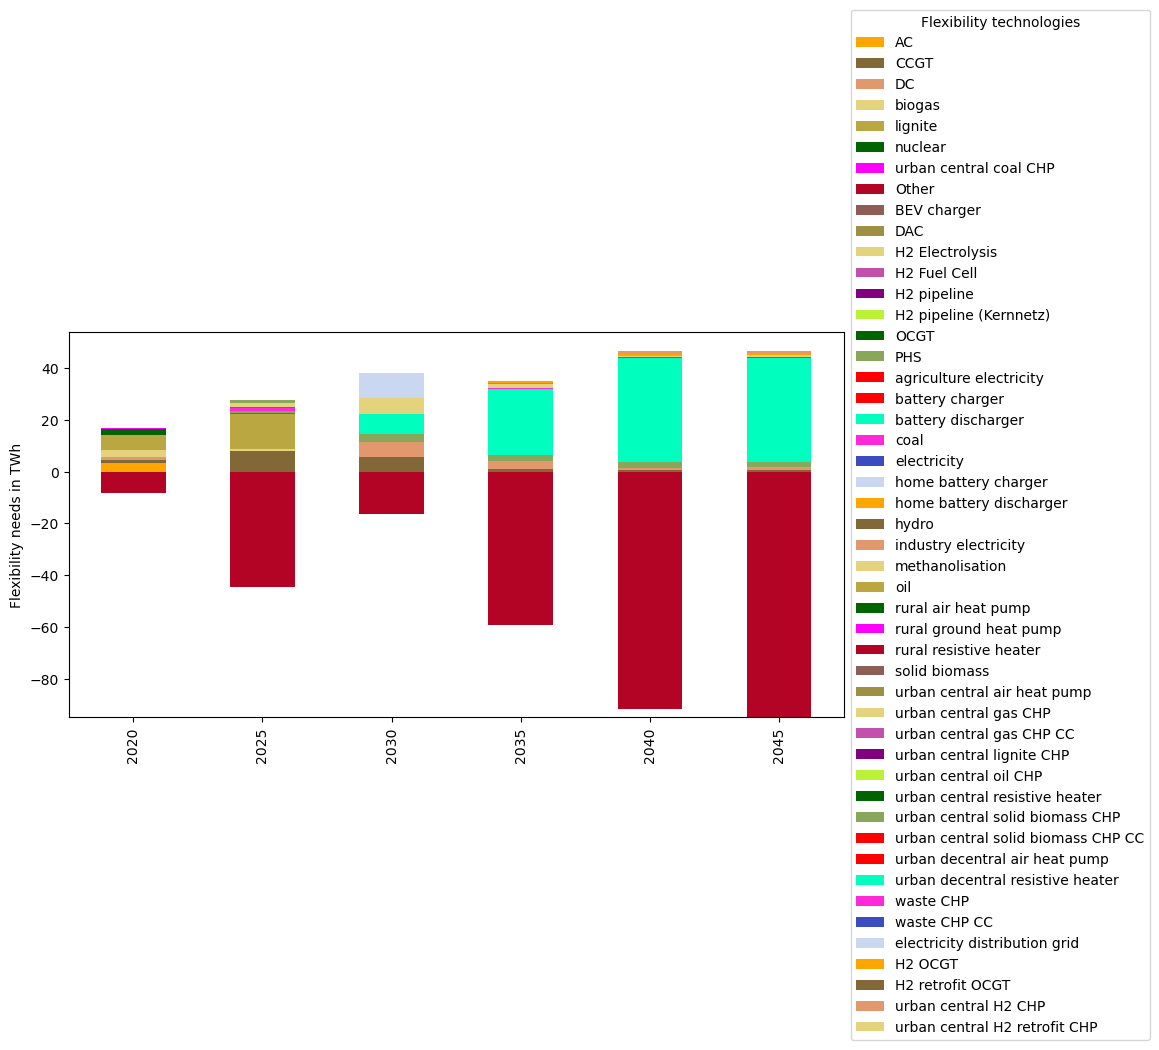

In [ ]:
all_years.columns = np.arange(2020,2050,5)
ax = all_years.T.plot(kind='bar', stacked=True, figsize=(10, 5), color=colors)

# Position the legend to the right of the plot
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title="Flexibility technologies")  # Adjust as needed
ax.set_ylabel('Flexibility needs in TWh')  # Replace with your desired y-axis label

plt.tight_layout()  # Adjust layout to avoid clipping
plt.show()

In [ ]:
# calc flexibility contribution of tech
flexSign = (residual_load - daily_average_hourly).apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))

In [ ]:
# tech
prod_tech = no_vre_supply.loc[tech]
daily_avg_prod_tech = prod_tech.resample('D').mean()
daily_avg_prod_tech = daily_avg_prod_tech.reindex(prod_tech.index, method='ffill')

con = 0.5 * flexSign * (prod_tech - daily_avg_prod_tech)

NameError: name 'no_vre_supply' is not defined

In [ ]:
def calculate_technology_flexibility_contribution_new(n, 
                                                    bus_carrier=["AC", "low voltage"], 
                                                    load_carriers=["electricity", "agriculture electricity", "industry electricity"],
                                                    vre_gens=["onwind", "offwind-ac", "offwind-dc", "solar", "solar-hsat","solar rooftop", "ror"],
                                                    ):
    kwargs = {
        "groupby": n.statistics.groupers.get_name_bus_and_carrier,
        "nice_names": False,
    }
    buses_de = n.buses[(n.buses.index.str[:2] == region) & (n.buses.carrier.isin(bus_carrier))].index

    electricity_supply = (
        n.statistics.supply(
            bus_carrier=bus_carrier, 
            aggregate_time=False, 
            **kwargs
            )
    ).multiply(n.snapshot_weightings.generators) 
    electricity_supply = electricity_supply[electricity_supply.index.get_level_values("bus").isin(buses_de)].groupby("carrier").sum()
    electricity_supply = electricity_supply.drop(["AC", "DC", "electricity distribution grid"], errors="ignore")

    electricity_demand = (
        n.statistics.withdrawal(
            bus_carrier=bus_carrier, 
            aggregate_time=False, 
            **kwargs
            )
    ).multiply(n.snapshot_weightings.generators) 
    electricity_demand = electricity_demand[electricity_demand.index.get_level_values("bus").isin(buses_de)].groupby("carrier").sum()
    electricity_demand = electricity_demand.drop(["AC", "DC", "electricity distribution grid"], errors="ignore")
    
    # 1. Calculate initial residual load
    vre_gen = electricity_supply.loc[vre_gens].sum()
    load = electricity_demand.loc[load_carriers].sum()
    residual_load = load - vre_gen

    # 2. Compute daily average of residual load
    daily_average_residual = residual_load.resample('D').mean()

    # Expand daily averages to hourly resolution for comparison
    daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

    # 3. Compute the difference between residual load and daily average (only the positive part)
    hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

    # Calculate daily flexibility needs 
    daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

    # 4. Calculate total annual flexibility needs
    total_annual_flexibility = hourly_flexibility_needs.sum()
    
    # 5. Get supply technologies (excluding VRE)
    no_vre_supply = electricity_supply[~electricity_supply.index.isin(vre_gens)]

    assert (no_vre_supply.values.sum() + vre_gen.values.sum() - electricity_supply.values.sum()) < 1e3, "Supply must be met by VRE and non VRE"
    
    # 6. Calculate individual technology contributions
    flexSign = (residual_load - daily_average_hourly).apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))

    tech_contributions = {}
    for tech in no_vre_supply.index:
        # tech
        prod_tech = no_vre_supply.loc[tech]
        daily_avg_prod_tech = prod_tech.resample('D').mean()
        daily_avg_prod_tech = daily_avg_prod_tech.reindex(prod_tech.index, method='ffill')

        tech_contribution = 0.5 * flexSign * (prod_tech - daily_avg_prod_tech)
        tech_contributions[tech] = tech_contribution.sum().sum() / 1e6  # Convert to TWh
    
    # Create a DataFrame of contributions
    residual_daily_flexibility_needs = pd.DataFrame.from_dict(tech_contributions, orient='index', columns=['flexibility'])
    
    return {
        'total_annual_flexibility': total_annual_flexibility / 1e6,  # Convert to TWh
        'technology_contributions': residual_daily_flexibility_needs
    }

In [ ]:
# Usage
year = 2045
n = networks[year]
result = calculate_technology_flexibility_contribution_new(n)

# Print total and individual contributions
print("Total Annual Flexibility Needs:", result['total_annual_flexibility'], "TWh")
print("\nTechnology Contributions:")
print((result['technology_contributions']).round(2))

# Verify additivity
print("\nSum of Technology Contributions:", result['technology_contributions']['flexibility'].sum())
# print((result['technology_contributions'][result['technology_contributions'].flexibility > 0.1]).round(2).drop(["AC", "DC", "electricity distribution grid"]).sum())
print((result['technology_contributions'][result['technology_contributions'].flexibility > 0.1]).round(2).sum())

Total Annual Flexibility Needs: 178.515889578735 TWh

Technology Contributions:
                                    flexibility
BEV charger                                0.00
CCGT                                       0.49
DAC                                        0.00
H2 Electrolysis                            0.00
H2 Fuel Cell                               0.00
H2 OCGT                                    0.59
H2 pipeline                                0.00
H2 pipeline (Kernnetz)                     0.00
H2 retrofit OCGT                           0.08
OCGT                                       0.00
PHS                                        2.36
agriculture electricity                    0.00
battery charger                            0.00
battery discharger                        10.83
electricity                                0.00
home battery charger                       0.00
home battery discharger                    0.00
hydro                                      0.20
industry

In [ ]:
n = networks[2045]
bus_carrier=["AC", "low voltage"]
load_carriers=["electricity", "agriculture electricity", "industry electricity"]
vre_gens=["onwind", "offwind-ac", "offwind-dc", "solar", "solar-hsat","solar rooftop", "ror"]
region="DE"


kwargs = {
    "groupby": n.statistics.groupers.get_name_bus_and_carrier,
    "nice_names": False,
}
buses_de = n.buses[(n.buses.index.str[:2] == region) & (n.buses.carrier.isin(bus_carrier))].index

electricity_supply = (
    n.statistics.supply(
        bus_carrier=bus_carrier, 
        aggregate_time=False, 
        **kwargs
        )
).multiply(n.snapshot_weightings.generators) 
electricity_supply = electricity_supply[electricity_supply.index.get_level_values("bus").isin(buses_de)].groupby("carrier").sum()
electricity_supply = electricity_supply.drop(["AC", "DC", "electricity distribution grid"], errors="ignore")

electricity_demand = (
    n.statistics.withdrawal(
        bus_carrier=bus_carrier, 
        aggregate_time=False, 
        **kwargs
        )
).multiply(n.snapshot_weightings.generators) 
electricity_demand = electricity_demand[electricity_demand.index.get_level_values("bus").isin(buses_de)].groupby("carrier").sum()
electricity_demand = electricity_demand.drop(["AC", "DC", "electricity distribution grid"], errors="ignore")

# assert (electricity_supply.values.sum() - electricity_demand.values.sum()) < 1e3, "Supply and demand must be equal"

# 1. Calculate initial residual load
vre_gen = electricity_supply.loc[vre_gens].sum()
load = electricity_demand.loc[load_carriers].sum()
demand = electricity_demand.sum()
residual_load = load - electricity_supply.sum()

# 2. Compute daily average of residual load
daily_average_residual = residual_load.resample('D').mean()

# Expand daily averages to hourly resolution for comparison
daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

# 3. Compute the difference between residual load and daily average (only the positive part)
hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

# Calculate daily flexibility needs 
daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

# 4. Calculate total annual flexibility needs
total_annual_flexibility = hourly_flexibility_needs.sum()

round(hourly_flexibility_needs.sum() / 1e6, 2)

162.49

In [ ]:
# 1. Calculate initial residual load
vre_gen = electricity_supply.loc[vre_gens].sum()
load = electricity_demand.loc[load_carriers].sum()
demand = electricity_demand.sum()
residual_load = demand - vre_gen - electricity_supply.loc["battery discharger"]

snapshot
2019-01-01 00:00:00    473913.15300
2019-01-01 03:00:00    522512.07300
2019-01-01 06:00:00    550557.56238
2019-01-01 09:00:00    601658.99187
2019-01-01 12:00:00    585127.27311
                           ...     
2019-12-31 09:00:00    534450.94422
2019-12-31 12:00:00    373486.26087
2019-12-31 15:00:00    183465.21177
2019-12-31 18:00:00    124443.88056
2019-12-31 21:00:00     90062.13411
Length: 2920, dtype: float64

In [ ]:
# 5. Get supply technologies (excluding VRE)
no_vre_supply = electricity_supply[~electricity_supply.index.isin(vre_gens)]

assert (no_vre_supply.values.sum() + vre_gen.values.sum() - electricity_supply.values.sum()) < 1e3, "Supply must be met by VRE and non VRE"

# 6. Calculate individual technology contributions
tech_contributions = {}

for tech in ["nuclear"]:
    
    # Subtract the specific technology's generation
    residual_load_tech = residual_load - no_vre_supply.loc[tech]
    
    # Recompute flexibility needs without this technology
    daily_average_residual_tech = residual_load_tech.resample('D').mean()
    daily_average_hourly_tech = daily_average_residual_tech.reindex(residual_load_tech.index, method='ffill')
    
    # Compute hourly and daily flexibility needs
    hourly_flexibility_needs_tech = (residual_load_tech - daily_average_hourly_tech).clip(lower=0) # daily_average_hourly or with_tech
    daily_flexibility_needs_tech = hourly_flexibility_needs_tech.resample('D').sum()
    
    # Calculate the contribution of this technology
    tech_contribution = total_annual_flexibility - daily_flexibility_needs_tech.sum()
    tech_contributions[tech] = tech_contribution / 1e6  # Convert to TWh

# Create a DataFrame of contributions
residual_daily_flexibility_needs = pd.DataFrame.from_dict(tech_contributions, orient='index', columns=['flexibility'])

In [ ]:
residual_daily_flexibility_needs.sort_values(by='flexibility', ascending=False).head(10)

,flexibility
lignite,24.735827
nuclear,22.942380
CCGT,21.066204
urban central coal CHP,14.845743
urban central gas CHP,13.450765
biogas,13.219224
urban central solid biomass CHP,7.656242
urban central lignite CHP,4.818613
coal,1.122553
hydro,1.069889


In [ ]:
tech

'waste CHP CC'

In [ ]:
total_annual_flexibility / 1e6

27.95304292269

In [ ]:
daily_flexibility_needs_tech.sum() / 1e6

27.95258791311

In [ ]:
# 1. Calculate initial residual load
vre_gen = electricity_supply.loc[vre_gens].sum()
load = electricity_demand.loc[load_carriers].sum()
demand = electricity_demand.sum()
residual_load = load - vre_gen

# 2. Compute daily average of residual load
daily_average_residual = residual_load.resample('D').mean()

# Expand daily averages to hourly resolution for comparison
daily_average_hourly = daily_average_residual.reindex(residual_load.index, method='ffill')

# 3. Compute the difference between residual load and daily average (only the positive part)
hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

# Calculate daily flexibility needs 
daily_flexibility_needs = hourly_flexibility_needs.resample('D').sum()

# 4. Calculate total annual flexibility needs
total_annual_flexibility = hourly_flexibility_needs.sum()

# 5. Get supply technologies (excluding VRE)
no_vre_supply = electricity_supply[~electricity_supply.index.isin(vre_gens)]

round(total_annual_flexibility / 1e6, 2)

27.95

## Flexibilität

In [ ]:
network = networks[2045]
ct = "DE"
buses = network.buses.index[(network.buses.index.str[:2] == ct)].drop("DE")
balance = (
    network.statistics.energy_balance(
        aggregate_time=False,
        nice_names=False,
        groupby=network.statistics.groupers.get_bus_and_carrier_and_bus_carrier,
    )
    .loc[:, buses, :, :]
    .droplevel("bus")
)

In [ ]:
period = slice("2019-01-18", "2019-01-25")
carriers = ["AC", "low voltage"]
mask = balance.index.get_level_values("bus_carrier").isin(carriers)
nb = balance[mask].groupby("carrier").sum().div(1e3).T.loc[period]

In [ ]:
# nb.sum().sort_values(ascending=False).head(20)

In [ ]:
# nb.sum().sort_values(ascending=False).tail(20)

In [ ]:
period = slice("2019-01-11", "2019-01-18")
carriers = ["AC", "low voltage"]
mask = balance.index.get_level_values("bus_carrier").isin(carriers)
nb = balance[mask].groupby("carrier").sum().div(1e3).T.loc[period]

In [ ]:
# nb.sum().sort_values(ascending=False).tail(20)

In [ ]:
# installed capacities

In [ ]:
# Electricity supply
# electricity generation DE 2020: 488 TWh
# if aggregate_time=False the results are in MW (you need to multiply with snapshot.weightings)

region = "DE"
n = networks[2020]

kwargs = {
    "groupby": n.statistics.groupers.get_name_bus_and_carrier,
    "nice_names": False,
}

electricity_cap = (
    n.statistics.supply(bus_carrier=["low voltage", "AC"], **kwargs)
    .filter(like=region)
    .groupby(["carrier"])
    .sum()
    )



In [ ]:
n = networks[2045]
s,d = supply_demand(n, interconnectors=True, merge_dist_grid=False, drop_dist_grid=False)

3491.2664606224203
3491.26645773264


<Axes: xlabel='snapshot'>

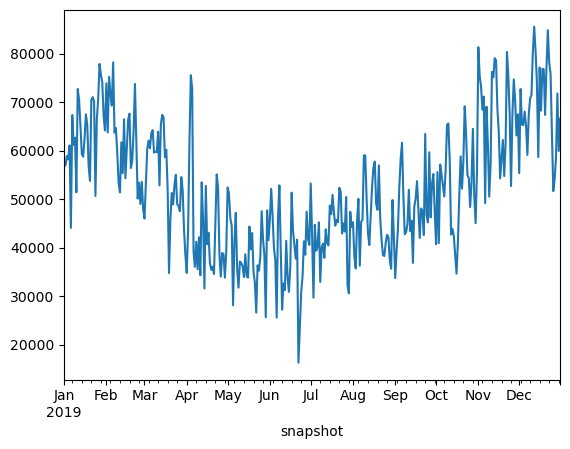

In [ ]:
s.loc["DC"].resample("D").mean().plot()

In [ ]:
# electricity import + exports
ct = "DE"
incoming_line = n.lines.index[
    (n.lines.carrier == "AC")
    & (n.lines.bus0.str[:2] != ct)
    & (n.lines.bus1.str[:2] == ct)
]
outgoing_line = n.lines.index[
    (n.lines.carrier == "AC")
    & (n.lines.bus0.str[:2] == ct)
    & (n.lines.bus1.str[:2] != ct)
]

incoming_link = n.links.index[
    (n.links.carrier == "DC")
    & (n.links.bus0.str[:2] != ct)
    & (n.links.bus1.str[:2] == ct)
]
outgoing_link = n.links.index[
    (n.links.carrier == "DC")
    & (n.links.bus0.str[:2] == ct)
    & (n.links.bus1.str[:2] != ct)
]

<Axes: xlabel='snapshot'>

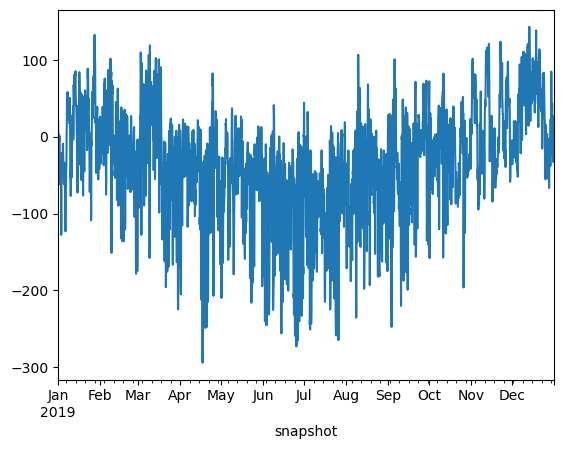

In [ ]:
df = (-(n.lines_t.p0[outgoing_line].sum(axis=1) + n.links_t.p0[outgoing_link].sum(axis=1)) - (n.lines_t.p0[incoming_line].sum(axis=1) + n.links_t.p0[incoming_link].sum(axis=1))) * 3 / 1e3
df.plot()

In [ ]:
df * 3 / 1e6

snapshot
2019-01-01 00:00:00    0.026604
2019-01-01 03:00:00    0.009657
2019-01-01 06:00:00   -0.001705
2019-01-01 09:00:00   -0.062348
2019-01-01 12:00:00   -0.047609
                         ...   
2019-12-31 09:00:00   -0.032647
2019-12-31 12:00:00   -0.023748
2019-12-31 15:00:00   -0.024148
2019-12-31 18:00:00   -0.001095
2019-12-31 21:00:00    0.026578
Length: 2920, dtype: float64